# Cinética enzimática, paso a paso, con simulaciones QM/MM

**Enzima de estudio: la glucoquinasa humana** (hexoquinasa IV, EC 2.7.1.2)

$$\text{glucosa} + \text{ATP} \;\xrightarrow{\;\text{glucoquinasa}\;}\; \text{glucosa‑6‑fosfato} + \text{ADP}$$

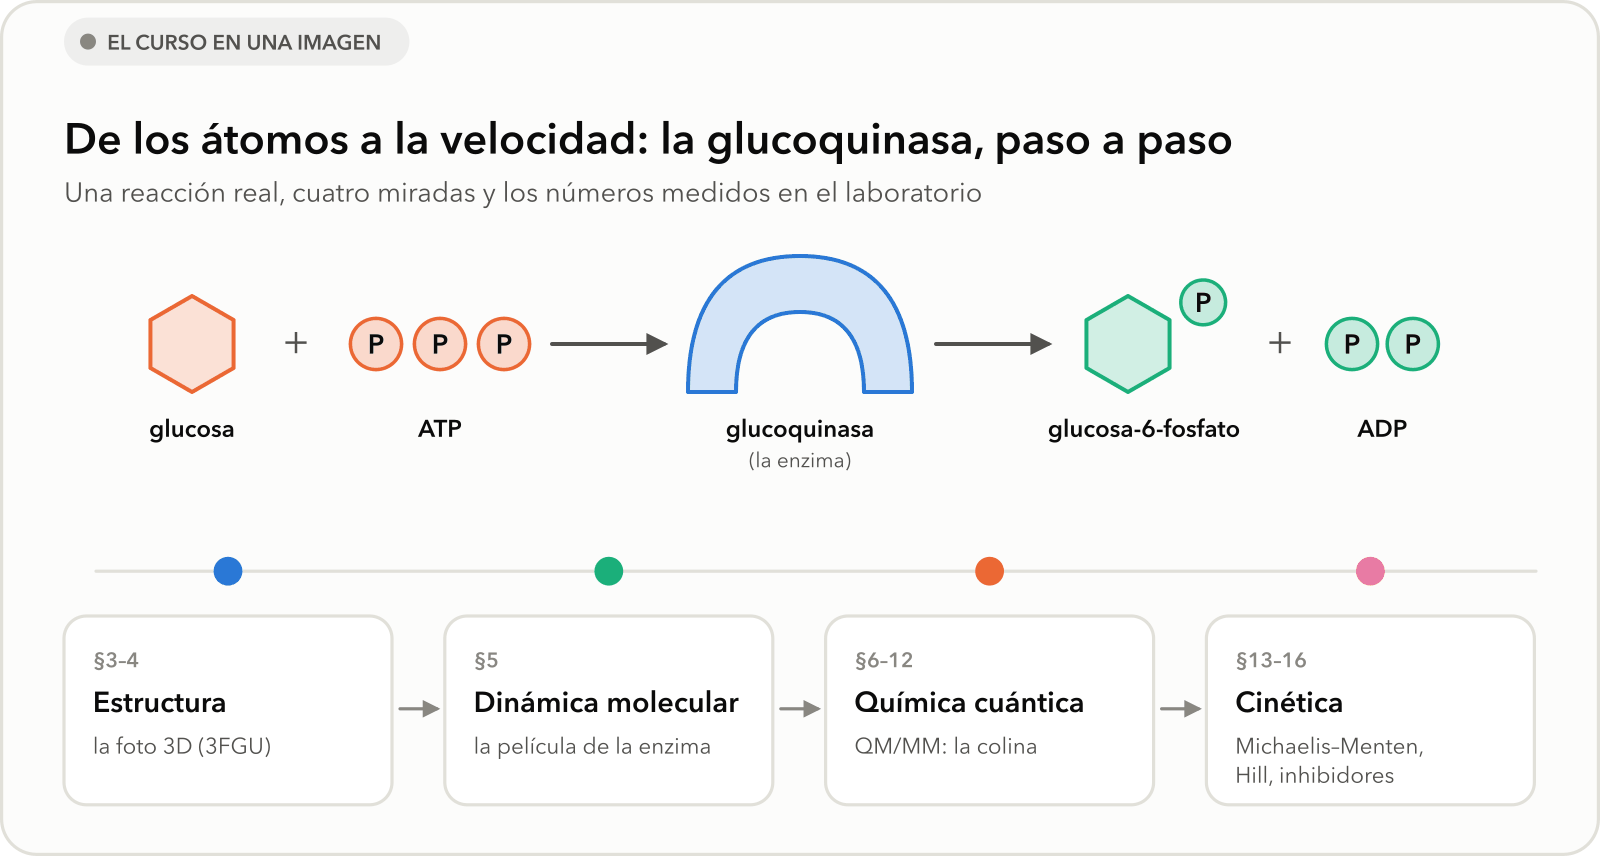

Este cuaderno explica la cinética enzimática **desde cero**, para estudiantes de pregrado. No
necesitas saber programar: basta con ejecutar las celdas en orden (▶ o `Shift + Enter`) y leer.
Usamos una enzima real y todo lo que se puede usar con ella: una estructura cristalina,
simulaciones de dinámica molecular y de mecánica cuántica (QM/MM), y los números medidos en el
laboratorio para esta enzima, con sus fuentes.

---

### 🧭 Cómo está organizada cada sección

Todas las secciones siguen el mismo orden, marcado siempre con los mismos símbolos:

| Símbolo | Bloque | Qué encontrarás |
|:---:|---|---|
| 🎯 | **En esta sección** | la pregunta que vamos a responder |
| 💡 | **La analogía** | una imagen de la vida diaria, con un dibujo |
| 🧮 | **La ecuación en palabras** | por qué necesitamos una ecuación y qué dice, sin símbolos |
| 📐 | **La ecuación completa** | la versión formal, término a término, con los mismos colores del dibujo |
| 🎛️ | **Qué pasa si…** | gráficas con deslizadores: mueve un término y mira qué cambia |
| 🔬 | **Los datos reales** | simulaciones y valores medidos en el laboratorio |
| ✅ | **Para llevar** | la idea clave en dos líneas |

Además, los recuadros **⚠️ Ojo** avisan de una trampa frecuente y los **✍️ Para pensar** te dejan una pregunta.

---

### 🗺️ Índice

| # | Sección | Qué aprendes | Herramienta |
|---|---|---|---|
| | **🧱 Bloque 1 · Las bases** | | |
| 1 | ¿Qué es una enzima y por qué la glucoquinasa? | vocabulario básico, datos experimentales | lectura |
| 2 | ¿Qué es la velocidad de una reacción? | v₀, unidades, cómo se mide | simulación |
| | **🔭 Bloque 2 · Ver la enzima** | | |
| 3 | La estructura 3D del complejo catalítico | sitio activo | PDB 3FGU, visor 3D |
| 4 | Preparar la enzima para simularla | de la foto al modelo | PDBFixer, Amber |
| 5 | La enzima se mueve: dinámica molecular | conformaciones reactivas | OpenMM |
| | **⚛️ Bloque 3 · La química, con mecánica cuántica** | | |
| 6 | Colinas de energía y velocidad | ecuación de Eyring | 🎛️ interactivo |
| 7 | Mirar la reacción con mecánica cuántica: QM/MM | regiones QM y MM | MOPAC PM7 + Amber |
| 8 | Reactivo, producto y perfil de energía | coordenada de reacción | escaneo |
| 9 | El estado de transición | NEB, dímero, frecuencia imaginaria | ASE |
| 10 | De ΔE‡ a ΔG‡: mejoras del cálculo | termoquímica, promedios, método | ASE, MOPAC |
| 11 | La reacción fuera de la enzima | SADDLE (QST2), TS, FORCETS | MOPAC nativo |
| 12 | De la barrera a *k*<sub>cat</sub> | comparación con el experimento | Eyring |
| | **📈 Bloque 4 · La cinética del laboratorio** | | |
| 13 | Michaelis–Menten desde el mecanismo | K<sub>M</sub>, V<sub>max</sub>, k<sub>cat</sub>, k<sub>cat</sub>/K<sub>M</sub> | ODE, ajustes, 🎛️ |
| 14 | Cooperatividad: la glucoquinasa es un sensor | ecuación de Hill, mutantes | 🎛️ |
| 15 | Inhibidores y activadores | tipos, K<sub>i</sub>, Dixon, IC₅₀ | 🎛️ |
| 16 | Temperatura y pH | Arrhenius, Eyring, pKa | 🎛️ |
| | **🏁 Cierre** | | |
| 17 | Resumen, glosario y ejercicios | mapa del curso | |

> 💡 **Consejo.** En Colab, abre el panel **Índice** (icono ☰ a la izquierda) para saltar entre
> secciones.

---

### ⚙️ Antes de empezar

**Dos modos de ejecución.** En modo `rapido` (por defecto) el cuaderno lee resultados ya
calculados y dibuja todo en unos minutos. En modo `completo` reejecuta las simulaciones
(horas en la CPU de Colab). Cambia `MODO` en la celda siguiente si quieres recalcular.

> 🎛️ **Cómo usar las gráficas interactivas.** Las celdas marcadas con 🎛️ muestran deslizadores.
> Muévelos y observa cómo cambia la curva; debajo aparece una frase que traduce los números.
> Si los deslizadores no aparecen (por ejemplo al ver el cuaderno en GitHub), ejecuta la celda.

In [ ]:
# @title ⚙️ Preparar el entorno (ejecuta esta celda primero)
# --- Preparación del entorno (ejecuta esta celda primero) -------------------------------
import os, sys, subprocess, pathlib

MODO = "rapido"  # @param ["rapido", "completo"]
# "rapido": usa resultados precalculados (minutos) | "completo": recalcula todo (horas)

REPO = "https://github.com/juvenalyosa/cinetica-enzimatica.git"
if "google.colab" in sys.modules:
    # En Colab: descargar el curso o, si ya estaba de una sesión anterior, ponerlo al día con la última versión
    destino = pathlib.Path("/content/cinetica-enzimatica")
    if destino.exists():
        subprocess.run(["git", "-C", str(destino), "fetch", "-q", "origin"], check=True)
        subprocess.run(["git", "-C", str(destino), "reset", "-q", "--hard", "origin/main"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
    os.chdir(destino)
elif not pathlib.Path("enzimas").exists() and pathlib.Path("../enzimas").exists():
    os.chdir("..")                                     # ejecutado desde notebooks/ en Jupyter
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
# si la celda se vuelve a ejecutar, olvidar la versión del paquete cargada antes
for nombre in [m for m in sys.modules if m == "enzimas" or m.startswith("enzimas.")]:
    del sys.modules[nombre]

from enzimas import colab_setup
entorno = colab_setup.instalar(MODO, idioma="es")

In [ ]:
# @title 📦 Cargar las herramientas del curso
# --- Importaciones y estilo gráfico -----------------------------------------------------
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from enzimas import kinetics as cin, viz, datos, interactivo, visor3d, textos
textos.usar("es")                           # idioma de gráficas, tarjetas y visores
viz.apply_style()

def leer(nombre):
    """Lee un archivo de texto de data/precalculado (descomprime .gz si hace falta)."""
    return pathlib.Path(datos.ruta(nombre)).read_text()

ref = cin.glucokinase_reference()          # valores experimentales de la literatura, con sus fuentes
def valor(clave, defecto=None):
    v = ref.get(clave, {})
    return v.get("value", defecto) if isinstance(v, dict) else (v if v is not None else defecto)

print("Listo. Modo:", MODO)

## 1. ¿Qué es una enzima y por qué la glucoquinasa?

> 🎯 **En esta sección** aprenderás qué hace una enzima (y qué **no** hace), el vocabulario que
> usaremos todo el curso, qué reacción cataliza la glucoquinasa y por qué es tan importante para
> tu cuerpo.

---

### 💡 La analogía: un guía que conoce el paso más bajo

Imagina que quieres cruzar una cordillera. Sin guía, buscarías el paso a ciegas y tardarías
semanas. Un buen guía conoce el **paso más bajo** y te lleva por él en horas. La montaña sigue
ahí, pero el camino es otro. Una **enzima** es ese guía: no cambia el punto de partida ni el de
llegada de una reacción química, pero la lleva por un camino mucho más fácil, y por eso ocurre
miles o millones de veces más rápido.

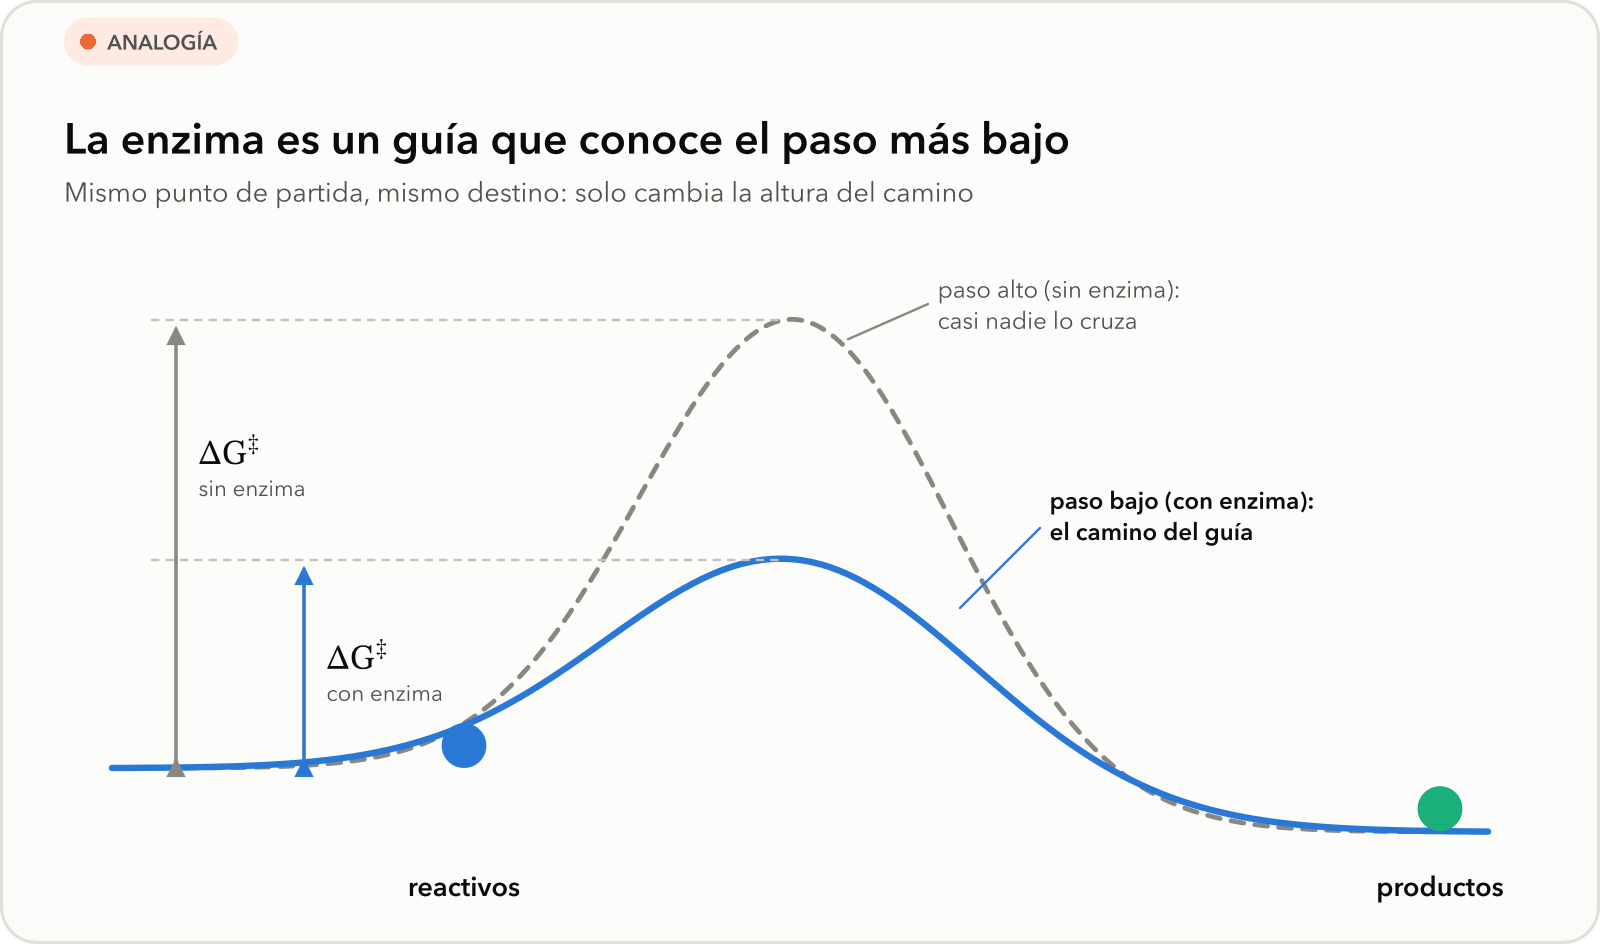

Fíjate en lo que el dibujo **no** cambia: los dos valles están a la misma altura con y sin
enzima. Una enzima acelera la reacción, pero no decide hacia dónde va ni cuánto producto habrá
al final.

---

### 📖 Vocabulario que usaremos todo el tiempo

| Término | Qué es | En la analogía | En la glucoquinasa |
|---|---|---|---|
| **Sustrato (S)** | la molécula que la enzima transforma | el viajero en el valle de partida | glucosa y ATP |
| **Producto (P)** | lo que sale | el viajero ya en el valle de llegada | glucosa‑6‑fosfato y ADP |
| **Sitio activo** | el hueco de la enzima donde encajan los sustratos y ocurre la química | el punto de encuentro con el guía | el bolsillo con Asp205, Lys169 y Mg²⁺ |
| **Complejo ES** | la enzima con el sustrato ya dentro | viajero y guía, juntos | glucoquinasa·glucosa·ATP |
| **Estado de transición (TS)** | el momento más difícil de la reacción | la cima del paso | el fosfato a medio camino |

Casi todo este cuaderno gira en torno al **estado de transición**.

---

### 🔬 Nuestra enzima: la glucoquinasa

La **glucoquinasa** toma una glucosa y le pega un grupo fosfato que viene del ATP. El
producto, glucosa‑6‑fosfato, ya no puede salir de la célula: es el primer paso para "atrapar" y
usar la glucosa.

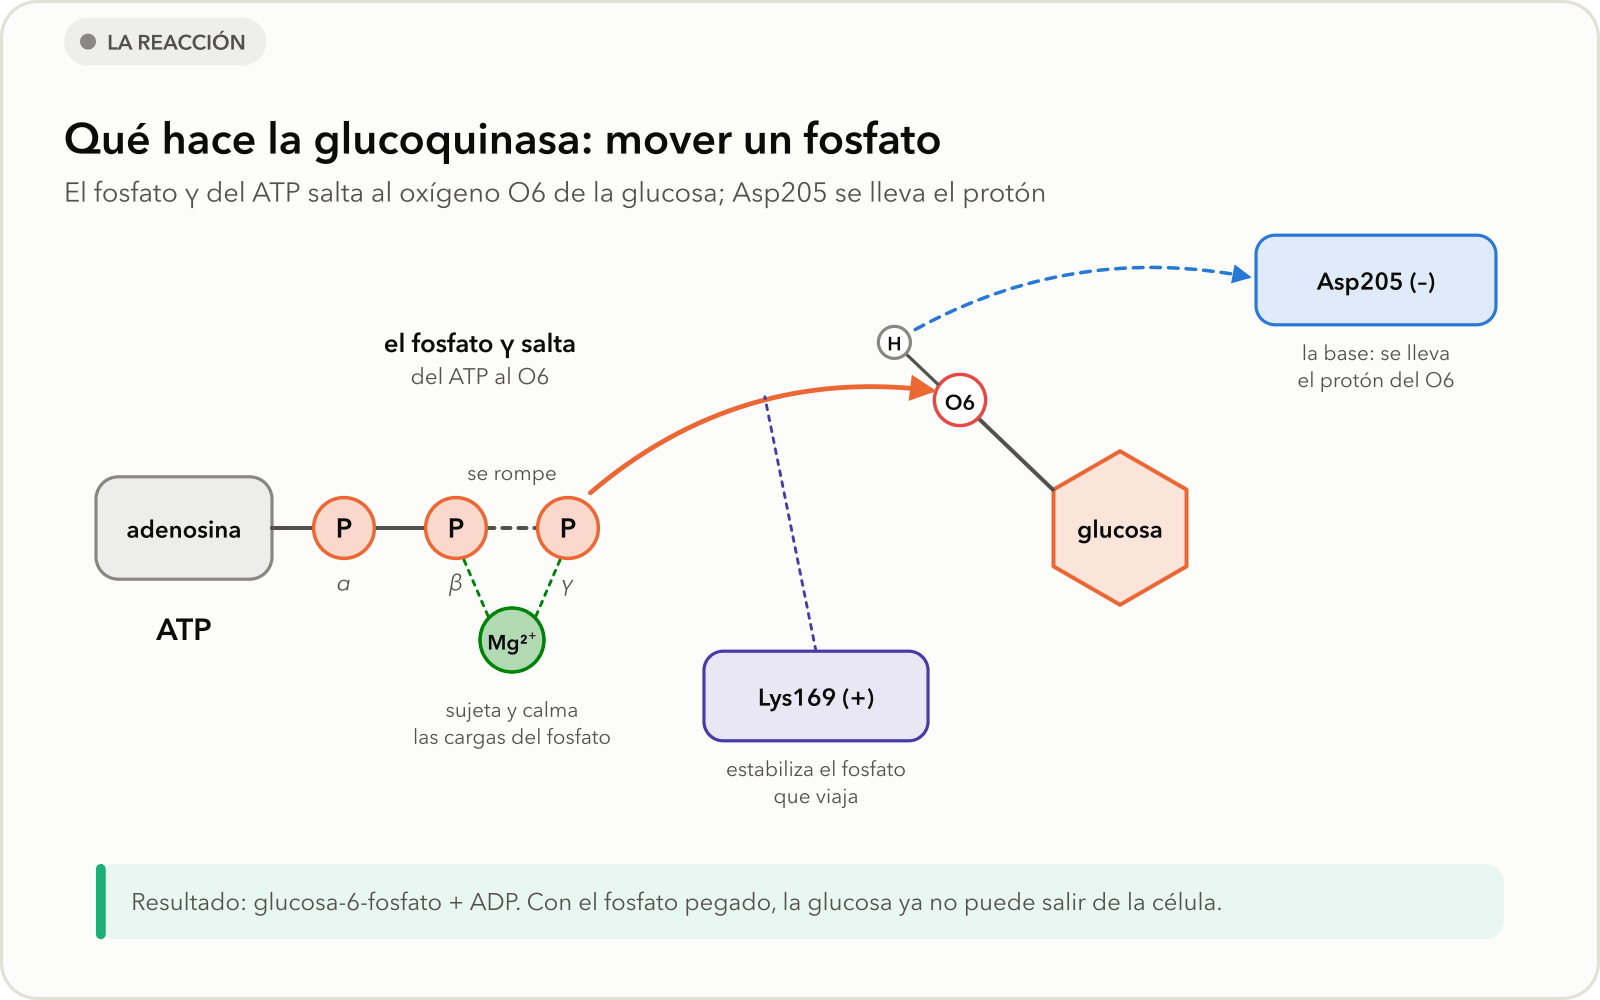

La glucoquinasa vive en el hígado y en las células β del páncreas, donde funciona como **sensor
de glucosa**: su actividad decide cuánta insulina se libera.

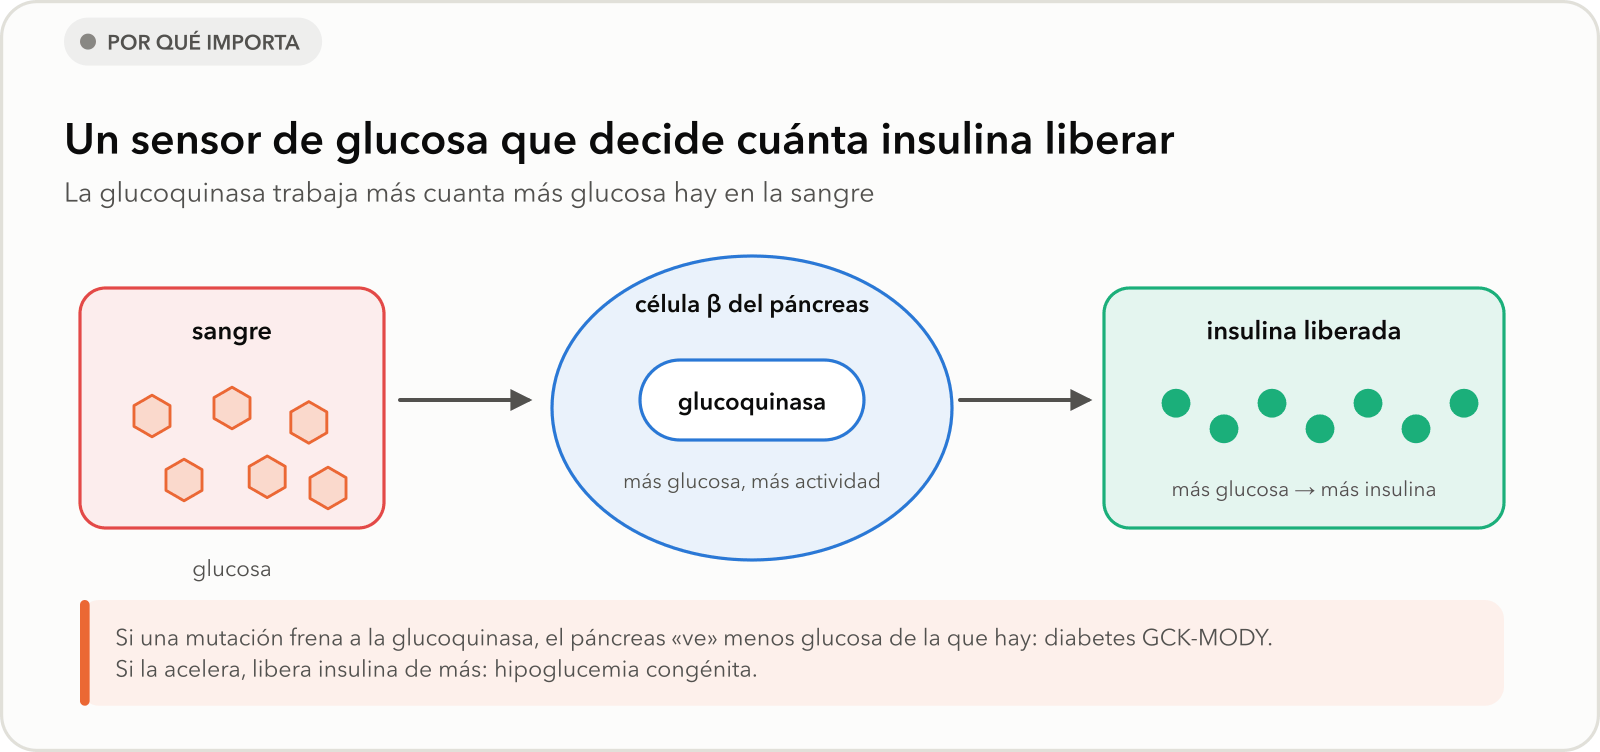

Mutaciones en su gen causan una diabetes hereditaria (GCK‑MODY, antes MODY2) y, si la vuelven
hiperactiva, hipoglucemia congénita.

**Tres cosas la hacen ideal para aprender cinética:**

1. Su reacción es una **transferencia de fosforilo** clásica, con Mg²⁺ y una base catalítica (Asp205).
2. Su curva de velocidad **no** es la hipérbola de Michaelis–Menten sino una **sigmoide** (sección 14).
3. Tiene inhibidores, una proteína reguladora y activadores farmacológicos bien estudiados (sección 15).

---

### 🔬 Los datos reales: números medidos en el laboratorio

Todo lo que sigue se compara con estos valores, tomados de artículos originales (columna
*fuente*). Guárdalos: son el "resultado experimental" que la teoría debe explicar.

> ⚠️ **Ojo.** Distintos laboratorios obtienen k<sub>cat</sub> entre 38 y 66 s⁻¹ para la misma
> enzima: en bioquímica, un número siempre viene con sus condiciones (temperatura, pH, tampón).

In [ ]:
# @title 📋 Los números de la glucoquinasa medidos en el laboratorio
filas = []
for k, v in ref.items():
    if isinstance(v, dict) and "value" in v:
        valor_txt = v["value"]
        if isinstance(valor_txt, (int, float)) and abs(valor_txt) >= 1e5:  # 1.1e12 → 1.1 × 10¹²
            m, e = f"{valor_txt:.1e}".split("e")
            valor_txt = f"{m} × 10" + str(int(e)).translate(str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻"))
        filas.append((v.get("label", k), valor_txt, v.get("unit", ""), v.get("conditions", ""), v.get("source", "")))
tabla = pd.DataFrame(filas, columns=["parámetro", "valor", "unidad", "condiciones", "fuente"])
viz.mostrar(
    viz.tabla(tabla, titulo="La glucoquinasa humana en el laboratorio",
              nota="Cada número viene con sus condiciones y su fuente: distintos laboratorios miden valores algo distintos."),
    viz.mensaje(ref.get("notes", ""), tipo="dato", titulo="Nota sobre los datos") if ref.get("notes") else None,
)

> ✅ **Para llevar.** Una enzima es un guía: baja la colina entre reactivos y productos sin
> cambiar ni el punto de partida ni el de llegada. La glucoquinasa mueve un fosfato del ATP a la
> glucosa, y como sensor de glucosa decide cuánta insulina libera el páncreas.

## 2. ¿Qué es la velocidad de una reacción?

> 🎯 **En esta sección** aprenderás qué significa "velocidad" en una reacción química, por qué los
> bioquímicos miden la **velocidad inicial v₀** y cómo se mide en el laboratorio para la
> glucoquinasa.

---

### 💡 La analogía: contar monedas que caen en un frasco

La velocidad de una reacción es **cuánto producto aparece por segundo** (o cuánto sustrato
desaparece). Es como contar las monedas que caen en un frasco: si a los 5 s hay 5 y a los 10 s
hay 10, caen a razón de una por segundo. Si en un tubo con enzima la glucosa‑6‑fosfato pasa de
0 a 10 µM en 10 s, la velocidad es 1 µM/s.

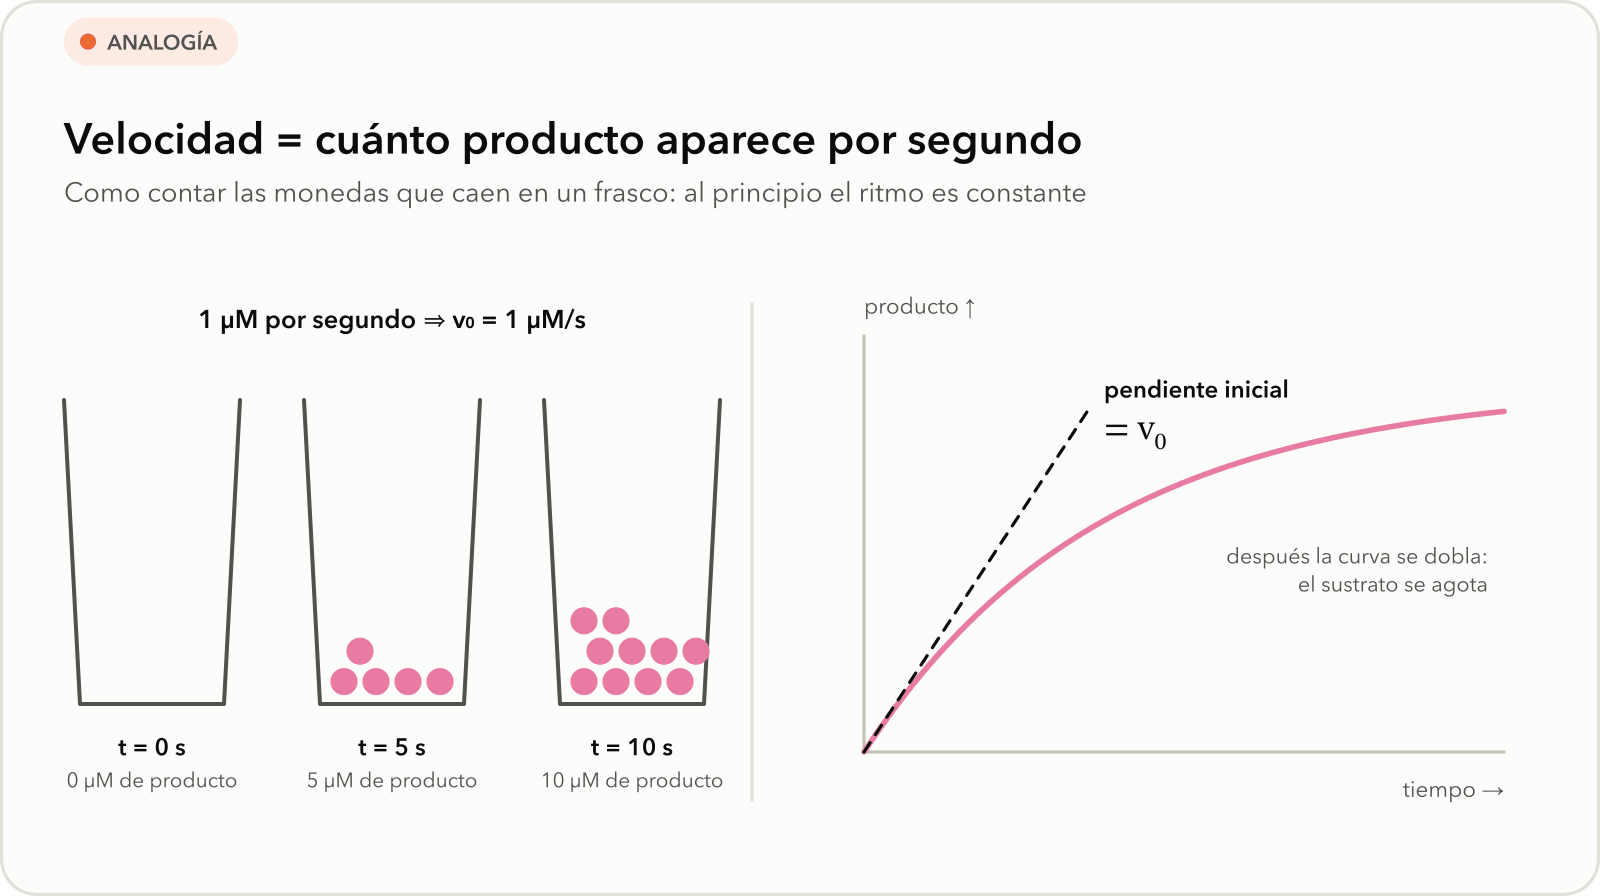

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para que "rápido" y "lento" se conviertan en un número con
unidades, que podamos comparar entre experimentos y con la teoría.

$$\text{velocidad} \;=\; \frac{\text{cuánto producto nuevo apareció}}{\text{cuánto tiempo pasó}}$$

### 📐 La ecuación completa, término a término

$$v_0 \;=\; \left(\frac{{\color{#e87ba4}{\Delta[\mathrm{P}]}}}{{\color{#52514e}{\Delta t}}}\right)_{t\,\to\,0}$$

| Término | Qué es | En la analogía | Unidades |
|---|---|---|---|
| $v_0$ | velocidad **inicial** | el ritmo de monedas al principio | µM/s |
| $\Delta[\mathrm{P}]$ | aumento de la concentración de producto | monedas nuevas en el frasco | µM |
| $\Delta t$ | tiempo transcurrido | segundos en el cronómetro | s |
| $t \to 0$ | "medido al comienzo" | contar antes de que se acaben las monedas | — |

**¿Por qué "velocidad inicial"?** Al principio del experimento el sustrato apenas se ha gastado
y el producto apenas se ha acumulado, así que la velocidad es constante y refleja solo la
enzima y la concentración de sustrato que pusimos. Después la curva se dobla (el sustrato se
agota). Por eso los bioquímicos miden la **velocidad inicial, v₀**: la pendiente de la curva
de producto al comienzo.

> ⚠️ **Ojo.** Si mides la pendiente demasiado tarde, cuando la curva ya se dobló, obtendrás una
> velocidad más baja que la real y todos los parámetros que calcules después saldrán mal.

---

### 🔬 Cómo se mide en la glucoquinasa: el ensayo acoplado

No se ve la glucosa‑6‑fosfato directamente: se acopla otra enzima (glucosa‑6‑fosfato
deshidrogenasa, G6PDH) que la convierte y, al hacerlo, produce NADPH, que absorbe luz a 340 nm.
El espectrofotómetro registra la absorbancia frente al tiempo, y la pendiente inicial es v₀ (el
ensayo "acoplado a G6PDH" de casi todos los artículos de la tabla anterior).

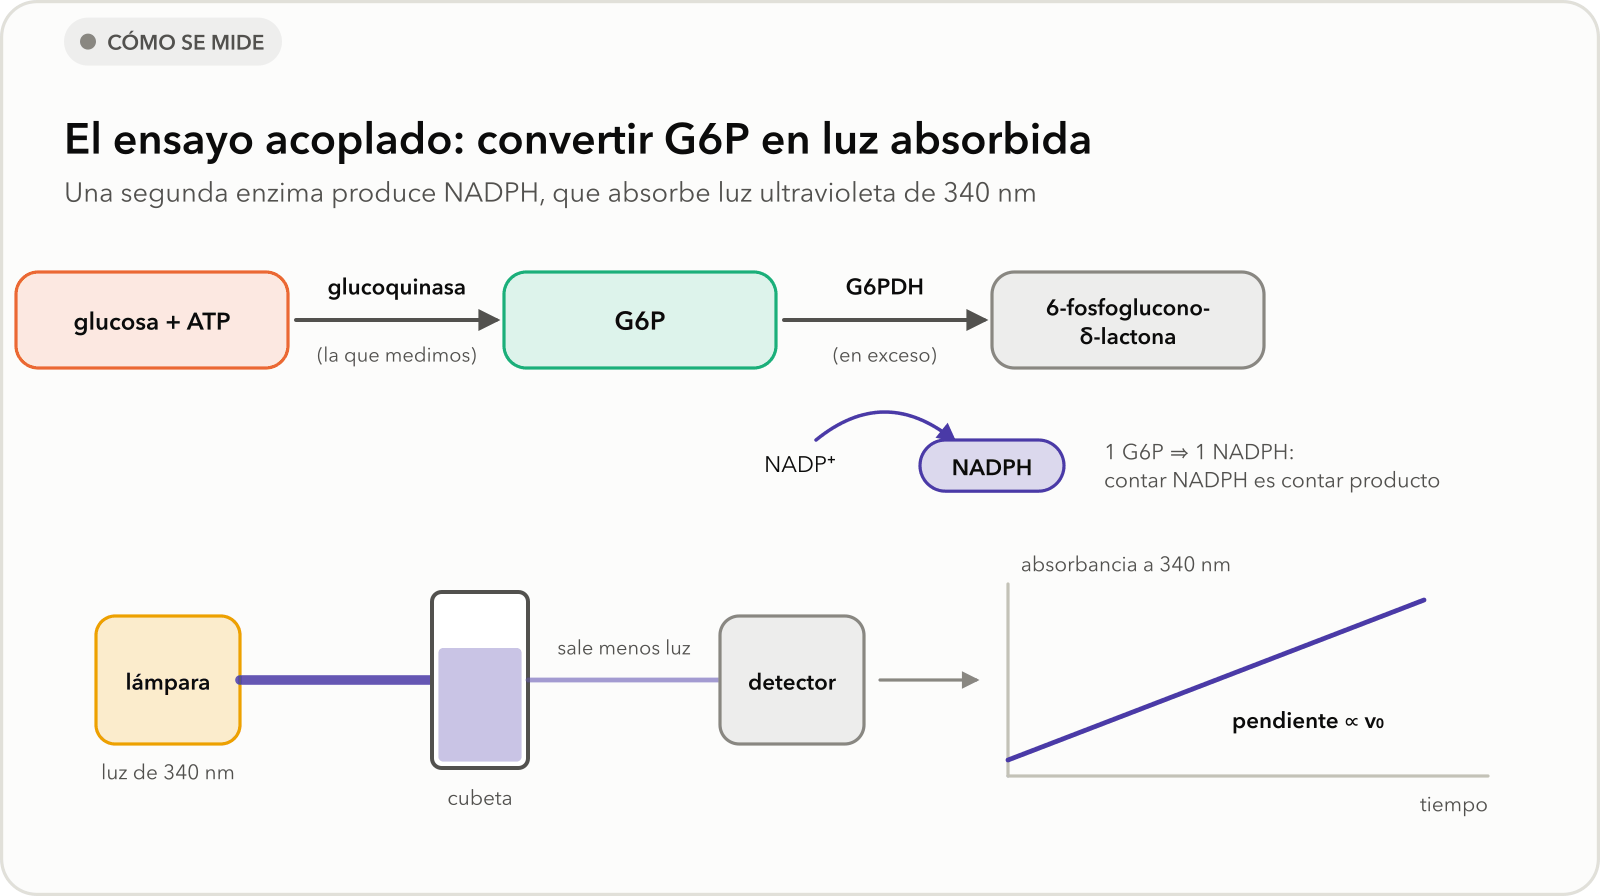

---

### 🎛️ Qué pasa si… cambio la cantidad de sustrato

Simulemos esa curva para tres concentraciones iniciales de sustrato, [S]₀, y midamos la pendiente
inicial de cada una:

In [ ]:
# @title 📈 Curvas de progreso y velocidad inicial
# Curva de progreso simulada: producto frente a tiempo para tres concentraciones de sustrato
E0, k1, k_1, k2 = 0.05, 1.0, 50.0, 60.0          # µM, µM⁻¹s⁻¹, s⁻¹, s⁻¹
curvas = []
for S0 in (50, 200, 1000):
    sim = cin.simulate_mechanism(e0=E0, s0=S0, k1=k1, k_minus1=k_1, k2=k2, t_end=150.0, n_points=4000)
    ventana = (sim["t"] > 0.02) & (sim["t"] < 1.0)
    pend = cin.linear_fit(sim["t"][ventana], sim["P"][ventana])["slope"]
    curvas.append((sim["t"], sim["P"], pend, f"[S]₀ = {S0} µM"))
fig = viz.plot_progress_curves(curvas, title="La pendiente inicial es la velocidad v₀",
                               subtitle="Con 50, 200 y 1000 µM de sustrato. Discontinuas: las tangentes al inicio. La curva se dobla cuando el sustrato se agota")
v = [c[2] for c in curvas]
t_tab = np.array([0, 0.5, 1, 2, 5, 10, 20, 40, 80, 150])              # instantes de la tabla de datos (s)
col = {c[3]: f"[P] con {c[3].split('= ')[1]}" for c in curvas}
viz.mostrar(fig, viz.tarjetas(
    [("v₀ con 50 µM", f"{v[0]:.2f}", "µM/s", None, "azul"),
     ("v₀ con 200 µM", f"{v[1]:.2f}", "µM/s", f"4 × más sustrato → × {v[1] / v[0]:.1f} en v₀", "azul"),
     ("v₀ con 1000 µM", f"{v[2]:.2f}", "µM/s", f"20 × más sustrato → × {v[2] / v[0]:.1f} en v₀", "azul")],
    nota="Con más sustrato la pendiente inicial es mayor, pero no proporcionalmente. "
         "Ese «no proporcionalmente» es toda la cinética enzimática."),
    viz.datos(pd.DataFrame({"tiempo": t_tab, **{col[c[3]]: np.interp(t_tab, c[0], c[1]) for c in curvas}}),
              "curvas de progreso",
              "Cada fila es un instante del experimento simulado; cada columna, una de las tres curvas. Al principio "
              "el producto crece a ritmo constante (la pendiente es v₀); después se frena porque se gasta el sustrato.",
              x="tiempo", y=list(col.values()),
              unidades={"tiempo": "s", **{c: "µM" for c in col.values()}},
              formatos={"tiempo": "{:g}", **{c: "{:.1f}" for c in col.values()}},
              resaltar={2: ("v₀", "azul")},
              nota=f"Fila v₀: en el primer segundo, [P] ÷ tiempo ≈ v₀ ({v[0]:.2f}, {v[1]:.2f} y {v[2]:.2f} µM/s)."))

> ✍️ **Para pensar.** Si duplicas [S]₀ de 200 a 400 µM, ¿se duplica v₀? Anota tu predicción; en
> la sección 13 veremos por qué la respuesta es "no del todo".

> ✅ **Para llevar.** La velocidad es la pendiente de la curva de producto frente al tiempo, y se
> mide **al principio** (v₀). En la glucoquinasa se mide con un ensayo acoplado: cada G6P
> formada produce un NADPH que absorbe luz a 340 nm.

## 3. La estructura 3D del complejo catalítico

> 🎯 **En esta sección** verás dónde está cada átomo de la glucoquinasa justo antes de la
> reacción, qué hace cada pieza del sitio activo y por qué los reactivos ya están "apuntándose".

---

### 💡 La analogía: una almeja que se cierra sobre la glucosa

Para simular una enzima necesitamos saber dónde está cada átomo. Eso lo dan los cristalógrafos:
la estructura **3FGU** del Protein Data Bank es una "foto" de la glucoquinasa humana con
**glucosa**, un análogo de ATP y el ion **Mg²⁺**, todos dentro del sitio activo, justo antes de la
reacción.

La glucoquinasa tiene dos partes, el **dominio grande** y el **dominio pequeño**, unidas por una
bisagra. Sin glucosa la enzima está **abierta**, como una almeja entreabierta. Cuando la glucosa
entra, el dominio pequeño se cierra sobre ella: los reactivos quedan encerrados, sin agua
alrededor y alineados para reaccionar.

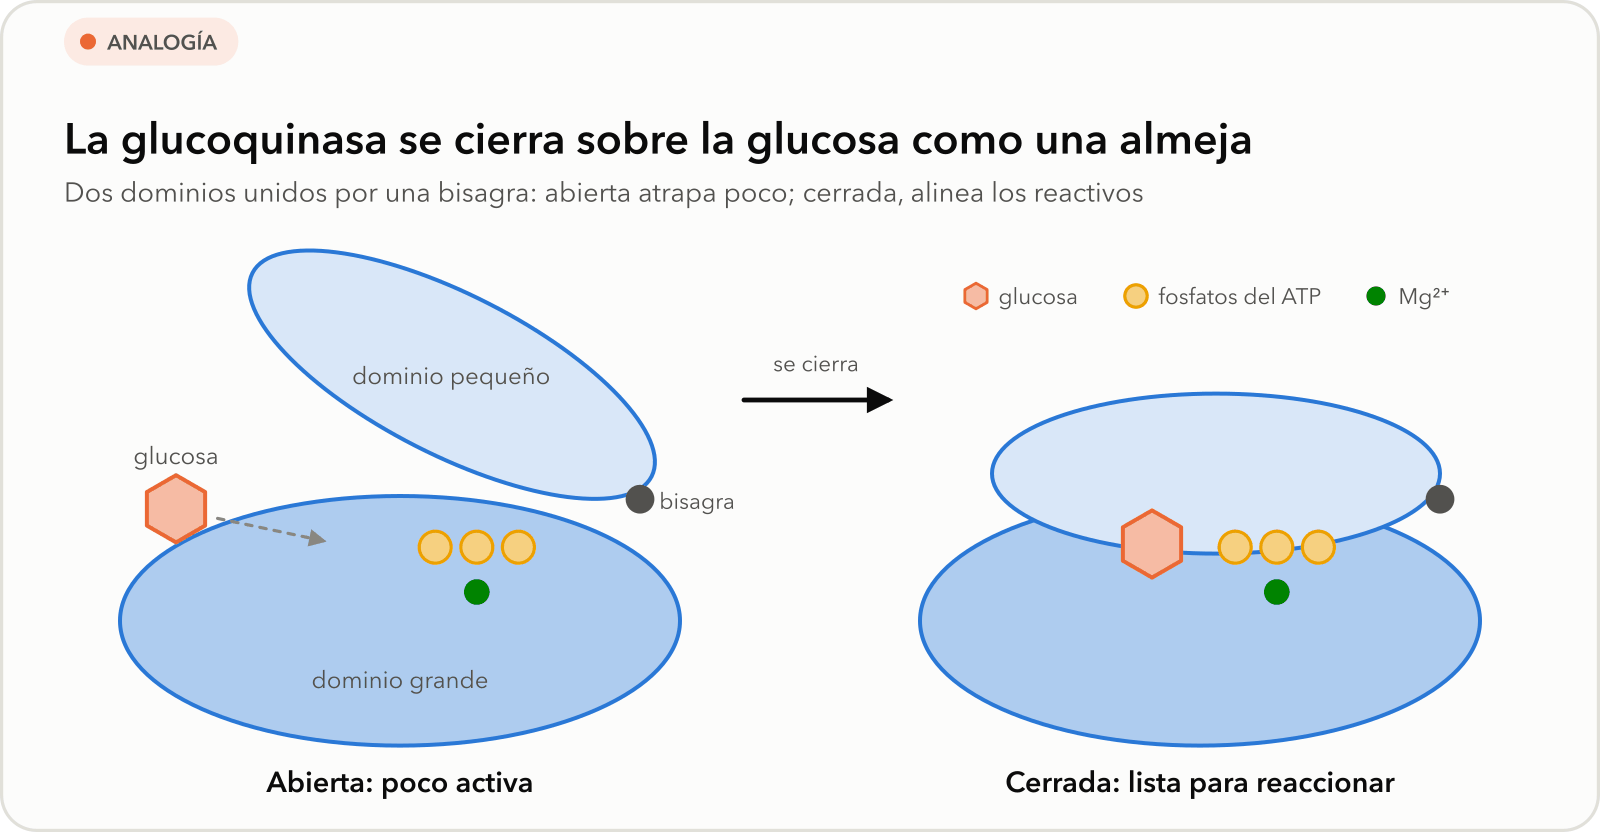

---

### 🔬 Los datos reales: quién es quién en el sitio activo

En la forma cerrada, cada pieza tiene un papel:

| Pieza | Dónde está | Qué hace | En la analogía |
|---|---|---|---|
| **O6 de la glucosa** | a ~2.7 Å del fósforo Pγ del ATP | recibirá el fosfato | la mano que atrapa la pelota |
| **Pγ del ATP** | al final del trifosfato | es el fósforo que salta | la pelota |
| **Asp205** | a 2.5 Å del hidroxilo O6–H | **base catalítica**: se llevará el protón | quien libera la mano para atrapar |
| **Lys169** y **Mg²⁺** | junto a los fosfatos | neutralizan sus cargas negativas | amortiguadores |

Un enlace P–O mide 1.6 Å: a 2.7 Å el O6 y el Pγ están **muy cerca, pero aún no unidos**.

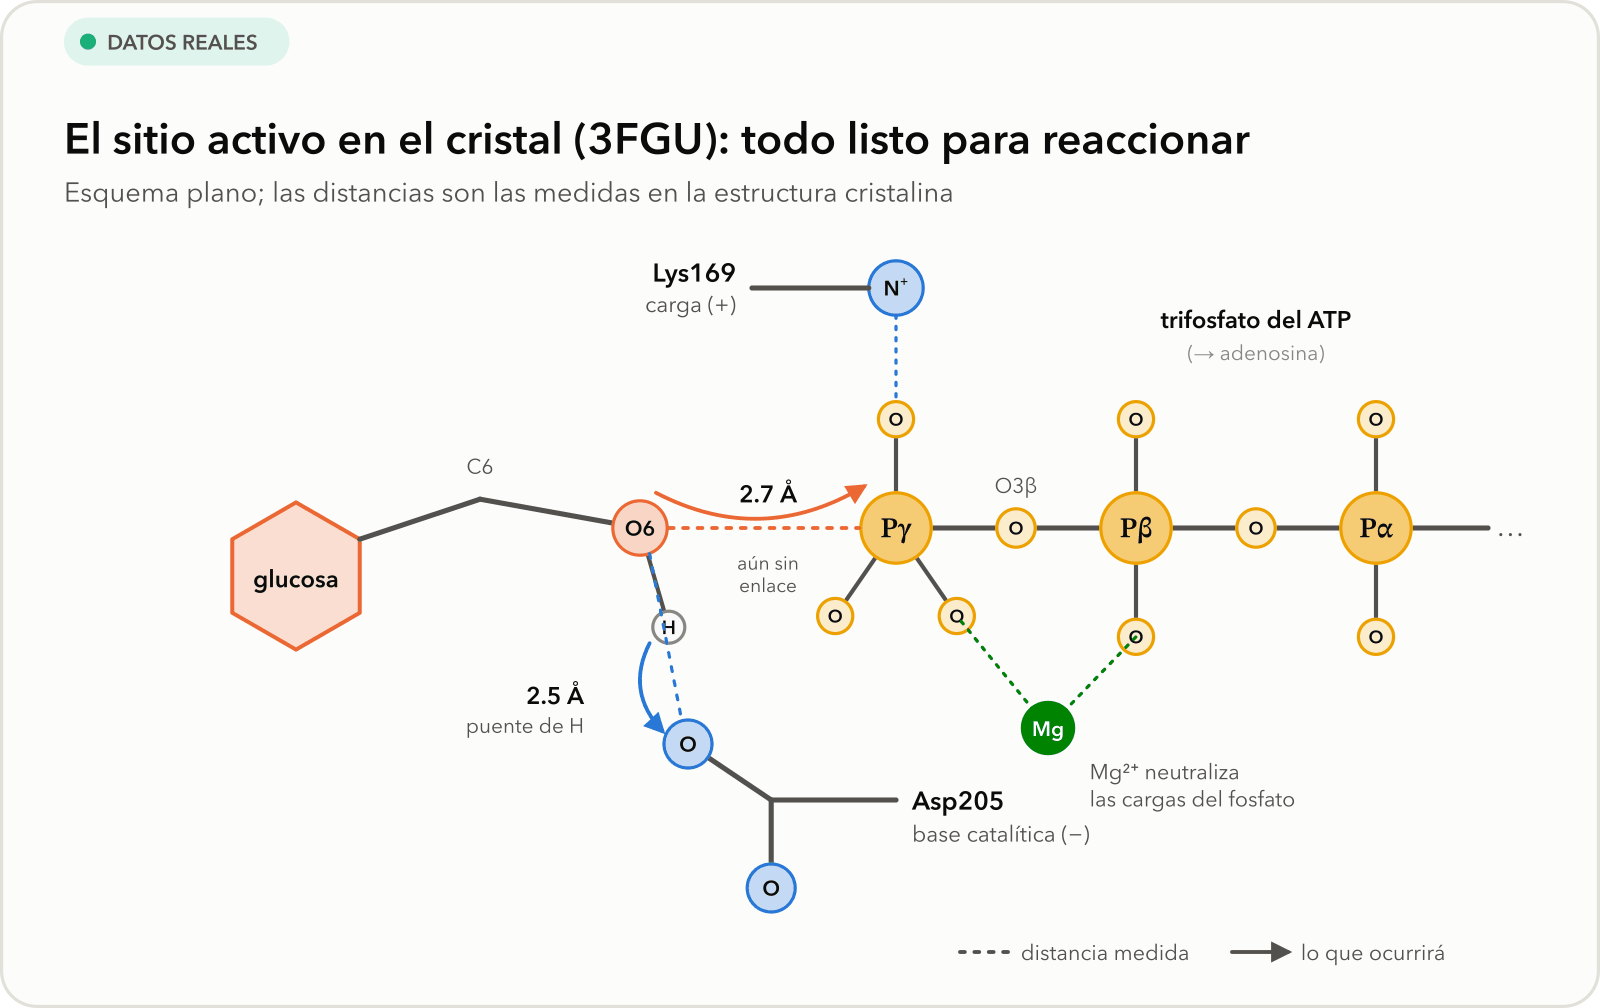

Explora la enzima real, átomo por átomo: **arrastra** para girarla, usa la **rueda** para acercarte
y los botones para ver el **sitio activo** o la **superficie**. Las **líneas discontinuas** marcan las dos
distancias que miden si todo está listo para reaccionar (Pγ ··· O6 y O6 ··· Asp205); sus valores se
calculan en la celda siguiente:

In [ ]:
# @title 🧬 La glucoquinasa en 3D (gírala con el ratón)
pdb_cristal = pathlib.Path("data/raw/3FGU.pdb").read_text()
visor3d.complejo_cristal(pdb_cristal)

Y comprobemos las dos distancias clave directamente en el archivo del cristal:

In [ ]:
# @title 📏 Distancias clave en el cristal
# Distancias clave en el cristal (Å): ¿está todo listo para reaccionar?
def coords_pdb(texto, resn, name, resi=None):
    for l in texto.splitlines():
        if l.startswith(("ATOM", "HETATM")) and l[17:20].strip() == resn and l[12:16].strip() == name and l[16] in " A":
            if resi is None or int(l[22:26]) == resi:
                return np.array([float(l[30:38]), float(l[38:46]), float(l[46:54])])

PG, O6, OD1 = coords_pdb(pdb_cristal, "ANP", "PG"), coords_pdb(pdb_cristal, "BGC", "O6"), coords_pdb(pdb_cristal, "ASP", "OD1", 205)
viz.mostrar(
    viz.tarjetas([("Pγ ··· O6 (glucosa)", f"{np.linalg.norm(PG - O6):.2f}", "Å",
                   "un enlace P–O mide 1.6 Å: están muy cerca, pero aún no unidos", "agua"),
                  ("O6 ··· OD1 (Asp205)", f"{np.linalg.norm(O6 - OD1):.2f}", "Å",
                   "enlace de hidrógeno corto: Asp205 está listo para tomar el protón", "azul")],
                 titulo="Las dos distancias clave, medidas en el archivo del cristal"),
    viz.mensaje("Son las mismas líneas discontinuas del visor 3D de arriba (verde agua y azul). Pulsa «Sitio activo» "
                "para acercarte y gira la molécula: verás que el O6 de la glucosa apunta directamente al fósforo γ del ATP.",
                "idea"))

> ✍️ **Para pensar.** El cristal usa AMP‑PNP, en el que el oxígeno entre los fósforos β y γ se
> cambió por un nitrógeno (N3B). Ese cambio impide la reacción y permite capturar el complejo.
> Para simular la reacción real, nosotros volveremos a poner el oxígeno: ATP verdadero.

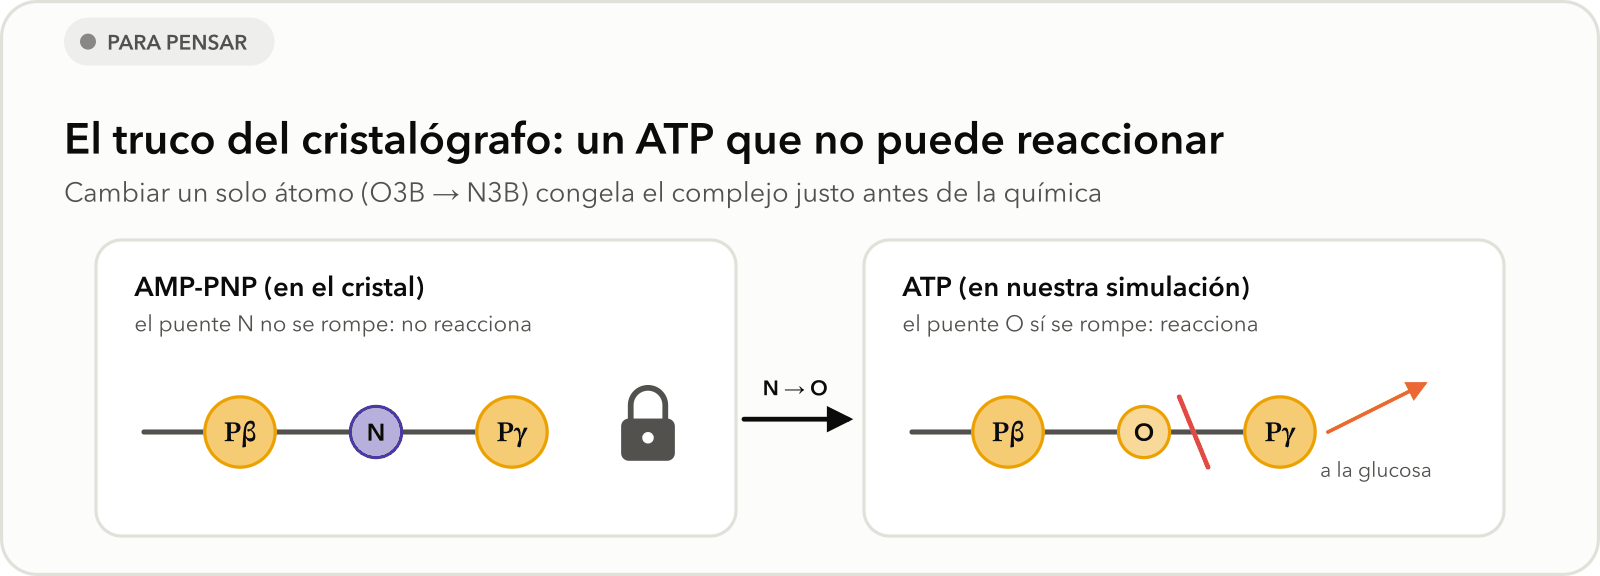

> ✅ **Para llevar.** La glucoquinasa se cierra como una almeja sobre la glucosa y deja al O6 a
> 2.7 Å del fósforo que debe atacar, con Asp205 listo para tomar su protón y Mg²⁺ y Lys169
> sujetando las cargas del fosfato. La foto ya muestra una enzima **preparada para reaccionar**.

## 4. Preparar la enzima para simularla

> 🎯 **En esta sección** verás por qué una estructura cristalina no se puede simular tal cual y
> qué cuatro arreglos la convierten en un modelo listo para la dinámica molecular.

---

### 💡 La analogía: de la foto a la maqueta

Una foto cristalográfica es como la foto de un edificio: sirve para saber cómo es, pero para
estudiar cómo se mueve con el viento hay que construir una **maqueta completa**. A la foto le
faltan cosas:

* los **hidrógenos** (los rayos X no los ven),
* **trozos de cadena** que estaban desordenados en el cristal y no se ven,
* las **reglas** de cómo se mueve cada átomo (resortes y cargas),
* y el **agua** con iones que la rodea en la célula.

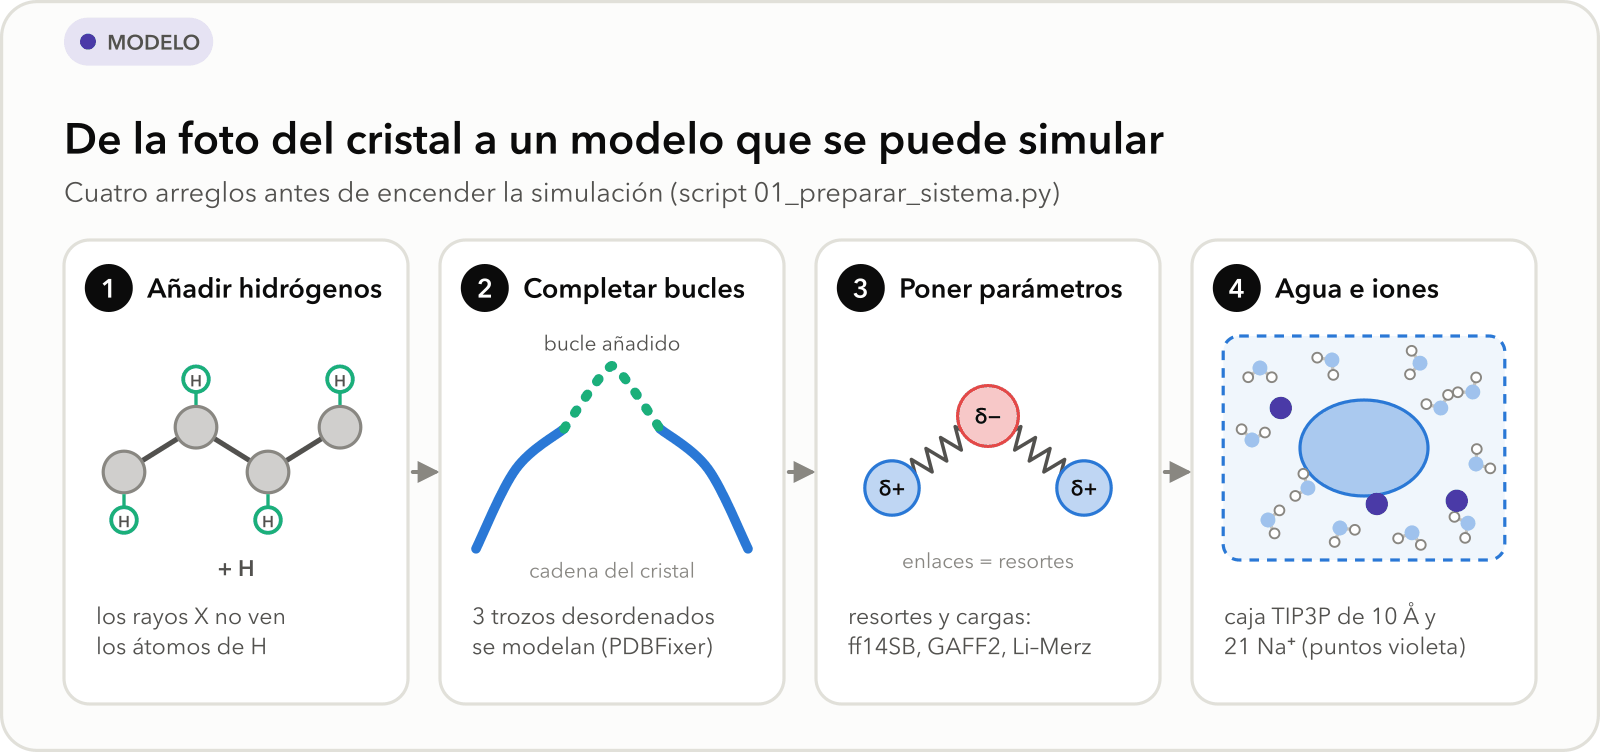

---

### 🔬 Los datos reales: qué hizo el script `scripts/01_preparar_sistema.py`

| Paso | Qué se hizo | Herramienta |
|---|---|---|
| 1. Completar la cadena | Cadena A de 3FGU, residuos 5–458; tres bucles internos faltantes modelados | PDBFixer |
| 2. Recuperar el ATP | AMP‑PNP → ATP (N3B → O3B) | edición del PDB |
| 3. Poner parámetros | glucosa y ATP con GAFF2 y cargas AM1‑BCC; proteína con Amber ff14SB; Mg²⁺ y K⁺ con parámetros de Li–Merz | antechamber, tleap |
| 4. Agua e iones | aguas cristalográficas conservadas; caja de agua TIP3P de 10 Å y 21 Na⁺ para neutralizar | tleap |

> ⚠️ **Ojo.** En modo `completo` esa preparación requiere AmberTools (antechamber, tleap), que no
> está en Colab; por eso los archivos preparados viajan con el repositorio.

Veamos el resultado:

In [ ]:
# @title 🧰 Qué tiene el sistema preparado
prep = datos.json_("sistema/preparacion.json")
solv = prep["sistema_solvatado"]
cuentas = solv["residue_counts"]
viz.mostrar(
    viz.tarjetas([
        ("átomos en la caja", f"{solv['n_atoms']:,}".replace(",", " "), "", "proteína, ligandos, iones y agua", "azul"),
        ("moléculas de agua", f"{cuentas.get('HOH', cuentas.get('WAT', 0)):,}".replace(",", " "), "", "caja TIP3P de 10 Å alrededor", "agua"),
        ("carga total", f"{solv['total_charge']:+.3f}", "e", f"neutralizada con {cuentas.get('Na+', 0)} Na⁺", "violeta"),
        ("bucles modelados", str(len(prep["bucles_modelados"])), "", "trozos que el cristal no veía", "naranja"),
    ], titulo="El sistema listo para simular",
       nota=f"Fuente: {prep['fuente']} · Campo de fuerza: {prep['campo_de_fuerza']}"),
    viz.tabla(pd.DataFrame(
        [("ligandos: cargas", ", ".join(f"{k} {v:+.2f}" for k, v in solv["ligand_charges"].items())),
         ("residuos", ", ".join(f"{k} × {v}" for k, v in cuentas.items() if k in ("HOH", "WAT", "Na+", "GLC", "ATP", "MG", "K+"))),
         ("bucles (índice, residuos)", "; ".join(str(b) for b in prep["bucles_modelados"]))],
        columns=["qué", "detalle"]), titulo="En detalle"),
)

> ✅ **Para llevar.** Una estructura cristalina es el punto de partida, no el modelo: hay que
> añadir hidrógenos, completar los trozos que faltan, darle a cada átomo sus resortes y cargas y
> sumergirla en agua con iones. Solo entonces se puede simular.

## 5. La enzima se mueve: dinámica molecular

> 🎯 **En esta sección** verás cómo se "filma" una proteína con las leyes de Newton y para qué
> sirve esa película: medir cuánto tiempo pasan los reactivos bien colocados para reaccionar.

---

### 💡 La analogía: la foto y la película

La estructura cristalina es una **foto**: una sola pose. Pero una proteína a 37 °C nunca está
quieta: se dobla, respira y vibra. La **dinámica molecular (MD)** es la **película**: una
sucesión de fotogramas separados por 2 femtosegundos (0.000000000000002 s). Un nanosegundo de
película son 500 000 fotogramas.

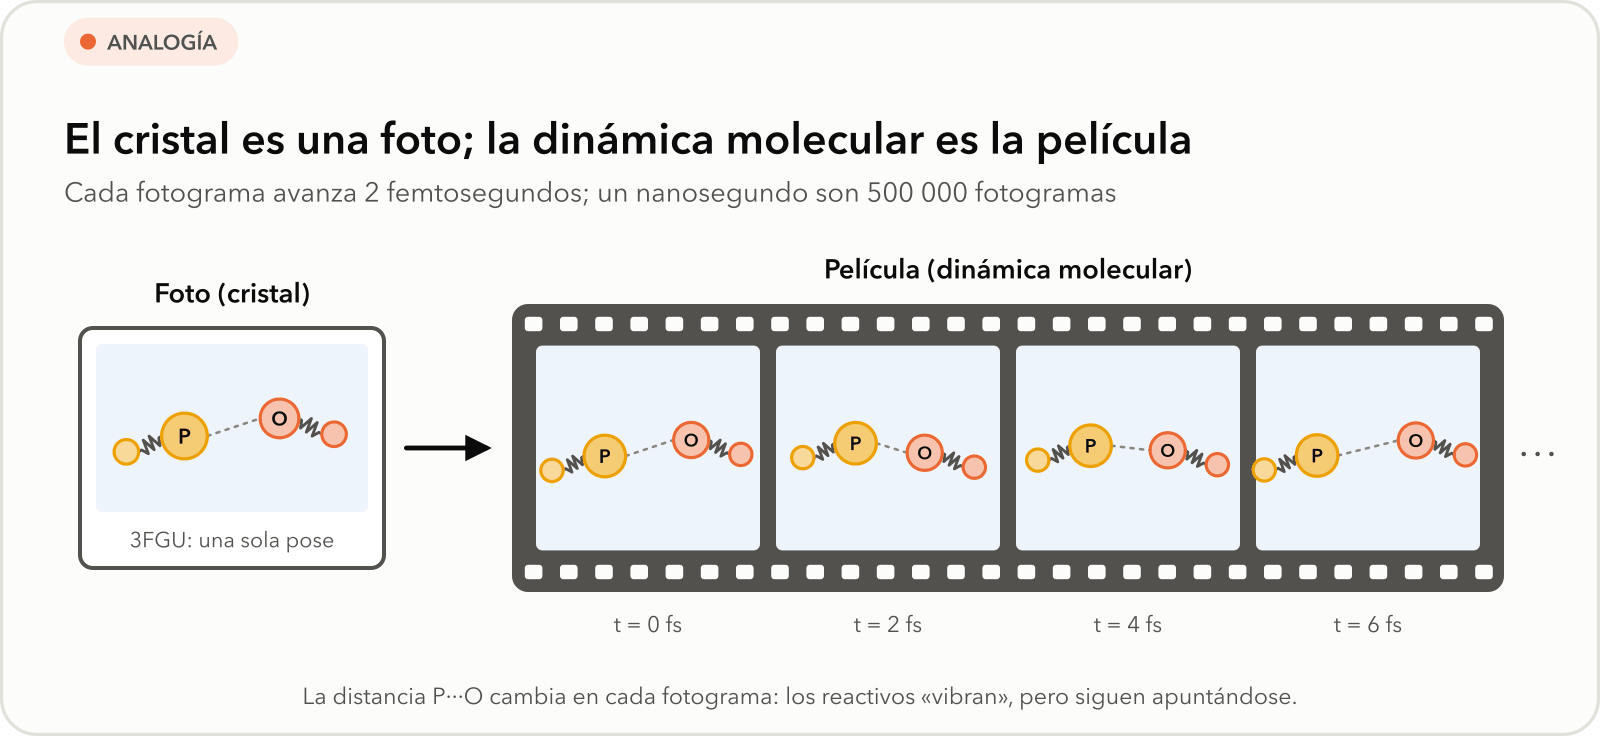

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para saber dónde estará cada átomo en el fotograma
siguiente. La receta es la de una mesa de billar: si sabes con qué fuerza empujan a una bola,
sabes cómo se acelera y dónde estará un instante después.

Cada átomo es una **bolita** con masa, unida a sus vecinas por **resortes** (los enlaces), y
además siente las **cargas** y los **choques** de las demás. Con eso, cada fotograma es una
vuelta del mismo ciclo:

$$\text{fuerzas} \;\rightarrow\; \text{aceleración} \;\rightarrow\; \text{posición nueva} \;\rightarrow\; \text{fuerzas} \;\rightarrow\; \cdots$$

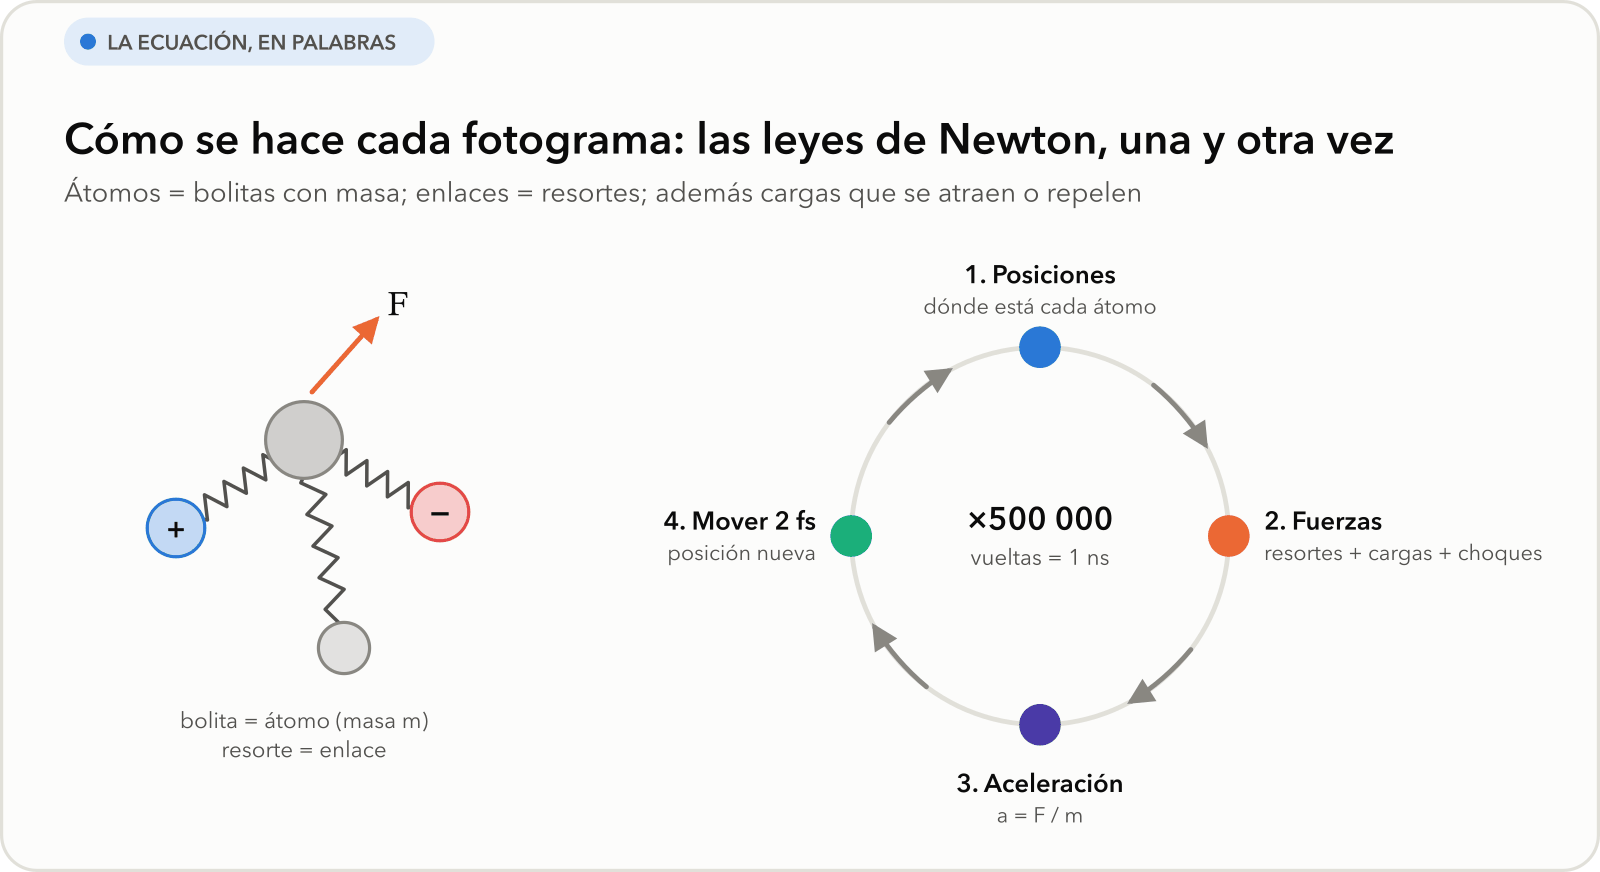

---

### 📐 La ecuación completa, término a término

La segunda ley de Newton para cada átomo *i*, y un paso de tiempo:

$${\color{#eb6834}{\mathbf{F}_i}} = m_i\,{\color{#4a3aa7}{\mathbf{a}_i}}
\qquad\Rightarrow\qquad
\mathbf{v}_i \leftarrow \mathbf{v}_i + {\color{#4a3aa7}{\mathbf{a}_i}}\,{\color{#1baf7a}{\Delta t}},
\qquad
{\color{#2a78d6}{\mathbf{r}_i}} \leftarrow {\color{#2a78d6}{\mathbf{r}_i}} + \mathbf{v}_i\,{\color{#1baf7a}{\Delta t}}$$

| Término | Qué es | En la analogía | Valor aquí |
|---|---|---|---|
| ${\color{#2a78d6}{\mathbf{r}_i}}$ | posición del átomo *i* | dónde está la bolita | ~57 000 átomos |
| ${\color{#eb6834}{\mathbf{F}_i}}$ | fuerza total sobre el átomo | tirones de los resortes + atracción/repulsión de las cargas + choques | campo de fuerza Amber ff14SB |
| $m_i$ | masa del átomo | lo pesada que es la bolita | H = 1, C = 12, O = 16 g/mol |
| ${\color{#4a3aa7}{\mathbf{a}_i}}$ | aceleración | cuánto cambia su velocidad | $\mathbf{F}_i/m_i$ |
| $\mathbf{v}_i$ | velocidad | hacia dónde y qué tan rápido va | ~ la que da la temperatura (300 K) |
| ${\color{#1baf7a}{\Delta t}}$ | paso de tiempo | tiempo entre fotogramas | 2 fs |

Las fuerzas salen de una **energía** $U$ que suma resortes, cargas y choques: cada átomo es
empujado "cuesta abajo" en esa energía, $\mathbf{F}_i = -\partial U/\partial \mathbf{r}_i$. El
programa (OpenMM) usa un integrador de Langevin, una versión más cuidadosa de este mismo ciclo que
además mantiene la temperatura en 300 K.

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| **Δt fuera mucho mayor** | la simulación "explota" | los átomos saltarían demasiado entre fotogramas y los resortes se estirarían sin control; 2 fs es posible porque se fijan las longitudes de los enlaces con H |
| **simulamos más tiempo** | vemos movimientos más lentos (dominios que se abren y cierran) | 1 ns son 500 000 vueltas del ciclo; los cambios grandes pueden tardar mucho más |
| **quisiéramos romper un enlace** | la MD clásica no puede | sus resortes no saben de electrones: para eso hace falta QM/MM (sección 7) |

---

### 🔬 Los datos reales

**Qué se hizo.** Con OpenMM y Amber: minimización, calentamiento hasta 300 K, equilibración a
1 bar y 1 ns de producción (script `02_dinamica_molecular.py`). Aquí no hay química (los enlaces
no se rompen): la MD sirve para ver **cuánto tiempo pasa el sitio activo en una geometría
reactiva**, con el Pγ del ATP cerca del O6 de la glucosa. Esas geometrías se llaman
**conformaciones de ataque cercano** (*near‑attack conformations*, NAC).

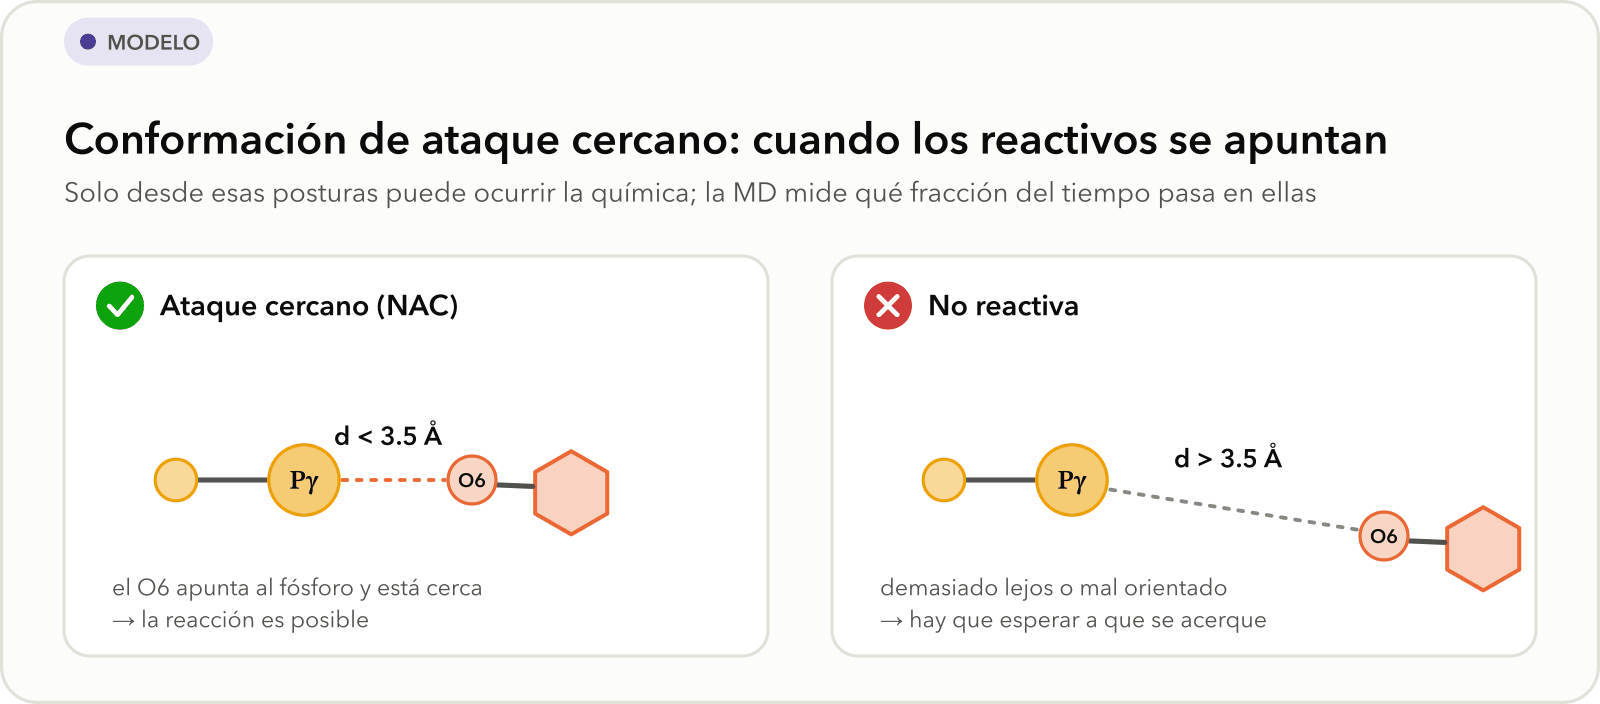

**Cómo leer la gráfica.** Cada punto es un fotograma de la película (uno cada 10 ps) y la línea
gruesa es la media móvil, que borra el temblor y deja ver la tendencia.

* **Arriba, grande:** la distancia entre el fósforo γ del ATP y el O6 de la glucosa. La franja
  verde es la **zona de ataque cercano** (d < 3.5 Å): mientras la curva está dentro, los reactivos
  "se apuntan". A la derecha, cuántos fotogramas caen en cada distancia y el porcentaje del tiempo
  dentro de la zona. La línea negra es el valor del cristal.
* **Abajo a la izquierda:** el RMSD, cuánto se ha alejado la proteína de la estructura inicial. Un
  valor plano de ~1 Å es poco: la enzima es estable y no se desarma.
* **Abajo a la derecha:** la distancia del O6 a la base catalítica, Asp205. La franja verde marca
  un puente de hidrógeno (< 3.2 Å). Fíjate en que en la simulación clásica Asp205 se queda **fuera**
  de la franja: volveremos a esto en la sección 10.

In [ ]:
# @title 🎬 La dinámica molecular: cómo se mueve la enzima
if MODO == "completo":
    subprocess.run([sys.executable, "scripts/02_dinamica_molecular.py"], check=True)

md_df = datos.csv("md/analisis.csv")
md_info = datos.json_("md/md.json")
fig = viz.plot_md_summary(md_df, crystal_value=2.68, crystal_hbond=2.5)
viz.mostrar(fig, viz.tarjetas(
    [("Película", f"{md_info['produccion_ns']:g}", "ns", f"{len(md_df)} fotogramas, uno cada {md_info['cuadro_ps']} ps", "gris"),
     ("Átomos simulados", f"{md_info['n_atomos']:,}".replace(",", " "), "", "proteína, ligandos, agua e iones", "gris"),
     ("RMSD medio", f"{md_df['rmsd_CA_A'].mean():.2f}", "Å", "la proteína apenas se deforma", "azul"),
     ("d(Pγ–O6) media", f"{md_df['d_PG_O6_A'].mean():.2f}", "Å", "cristal: 2.68 Å", "agua")]),
    viz.datos(pd.DataFrame({"tiempo": md_df["tiempo_ps"].round(0), "d(Pγ–O6)": md_df["d_PG_O6_A"],
                            "¿ataque cercano?": np.where(md_df["d_PG_O6_A"] < 3.5, "sí", "no"),
                            "d(O6···Asp205)": md_df["d_O6_OD1asp205_A"], "RMSD Cα": md_df["rmsd_CA_A"]}),
              "la dinámica molecular",
              "Cada fila es un fotograma de la película: el programa mide tres números en cada uno y con ellos dibuja "
              "las tres gráficas. La columna «¿ataque cercano?» es la que cuenta el porcentaje del título.",
              x="tiempo", y=["d(Pγ–O6)", "d(O6···Asp205)", "RMSD Cα"],
              calculadas={"¿ataque cercano?": "«sí» si d(Pγ–O6) < 3.5 Å"},
              unidades={"tiempo": "ps", "d(Pγ–O6)": "Å", "d(O6···Asp205)": "Å", "RMSD Cα": "Å"},
              formatos={"tiempo": "{:.0f}", "d(Pγ–O6)": "{:.2f}", "d(O6···Asp205)": "{:.2f}", "RMSD Cα": "{:.2f}"},
              resaltar={int(md_df["d_PG_O6_A"].idxmin()): ("más cerca", "agua"), int(md_df["d_PG_O6_A"].idxmax()): ("más lejos", "rojo")},
              barra="d(Pγ–O6)"))

### 🎬 La película

Aquí está la película de verdad: 100 fotogramas, uno cada 10 ps, alineados sobre la proteína. Las cintas
son la cadena de la enzima (dominio grande en azul y pequeño en rosa); en el centro, la glucosa, el ATP
y el Mg²⁺. A la derecha, la distancia Pγ–O6 fotograma a fotograma: el punto amarillo te dice si en ese
instante los reactivos están «listos para reaccionar» (banda verde).

In [ ]:
# @title 🎬 La película de la enzima (gírala y dale ▶)
visor3d.pelicula_md()

In [ ]:
# @title 🎯 ¿Cuánto tiempo pasa la enzima lista para reaccionar?
umbral = 3.5  # @param {type:"slider", min:2.8, max:4.5, step:0.1}
# umbral (Å): definición práctica de conformación de ataque cercano
fraccion = (md_df["d_PG_O6_A"] < umbral).mean()
viz.mostrar(
    viz.tarjetas([("Umbral elegido", f"{umbral:.1f}", "Å", "d(Pγ–O6) por debajo = «ataque cercano»", "gris"),
                  ("Tiempo en ataque cercano", f"{fraccion:.0%}", "", f"{int(round(fraccion * len(md_df)))} de {len(md_df)} fotogramas", "agua"),
                  ("d(Pγ–O6) media", f"{md_df['d_PG_O6_A'].mean():.2f}", "Å", None, "azul")]),
    viz.mensaje("La enzima mantiene a los reactivos «apuntándose» la mayor parte del tiempo. Sin enzima, en agua, "
                "ese encuentro sería un golpe de suerte. Mueve el deslizador y vuelve a ejecutar la celda.", "idea"))

> ✅ **Para llevar.** La MD es una película hecha con las leyes de Newton, un fotograma cada 2 fs.
> No rompe enlaces, pero dice algo clave: la enzima **mantiene a los reactivos apuntándose** la
> mayor parte del tiempo, y solo desde esas conformaciones de ataque cercano puede ocurrir la química.

## 6. Colinas de energía y velocidad de reacción

> 🎯 **En esta sección** entenderás por qué una colina de energía más baja significa una reacción
> más rápida, y cómo la ecuación de Eyring convierte la altura de esa colina en un número de
> reacciones por segundo.

---

### 💡 La analogía: una pelota que intenta cruzar una colina

Imagina una pelota en el fondo de un valle. Entre ese valle (los **reactivos**: glucosa + ATP) y
el valle vecino (los **productos**: glucosa‑6‑fosfato + ADP) hay una colina. La pelota no está
quieta: el calor la sacude sin parar y la lanza cuesta arriba una y otra vez. Casi siempre se
queda corta y rueda de vuelta. Muy de vez en cuando, un empujón especialmente fuerte la lleva
hasta la cima, y entonces cae al otro lado: **la reacción ocurrió**.

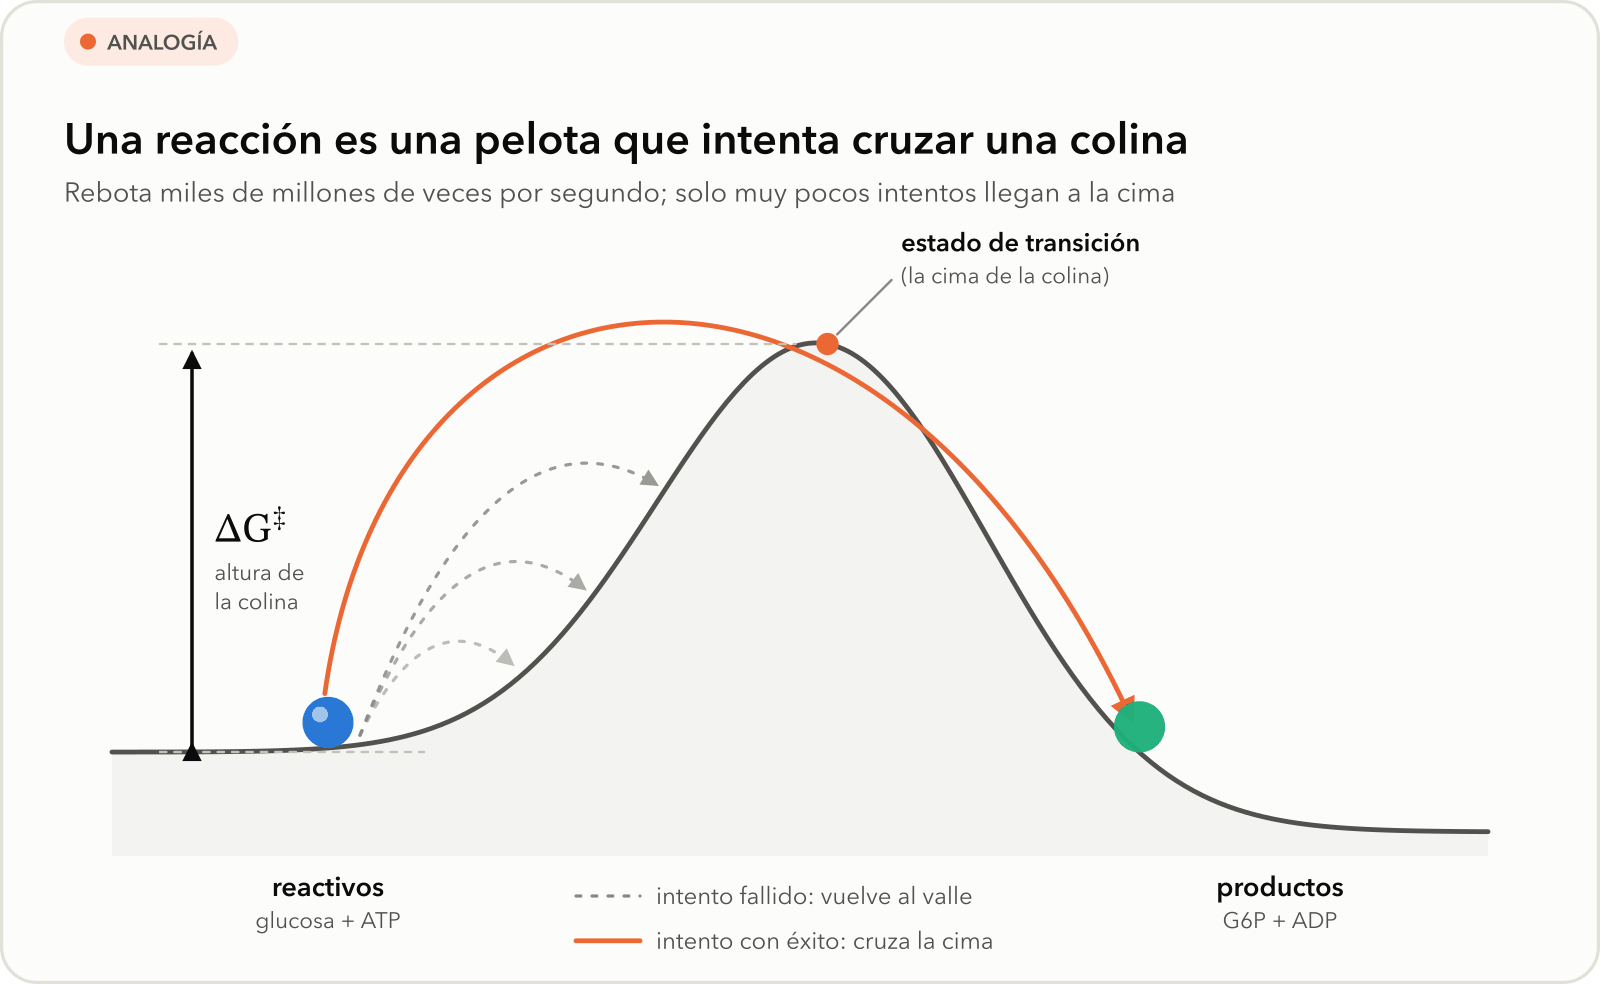

En química la colina se llama **barrera de activación** y su cima, **estado de transición**.
Una enzima no empuja más fuerte a la pelota: **rebaja la colina**.

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para pasar de "la colina es alta" a "la reacción ocurre
60 veces por segundo". Con un número podemos comparar la simulación con el experimento.

La idea es la de cualquier juego de azar: si tiras un dado muchas veces, el número de "seises"
por minuto es *(tiradas por minuto)* × *(probabilidad de sacar seis)*. Aquí:

$$\text{velocidad} \;=\; \underbrace{\text{intentos por segundo}}_{\text{muchísimos}} \;\times\; \underbrace{\text{probabilidad de llegar a la cima}}_{\text{diminuta}}$$

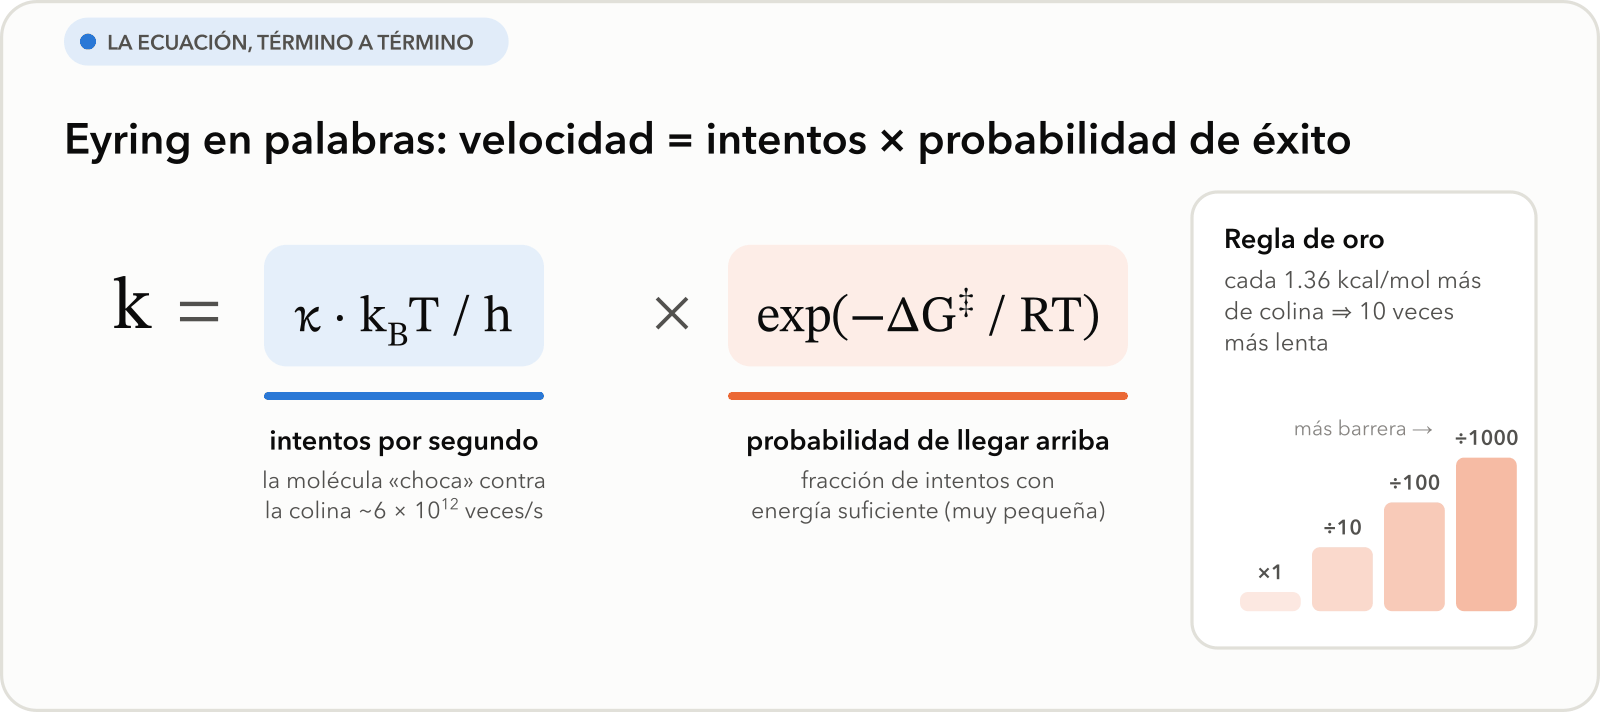

---

### 📐 La ecuación completa, término a término (Eyring, 1935)

$$k \;=\; {\color{#2a78d6}{\kappa\,\frac{k_B T}{h}}}\;\times\;{\color{#eb6834}{\exp\!\left(-\frac{\Delta G^{\ddagger}}{RT}\right)}}$$

El factor **azul** son los intentos; el **naranja**, la probabilidad de que un intento llegue a la
cima. Cada símbolo:

| Término | Qué es | En la analogía | Valor típico |
|---|---|---|---|
| $k$ | constante de velocidad | cuántas pelotas cruzan por segundo | ≈ 60 s⁻¹ para la glucoquinasa |
| $k_B T/h$ | frecuencia de intentos | cuántas veces por segundo la pelota se lanza cuesta arriba | 6.2 × 10¹² s⁻¹ a 25 °C |
| $\Delta G^{\ddagger}$ | energía libre de activación | la altura de la colina | 10–25 kcal/mol |
| $R T$ | energía térmica disponible | la fuerza típica de las sacudidas | 0.59 kcal/mol a 25 °C |
| $\kappa$ | coeficiente de transmisión | fracción de pelotas que, ya en la cima, no se arrepienten y vuelven | ≈ 1 |

¿Por qué una **exponencial**? Porque llegar alto exige muchas sacudidas favorables seguidas, y
la probabilidad de que ocurran a la vez se multiplica: cada escalón extra de altura divide la
probabilidad por el mismo factor. Por eso lo que importa es el cociente $\Delta G^{\ddagger}/RT$:
cuántas "sacudidas típicas" mide la colina.

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| **ΔG‡ sube 1.36 kcal/mol** | la reacción es **10 veces más lenta** | la exponencial cae a la décima parte (la regla de oro) |
| **T sube de 25 a 37 °C** | para una barrera de 15 kcal/mol, la velocidad **casi se duplica** | las sacudidas (RT) son un 4 % más fuertes y la exponencial lo amplifica |
| **la enzima baja ΔG‡ 10 kcal/mol** | la reacción va **10⁷ veces** más rápido | 10 / 1.36 ≈ 7 escalones de ×10 |

Muévelo tú mismo con los deslizadores:

In [ ]:
# @title 🎛️ Explora la ecuación de Eyring
# 🎛️ Explora la ecuación de Eyring: barrera y temperatura
interactivo.explorar_eyring()

In [ ]:
# @title 🎛️ Dibuja tu propia colina de energía
# 🎛️ Perfil de energía: barrera (cuesta) y energía de reacción (desnivel entre valles)
interactivo.explorar_perfil_energia()

In [ ]:
# @title 📉 Cada 1.36 kcal/mol, un factor 10
barreras = np.linspace(5, 30, 200)
kcat = valor("kcat_s", 60.0)
fig, ax = viz.figure(10.5, 5.8)
k_curva = cin.eyring_rate(barreras)
ax.fill_between(barreras, k_curva.min() / 1e3, k_curva, color=viz._tint(viz.COLORS["reactivo"], 0.9), zorder=1, lw=0)
ax.semilogy(barreras, k_curva, color=viz.COLORS["reactivo"], lw=2.8, zorder=3)
puntos = [(cin.barrier_from_rate(kcat), f"la glucoquinasa\nk_cat ≈ {kcat:.0f} s⁻¹", viz.COLORS["ts"], (12, 6), "left"),
          (cin.barrier_from_rate(1e-8), "una reacción que\ntarda años", viz.INK_SECONDARY, (-16, -10), "right")]
for dg, texto, color, off, ha in puntos:
    viz._guide(ax, "v", dg, start=k_curva.min() / 1e3, end=cin.eyring_rate(dg))
    viz._keypoint(ax, dg, cin.eyring_rate(dg), color, size=11)
    ax.annotate(f"{texto}\nΔG‡ ≈ {dg:.1f} kcal/mol", (dg, cin.eyring_rate(dg)), xytext=off, textcoords="offset points",
                ha=ha, va="bottom" if off[1] > 0 else "top", fontsize=11, color=viz.INK)
# la escalera: 3 escalones de 1.36 kcal/mol desde la barrera de la glucoquinasa
dg0 = cin.barrier_from_rate(kcat)
for j in range(3):
    a, b = dg0 + j * 1.364, dg0 + (j + 1) * 1.364
    ax.plot([a, b, b], [cin.eyring_rate(a), cin.eyring_rate(a), cin.eyring_rate(b)], color=viz.INK_MUTED, lw=1.2, zorder=4)
    ax.annotate("÷10", (b, np.sqrt(cin.eyring_rate(a) * cin.eyring_rate(b))), xytext=(4, 0), textcoords="offset points",
                ha="left", va="center", fontsize=10, color=viz.INK_SECONDARY)
ax.set_xlim(5, 30); ax.set_ylim(k_curva.min() / 1e3, k_curva.max() * 10)
viz._finish(ax, "ΔG‡: altura de la colina (kcal/mol)", "k (s⁻¹, escala log)",
            "Cada 1.36 kcal/mol de barrera, la velocidad cambia 10 veces",
            "Cada escalón gris sube la colina 1.36 kcal/mol y divide la velocidad entre 10.")
dg_tab = np.r_[np.arange(10, 30, 2.0), dg0]
dg_tab.sort()
k_tab = cin.eyring_rate(dg_tab)
viz.mostrar(fig, viz.datos(
    pd.DataFrame({"ΔG‡": dg_tab, "k": k_tab, "tiempo por reacción": [viz.duracion(1 / k) for k in k_tab]}),
    "la ecuación de Eyring",
    "Cada fila es un punto de la recta: se elige una altura de colina, se calcula k con la ecuación de Eyring a 25 °C "
    "y, dándole la vuelta, cuánto tarda en promedio una reacción.",
    x="ΔG‡", y="k", calculadas={"k": "(k_B·T/h) · exp(−ΔG‡/RT), con k_B·T/h = 6.2 × 10¹² s⁻¹ y RT = 0.59 kcal/mol",
                               "tiempo por reacción": "1 / k"},
    unidades={"ΔG‡": "kcal/mol", "k": "s⁻¹"}, formatos={"ΔG‡": "{:.1f}"},
    resaltar={int(np.argmin(np.abs(dg_tab - dg0))): ("k_cat", "naranja")}))

> ✅ **Para llevar.** Velocidad = intentos × probabilidad de éxito. Los intentos son casi fijos
> (~10¹³ por segundo); lo que decide todo es la altura de la colina, y cada 1.36 kcal/mol es un
> factor 10. Una enzima acelera la reacción **bajando la colina**, no empujando más fuerte.

## 7. Mirar la reacción con mecánica cuántica: QM/MM

> 🎯 **En esta sección** entenderás por qué hace falta mecánica cuántica para ver cómo el
> fosfato salta del ATP a la glucosa, por qué no se puede usar para toda la enzima y cómo el
> método **QM/MM** combina lo mejor de los dos mundos.

---

### 💡 La analogía: fotografiar un partido

Para fotografiar un partido no necesitas enfocar a los 50 000 espectadores: enfocas el balón y
los jugadores cercanos, y el estadio queda como fondo. En la enzima, "el balón" es el fosfato que
salta; el estadio, el resto de la proteína y el agua.

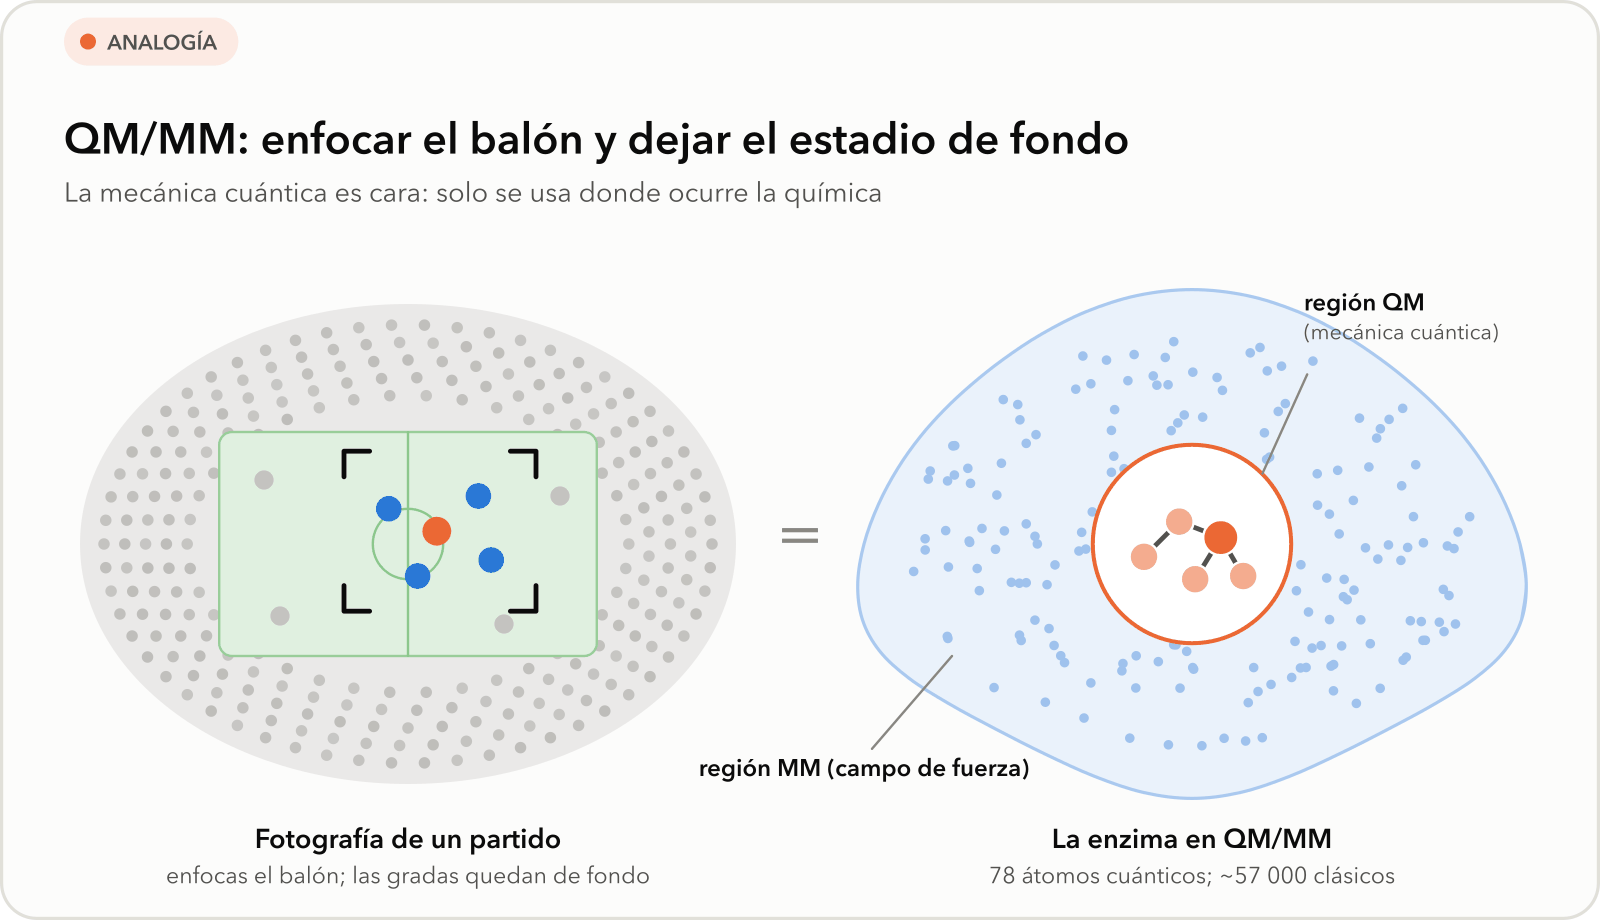

**¿Por qué no basta la dinámica molecular?** La dinámica molecular clásica de la sección 5 no
puede romper ni formar enlaces: sus resortes no saben de electrones. Para ver cómo el fosfato
salta del ATP a la glucosa hay que usar **mecánica cuántica (QM)**, que sí describe los
electrones. Pero es carísima: imposible para 57 000 átomos.

**La solución: QM/MM.** Se trata con QM solo el pedacito donde ocurre la química (la **región
QM**, unas decenas de átomos) y el resto con el campo de fuerza clásico (**región MM**). Las
dos regiones "se ven":

* las cargas de la región MM crean un potencial eléctrico que entra en el cálculo cuántico
  (**embedding electrostático**), y
* la región MM empuja a la QM con fuerzas de van der Waals (**Lennard‑Jones**): sin esto la
  región QM se "hundiría" en la proteína, porque la electrostática sola atrae.

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para buscar el camino de la reacción, el programa necesita
la energía (y las fuerzas) de cada geometría que prueba. En QM/MM esa energía tiene dos partes:

$$\text{energía} \;=\; \underbrace{\text{energía cuántica de la región QM (en el campo de la enzima)}}_{\text{la foto enfocada}} \;+\; \underbrace{\text{los «codos» entre QM y MM}}_{\text{no atravesar al público}}$$

Vuelve al estadio: los jugadores que enfocamos (la región QM) oyen los gritos de las gradas (las
cargas de la enzima, que atraen o repelen a sus electrones), pero no pueden meterse *dentro* del
público: los codos de la gente de alrededor se lo impiden (la repulsión de corto alcance).

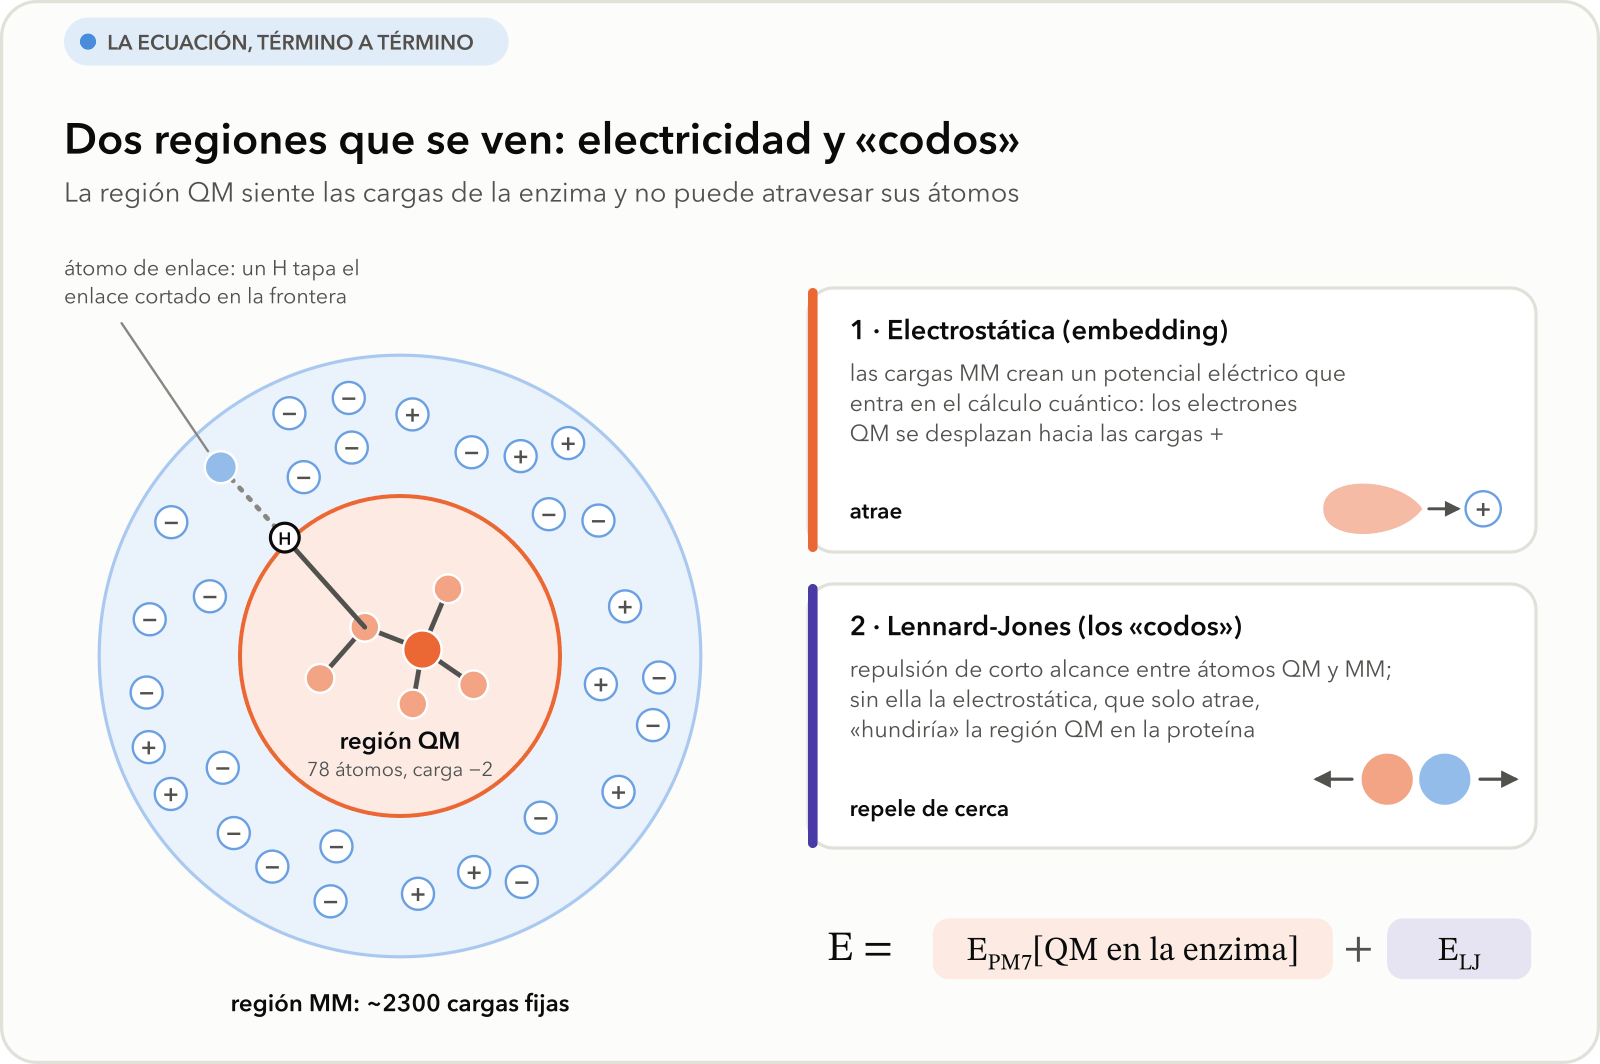

---

### 📐 La ecuación completa, término a término

$$E \;=\; {\color{#eb6834}{E_{\mathrm{PM7}}\big[\text{QM en el potencial de la enzima}\big]}} \;+\; {\color{#4a3aa7}{E_{\mathrm{LJ}}(\text{QM–MM})}}$$

| Término | Qué es | En la analogía | En nuestro modelo |
|---|---|---|---|
| ${\color{#eb6834}{E_{\mathrm{PM7}}[\dots]}}$ | energía de electrones y núcleos de la región QM, calculada con el método semiempírico PM7 | el grupo del centro, bien enfocado | 78 átomos, carga −2 |
| potencial de la enzima | el campo eléctrico de las cargas MM, incluido *dentro* del cálculo cuántico (embedding) | la música y los gritos del público | ~2300 cargas Amber dentro de 16 Å, fijas |
| ${\color{#4a3aa7}{E_{\mathrm{LJ}}}}$ | Lennard‑Jones entre átomos QM y MM: atracción débil de lejos, repulsión fuerte de cerca | los codos del público | parámetros Amber |
| átomo de enlace | un H que "tapa" cada enlace covalente cortado por la frontera | — | cadenas laterales cortadas en la frontera |

**Nuestra receta (herramientas de la suite Leonardo, MOPAC PM7 + Amber):**

* **Región QM** (78 átomos, carga −2): glucosa, el fragmento C5'–trifosfato del ATP, las cadenas
  laterales de Asp205, Lys169 y Thr228, el Mg²⁺ y su agua coordinada.
* Donde un enlace covalente cruza la frontera se pone un **átomo de enlace** (un H).
* El **entorno MM** (2300 cargas dentro de 16 Å) se mantiene **fijo** (aproximación de
  entorno rígido).
* Energía total: $E = E_{\mathrm{PM7}}[\text{QM en el potencial de la enzima}] + E_{\mathrm{LJ}}(\text{QM–MM})$.

---

### 🎛️ Qué pasa si…

| Si… | entonces… |
|---|---|
| **quitamos el potencial de la enzima** | la región QM ya no "ve" a la proteína: es como sacarla de ella (la sección 11 lo hace, en agua) |
| **quitamos el término Lennard‑Jones** | la electrostática, que solo atrae, "hunde" la región QM en la proteína y la geometría deja de tener sentido |
| **agrandamos la región QM** | el modelo es más fiel, pero cada cálculo cuesta mucho más |
| **dejamos que el entorno MM se mueva** | el cálculo sería más realista y mucho más caro; con el entorno fijo, la barrera depende de la conformación elegida (sección 10) |

---

### 🔬 Los datos reales: nuestra partición

In [ ]:
# @title 🔍 La región cuántica dentro de la enzima
particion = datos.json_("qmmm/particion.json")
print(f"Región QM: {particion['n_qm']} átomos + {particion['n_link']} H de enlace; libres: {particion['n_free']}")
print(f"Entorno MM: {particion['n_mm']} cargas puntuales; carga QM = {particion['qm_charge']}; carga MM = {particion['mm_charge']:.2f} e")
print("Átomos QM por residuo:", pd.Series([a["resname"] for a in particion["qm_atoms"]]).value_counts().to_dict())
display(visor3d.region_qm())

**¿Cómo sabemos que el programa calcula bien las fuerzas?** Comparando el gradiente analítico
con el numérico (mover un átomo 0.005 Å y ver cuánto cambia la energía). Es una comprobación
que todo código de simulación debería pasar antes de usarse:

In [ ]:
# @title 🧪 Control de calidad: fuerzas analíticas frente a numéricas
grad = datos.csv("qmmm/comprobacion_gradiente.csv")
grad["error relativo"] = (grad["diff"].abs() / grad["analytic"].abs().clip(lower=1e-6)).map(lambda x: f"{x:.1%}")
display(grad.round(3))

> ✅ **Para llevar.** QM/MM enfoca la mecánica cuántica donde ocurre la química (78 átomos) y
> trata el resto de la enzima como cargas y "codos" clásicos. La energía tiene dos partes: la
> energía cuántica de la región QM **dentro del campo eléctrico de la enzima** y la repulsión
> Lennard‑Jones que le impide hundirse en ella.

## 8. Reactivo, producto y el perfil de energía

> 🎯 **En esta sección** describirás toda la reacción con **un solo número**, la coordenada de
> reacción ξ, y obtendrás el primer perfil de energía de la transferencia del fosfato dentro de
> la enzima.

---

### 💡 La analogía: el pañuelo del tira y afloja

En un tira y afloja, el pañuelo atado al centro de la cuerda dice quién va ganando: si está del
lado de un equipo, gana ese equipo; si está en el centro, la cosa está igualada. Aquí la cuerda
es el grupo fosfato (el Pγ), y los dos "equipos" son el oxígeno O3β del ATP (que lo suelta) y el
oxígeno O6 de la glucosa (que lo recibe).

Primero relajamos la región QM en su punto de partida (el **reactivo**: glucosa + ATP). Luego
construimos el **producto** (glucosa‑6‑fosfato + ADP, con el protón de O6 ya en Asp205) y
también lo relajamos. La diferencia de energía dice si la reacción es "cuesta abajo" o "cuesta
arriba" dentro de la enzima.

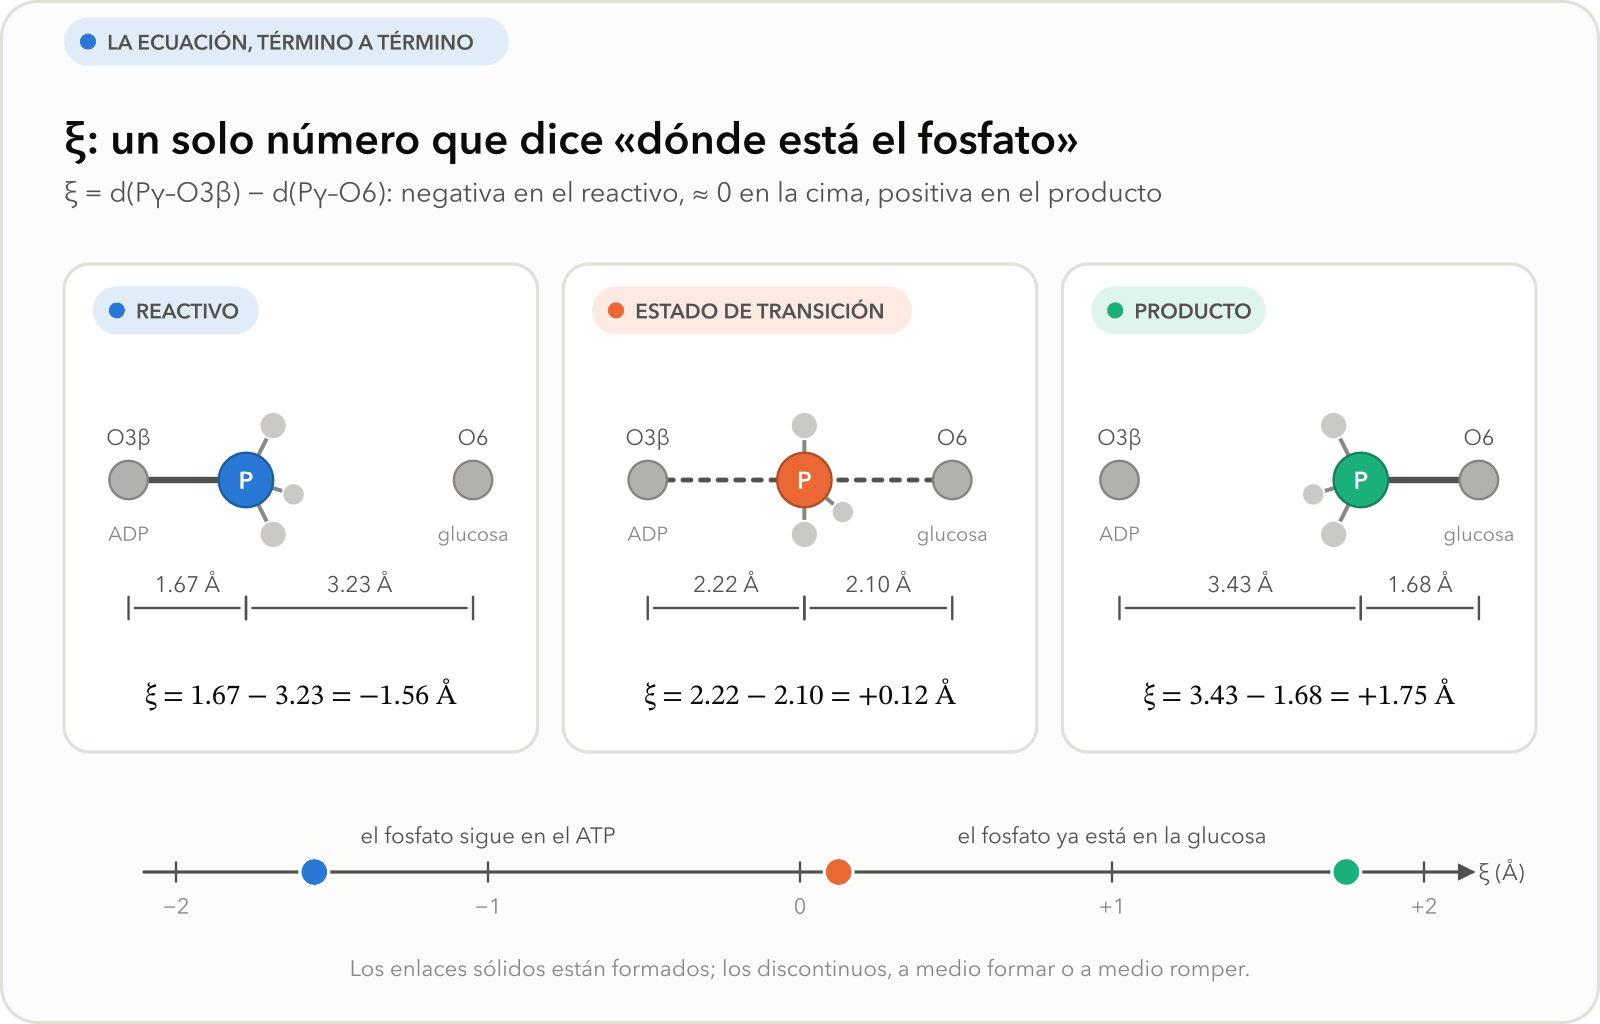

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Una reacción mueve decenas de átomos a la vez; para dibujar
un perfil de energía necesitamos un eje horizontal, un número que avance de forma continua
desde el reactivo hasta el producto.

$$\xi \;=\; \text{cuánto se ha alejado el fósforo del ADP} \;-\; \text{cuánto le falta para llegar a la glucosa}$$

---

### 📐 La ecuación completa, término a término

$$\xi \;=\; {\color{#2a78d6}{d(\mathrm{P_\gamma\!-\!O_{3\beta}})}} \;-\; {\color{#1baf7a}{d(\mathrm{P_\gamma\!-\!O_6})}}$$

El término **azul** es el enlace que se rompe (lado del reactivo); el **aguamarina**, el que se
forma (lado del producto).

| Situación | d(Pγ–O3β) | d(Pγ–O6) | ξ | En la analogía | En nuestro cálculo |
|---|---|---|---|---|---|
| reactivo (fosfato en el ATP) | corta (1.6 Å) | larga (3.2 Å) | negativa | el pañuelo en el campo del ATP | ξ = −1.56 Å |
| estado de transición | intermedia | intermedia | ≈ 0 | el pañuelo en el centro | ξ = +0.12 Å |
| producto (fosfato en la glucosa) | larga | corta (1.7 Å) | positiva | el pañuelo en el campo de la glucosa | ξ = +1.75 Å |

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| **el fósforo avanza 0.1 Å** hacia la glucosa, en línea | ξ sube unos **0.2 Å** | una distancia crece y la otra se acorta a la vez |
| **ξ = 0** | el fósforo está a igual distancia de los dos oxígenos, pero eso **no garantiza** que sea la cima | la cima es el máximo de energía, que se busca aparte (sección 9) |
| **fijamos ξ** en un valor intermedio y dejamos relajar lo demás | obtenemos un punto del **escaneo relajado** | la restricción sostiene la geometría "a medio camino" |

Un **escaneo relajado** fija ξ en valores intermedios (con una restricción armónica) y deja que
todo lo demás se acomode: el resultado es un **perfil de energía** aproximado, y su punto más
alto es una primera estimación del estado de transición.

---

### 🔬 Los datos reales

In [ ]:
# @title ⚗️ Reactivo y producto dentro de la enzima
if MODO == "completo":
    subprocess.run([sys.executable, "scripts/03_qmmm_reaccion.py"], check=True)

res = datos.json_("qmmm/resumen.json")
R, P = res["etapas"]["reactivo"], res["etapas"]["producto"]
viz.tarjetas(
    [("Reactivo · ξ", f"{R['xi']:+.2f}".replace("-", "−"), "Å",
      f"Pγ–O3β {R['d_PG_O3B']:.2f} Å (enlazado) · Pγ–O6 {R['d_PG_O6']:.2f} Å (libre)", "azul"),
     ("Producto · ξ", f"{P['xi']:+.2f}", "Å",
      f"Pγ–O6 {P['d_PG_O6']:.2f} Å (enlazado) · Pγ–O3β {P['d_PG_O3B']:.2f} Å (libre)", "agua"),
     ("El protón del O6", f"{P['d_OD1_H']:.2f}", "Å",
      f"en el producto está en Asp205 (en el reactivo, O6–H = {R['d_O6_H']:.2f} Å)", "violeta"),
     ("ΔE de reacción", f"{P['dE_reaccion_kcal']:+.1f}", "kcal/mol", "cuesta arriba dentro de la enzima (PM7, entorno fijo)", "naranja")],
    titulo="Los dos extremos de la reacción, relajados en la enzima")

In [ ]:
# @title 📈 El perfil de energía de la reacción
escaneo = datos.csv("qmmm/escaneo.csv")
xi_esc = np.r_[R["xi"], escaneo["xi"].values]                   # el perfil arranca en el reactivo relajado (E = 0)
e_esc = np.r_[0.0, escaneo["energia_rel_kcal"].values]
fig = viz.plot_energy_profile(xi_esc, e_esc, relative=False, xlabel="ξ = d(Pγ–O3β) − d(Pγ–O6)  (Å)",
                              ts_index=int(np.argmax(e_esc)), annotate_states=True,
                              state_names=("reactivo\nfosfato en el ATP", "cima: 1.ª estimación del TS", "producto\nfosfato en la glucosa"),
                              title=f"Para pasar el fosfato hay que subir una colina de {e_esc.max():.0f} kcal/mol",
                              subtitle="Escaneo relajado: se fija ξ en cada punto y se relaja todo lo demás (PM7 en el campo de la enzima)")
tabla_esc = pd.DataFrame({
    "punto": ["reactivo"] + [str(int(p)) for p in escaneo["punto"]],
    "ξ fijado": np.r_[np.nan, escaneo["xi_objetivo"].values],
    "Pγ–O3β": np.r_[R["d_PG_O3B"], escaneo["d_PG_O3B"].values],
    "Pγ–O6": np.r_[R["d_PG_O6"], escaneo["d_PG_O6"].values],
    "ξ": xi_esc,
    "O6–H": np.r_[R.get("d_O6_H", np.nan), escaneo["d_O6_H"].values],
    "E": e_esc})
k_ts = int(np.argmax(e_esc))
viz.mostrar(fig, viz.datos(
    tabla_esc, "el escaneo de la reacción",
    "Cada fila es una geometría optimizada. El programa fija ξ en un valor («ξ fijado»), relaja todos los demás átomos y "
    "mide la energía. Fíjate en cómo se alarga Pγ–O3β (el enlace que se rompe) mientras se acorta Pγ–O6 (el que se forma).",
    x="ξ", y="E", calculadas={"ξ": "d(Pγ–O3β) − d(Pγ–O6)", "E": "energía del punto − energía del reactivo relajado"},
    unidades={"ξ fijado": "Å", "Pγ–O3β": "Å", "Pγ–O6": "Å", "ξ": "Å", "O6–H": "Å", "E": "kcal/mol"},
    formatos={c: "{:.2f}" for c in ("ξ fijado", "Pγ–O3β", "Pγ–O6", "ξ", "O6–H")} | {"E": "{:.1f}"},
    resaltar={0: ("R", "azul"), k_ts: ("cima", "naranja"), len(tabla_esc) - 1: ("P", "agua")}, barra="E"))

> **Un detalle que llama la atención.** El perfil arranca con un salto de ~4 kcal/mol entre el
> reactivo (ξ = −1.56 Å, E = 0) y el primer punto del escaneo. La optimización inicial del
> reactivo se detuvo en un *hombro* de la superficie; el verdadero mínimo apareció después, al
> descender desde el estado de transición (sección 9). Lección práctica: un optimizador
> "convergido" no garantiza el mínimo más bajo; por eso los caminos de reacción se verifican en
> las dos direcciones.

### 🎬 Mírala ocurrir

Ahora la película: los átomos a la izquierda y, a la derecha, el **perfil de energía con un punto
amarillo que sigue a la película**. Pulsa ▶ o arrastra la barra. Fíjate en tres cosas:

1. El enlace **rosa** (Pγ–O3β, del ATP) se adelgaza y se vuelve discontinuo: **se está rompiendo**.
2. El enlace **verde agua** (Pγ–O6, hacia la glucosa) aparece y se engrosa: **se está formando**.
3. En la cima de la gráfica (el estado de transición) los dos están a medias: el fósforo está
   **entre** los dos oxígenos.

Solo se dibujan enlaces reales: los de la topología del modelo, más estos cuatro que cambian, con un
grosor proporcional a su orden de enlace (enteros si están formados, discontinuos si están a medio
formar o romper). Las líneas verdes finas son la coordinación del Mg²⁺, que no es un enlace covalente.
La película sigue el camino de mínima energía que se calcula en la sección 9, desde el reactivo
relajado hasta el producto.

In [ ]:
# @title 🎬 La reacción en movimiento, sincronizada con su energía
visor3d.pelicula_reaccion("enzima")

> ✅ **Para llevar.** ξ = d(Pγ–O3β) − d(Pγ–O6) resume la reacción en un solo número: negativa
> con el fosfato en el ATP, cerca de cero en la cima, positiva con el fosfato en la glucosa. Un
> escaneo relajado a lo largo de ξ da el primer perfil de energía y una primera estimación de la
> barrera, que la sección 9 afina.

## 9. El estado de transición

> 🎯 **En esta sección** localizarás el estado de transición de verdad (un punto de silla), lo
> **validarás** con sus frecuencias de vibración y comprobarás que conecta el reactivo con el
> producto.

---

### 💡 La analogía: el paso de montaña, otra vez

El escaneo nos dio una colina aproximada, pero forzando una sola distancia. El verdadero estado
de transición es un **punto de silla**: un máximo a lo largo del camino y un mínimo en todas las
demás direcciones, exactamente como el paso entre dos montañas (si te sales del camino, subes).

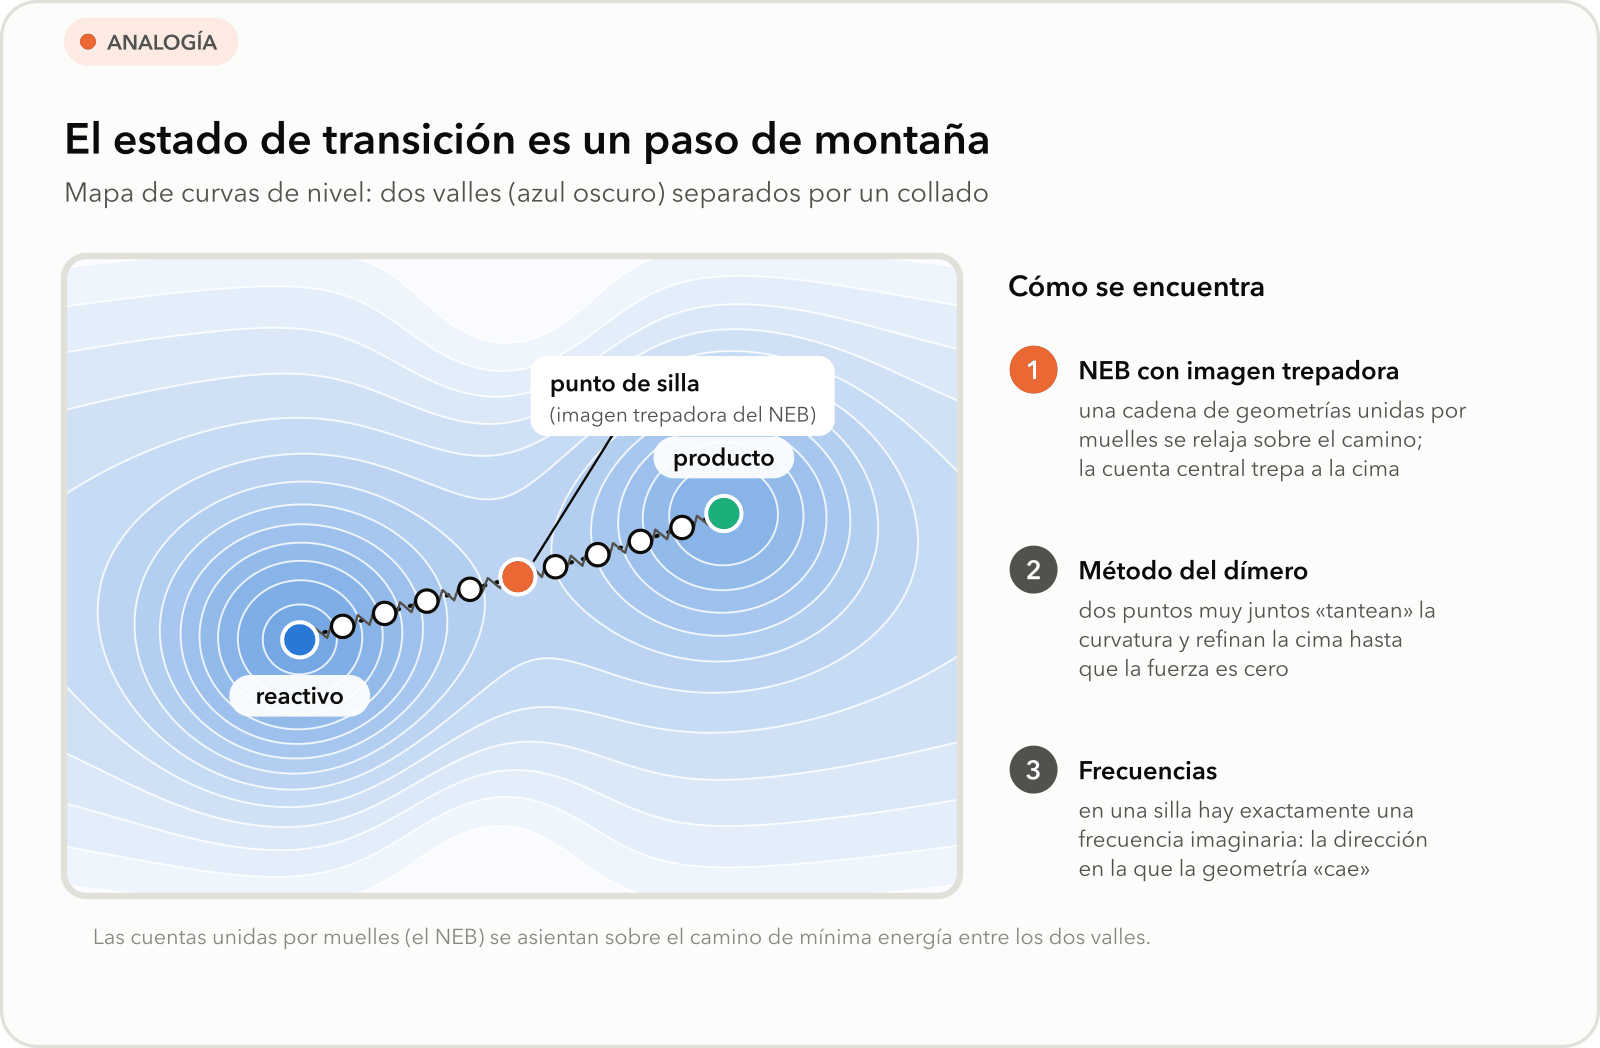

**Cómo se localiza (tres pasos):**

1. **NEB con imagen trepadora** (*nudged elastic band*): una cadena de geometrías entre reactivo
   y producto, unidas por muelles, que se relaja hasta dibujar el camino de mínima energía. La
   imagen más alta "trepa" hasta la cima. Es el análogo moderno del método **QST2** (dos
   extremos → TS) de Gaussian y MOPAC.
2. **Método del dímero**: refina la cima usando solo gradientes, hasta que la fuerza es cero.
3. **Frecuencias**: en un punto de silla verdadero hay **exactamente una** frecuencia imaginaria,
   y su vector describe el movimiento de la reacción. Es la prueba definitiva.

---

### 🧮 La prueba en palabras: ¿por qué "imaginaria"?

**¿Para qué queremos una ecuación?** En la cima la fuerza es cero… pero también lo es en el fondo
de un valle. Para distinguirlos miramos **la forma** del terreno alrededor, y eso lo dan las
vibraciones. Cada vibración es como un **resorte**: cuanto más empinadas las paredes, más rápido
oscila.

$$\text{frecuencia} \;\propto\; \sqrt{\text{rigidez del resorte}}$$

En un valle todas las paredes suben: todos los resortes son normales. En la silla, a lo largo del
camino el terreno **baja** a los dos lados: es un "resorte al revés" (rigidez negativa), y la raíz
cuadrada de un número negativo es un número **imaginario**. Los programas lo escriben como una
frecuencia negativa.

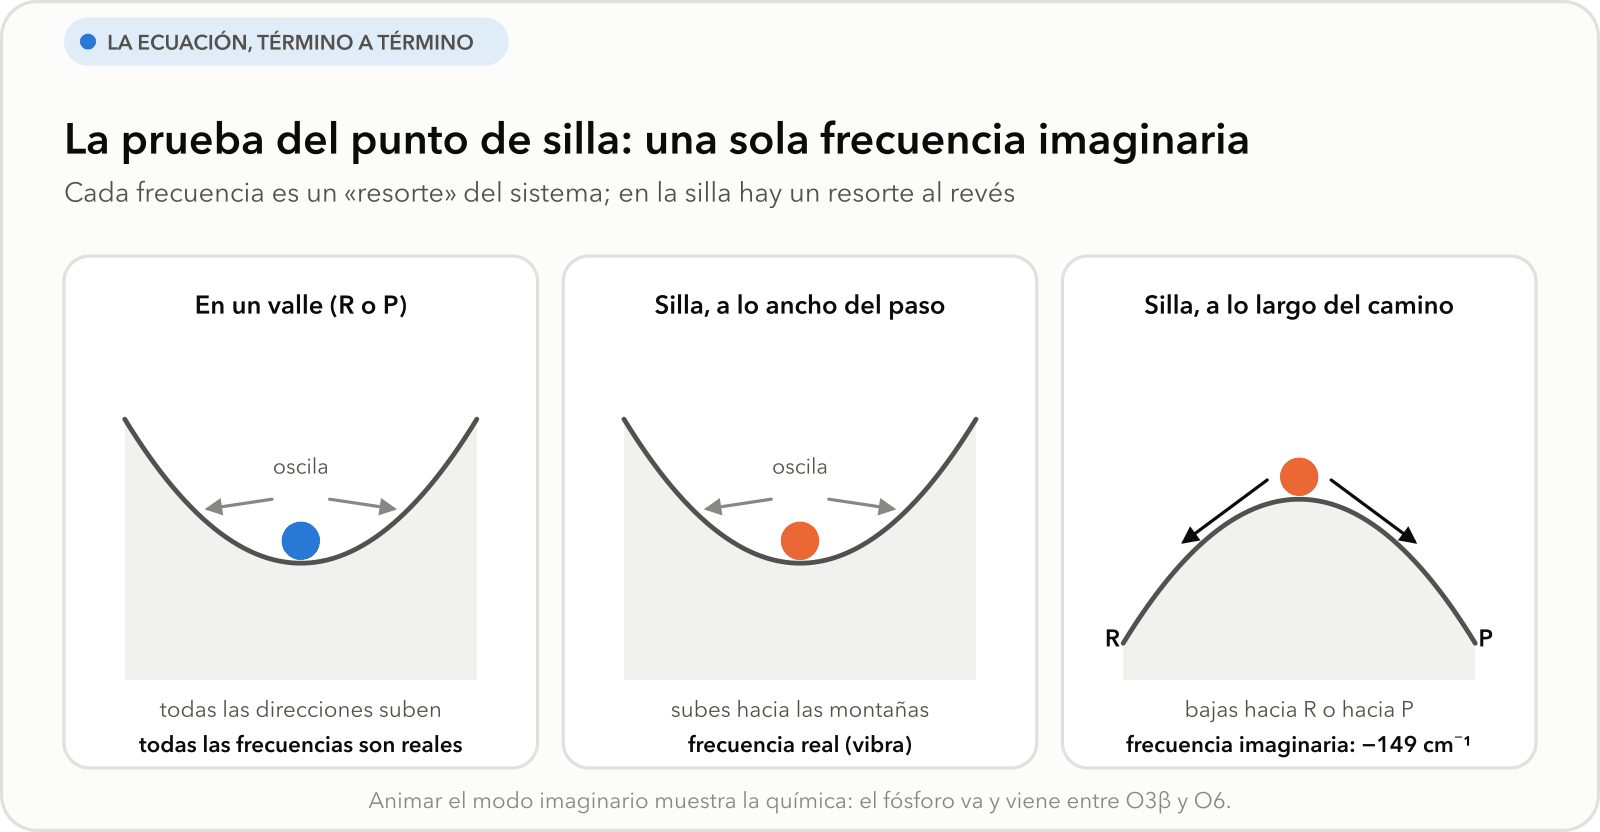

---

### 📐 La ecuación completa, término a término

$$\nu \;=\; \frac{1}{2\pi}\sqrt{\frac{{\color{#eb6834}{k}}}{\mu}}$$

| Término | Qué es | En la analogía | En el estado de transición |
|---|---|---|---|
| $\nu$ | frecuencia de la vibración (en cm⁻¹ en química) | cuántas veces por segundo oscila la bola | −149 cm⁻¹ en el modo de la reacción |
| ${\color{#eb6834}{k}}$ | curvatura de la energía en esa dirección | la rigidez del resorte: cuán empinadas son las paredes | **negativa** a lo largo del camino |
| $\mu$ | masa efectiva que se mueve | cuán pesada es la bola | sobre todo el fósforo y sus oxígenos |

---

### 🎛️ Qué pasa si…

| Si al calcular las frecuencias sale… | entonces la geometría es… |
|---|---|
| **ninguna** frecuencia imaginaria | un **mínimo** (reactivo, producto o un intermedio), no un TS |
| **exactamente una** | un **punto de silla de primer orden**: un estado de transición ✔ |
| **dos o más** | una cima en varias direcciones (silla de orden superior): hay que seguir buscando |

---

### 🔬 Los datos reales

In [ ]:
# @title ⛰️ Del escaneo al camino de mínima energía (NEB)
neb = datos.csv("qmmm/neb.csv")
perfiles = [(xi_esc, e_esc, "escaneo restringido"),
            (np.r_[R["xi"], neb["xi"].values[1:]], np.r_[0.0, neb["energia_rel_kcal"].values[1:]], "NEB (imagen trepadora)")]
fig = viz.plot_energy_profiles(perfiles, xlabel="ξ (Å)", relative=False, colors=[viz.INK_MUTED, viz.COLORS["reactivo"]],
                               title="El NEB encuentra la misma cima por un camino más natural",
                               subtitle="Gris: escaneo que fuerza una sola distancia. Azul: NEB, que relaja todas las coordenadas a la vez")
tabla_neb = pd.DataFrame({"imagen": neb["imagen"] if "imagen" in neb else np.arange(len(neb)),
                          "ξ": np.r_[R["xi"], neb["xi"].values[1:]], "E": np.r_[0.0, neb["energia_rel_kcal"].values[1:]]})
viz.mostrar(fig, viz.datos(
    tabla_neb, "el NEB (la cadena de imágenes)",
    "Cada fila es una «cuenta» de la cadena elástica que une reactivo y producto. Al final de la optimización la imagen más "
    "alta ha trepado hasta la cima: esa es la estimación del estado de transición.",
    x="ξ", y="E", unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
    resaltar={0: ("R", "azul"), int(tabla_neb["E"].idxmax()): ("trepadora", "naranja"), len(tabla_neb) - 1: ("P", "agua")},
    barra="E"))

In [ ]:
# @title ✅ El estado de transición y su frecuencia imaginaria
ts = res["etapas"].get("dimero")
if ts is None or not ts.get("convergido", True):
    display(viz.mensaje("El dímero no convergió: se usa la imagen trepadora del NEB como TS.", "ojo"))
    ts = ts or {**res["etapas"]["neb"], "xi": neb.loc[res["etapas"]["neb"]["imagen_ts"], "xi"], "d_PG_O6": float("nan"), "d_PG_O3B": float("nan")}
fr = res["etapas"].get("frecuencias", {})
val = fr["validacion"]
freqs = np.asarray(fr["frecuencias_mas_bajas"])
tarjetas_ts = viz.tarjetas(
    [("Barrera ΔE‡", f"{ts['barrera_kcal']:.1f}", "kcal/mol", "desde el reactivo relajado (método del dímero)", "naranja"),
     ("ξ en la cima", f"{ts['xi']:+.2f}", "Å", "casi cero: a medio camino", "naranja"),
     ("Pγ ··· O6 / Pγ ··· O3β", f"{ts['d_PG_O6']:.2f} / {ts['d_PG_O3B']:.2f}", "Å", "el fósforo, equidistante de los dos oxígenos", "azul"),
     ("Frecuencias imaginarias", f"{val['imaginary_mode_count']}", "", "punto de silla de primer orden ✔" if val["ok"] else "revisar ✘",
      "verde" if val["ok"] else "rojo")],
    titulo="El estado de transición, localizado y validado")
fig = viz.plot_frequencies([("TS en la enzima", freqs)],
                           title=f"Una sola frecuencia imaginaria ({freqs.min():.0f} cm⁻¹): es un punto de silla".replace("-", "−"),
                           subtitle="Las seis vibraciones más lentas del estado de transición; las demás son reales (positivas)")
viz.mostrar(tarjetas_ts, fig, viz.datos(
    pd.DataFrame({"modo": np.arange(1, len(freqs) + 1), "frecuencia": freqs,
                  "tipo": ["imaginaria: la geometría «cae»" if f < 0 else "real: la geometría vibra" for f in freqs]}),
    "las frecuencias más bajas del TS",
    "Las frecuencias salen de la matriz de segundas derivadas de la energía (el Hessiano). Por convención, una curvatura "
    "negativa se escribe como una frecuencia negativa («imaginaria»).",
    y="frecuencia", unidades={"frecuencia": "cm⁻¹"}, formatos={"frecuencia": "{:.1f}"},
    resaltar={int(np.argmin(freqs)): ("la reacción", "naranja")}))

**Qué nos dice la geometría del estado de transición.** En el TS el fósforo está a la misma
distancia de los dos oxígenos (≈ 2.1–2.2 Å de O6 y de O3β): es un TS **concertado y "en
línea"**; el fosfato pasa de un oxígeno al otro invirtiendo sus tres oxígenos como un paraguas.
El protón del O6, en cambio, **todavía no se ha movido** (sigue a ~1.07 Å de O6). Solo después
de cruzar la cima, cuando el enlace P–O6 ya está formado, el protón salta a Asp205: el camino
baja por una "meseta" hasta ξ ≈ 1 Å y allí termina de caer. En este modelo Asp205 actúa de base
**tras** la transferencia del fosforilo. Un estudio QM/MM independiente (Zhang et al., 2009)
describe a Asp205 como base general y a Lys169 como ácido general que protona el fosfato; que
dos modelos discrepen en el *orden* de los pasos, pero coincidan en la barrera (sección 12), es
un buen ejemplo de por qué los mecanismos se estudian con simulaciones y con mutantes.

**El movimiento del estado de transición.** La frecuencia imaginaria corresponde a una vibración
que no oscila sino que "cae" hacia reactivo o hacia producto. Animándola vemos la química: mira
cómo el fósforo va y viene entre el O3β del ATP y el O6 de la glucosa, y cómo el punto de la
gráfica cruza de la zona «hacia el reactivo» a la zona «hacia el producto»:

In [ ]:
# @title 🎞️ El movimiento del estado de transición
visor3d.modo_imaginario()

**Bajar de la cima.** Si empujamos el TS un poquito a cada lado a lo largo del modo imaginario
y dejamos que la geometría relaje, descendemos por el camino de mínima energía hasta el
reactivo y hasta el producto. Esto confirma que **este** TS conecta **estos** reactivos con
**estos** productos (la idea del IRC, *intrinsic reaction coordinate*).

In [ ]:
# @title ⬇️ Bajar de la cima hacia reactivo y producto
camino = datos.csv("qmmm/camino_descenso.csv")
fig = viz.plot_energy_profile(camino["xi"].values, camino["energia_rel_kcal"].values, relative=False, xlabel="ξ (Å)",
                              ts_index=int(camino["energia_rel_kcal"].idxmax()), smooth=False, sort=False, annotate_states=True,
                              state_names=("reactivo", "TS", "fin del descenso"),
                              title="Desde la cima se baja a los dos valles: este TS conecta R con P",
                              subtitle="Cada punto es una geometría relajada; la meseta tras la cima es el protón que pasa a Asp205")
viz.mostrar(fig, viz.datos(
    camino.rename(columns={"cuadro": "paso", "energia_rel_kcal": "E"})[["paso", "xi", "E"]].rename(columns={"xi": "ξ"}),
    "el descenso desde la cima",
    "Cada fila es un paso del descenso: desde el TS se empuja un poco hacia cada lado y se deja caer la geometría. Los pasos "
    "están en el orden del camino, de un valle a otro pasando por la cima.",
    x="ξ", y="E", unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
    resaltar={int(camino["energia_rel_kcal"].idxmax()): ("TS", "naranja")}, barra="E"))

In [ ]:
# @title 📊 Diagrama de energía de la reacción
niveles = [("E·S (reactivo)", 0.0), ("TS", ts["barrera_kcal"]), ("E·P (producto)", P["dE_reaccion_kcal"])]
fig = viz.plot_energy_levels(niveles, ts_indices=[1], title="La reacción en tres números",
                             subtitle="PM7/Amber, entorno fijo: energías electrónicas relativas (ΔE), todavía no energías libres")
viz.mostrar(fig, viz.datos(
    pd.DataFrame({"estado": [n for n, _ in niveles], "E": [e for _, e in niveles]}), "los tres niveles",
    "Las tres alturas del diagrama. La barrera es la diferencia TS − reactivo; la energía de reacción, producto − reactivo.",
    y="E", unidades={"E": "kcal/mol"}, formatos={"E": "{:.1f}"},
    resaltar={0: ("R", "azul"), 1: ("TS", "naranja"), 2: ("P", "agua")}))

> ✅ **Para llevar.** El estado de transición es un **punto de silla**: se localiza en pasos
> (escaneo → NEB → dímero) y se **valida** con dos pruebas: exactamente una frecuencia imaginaria
> (aquí −149 cm⁻¹, el fósforo que va y viene) y un camino que, al bajar de la cima, llega a los
> reactivos por un lado y a los productos por el otro.

## 10. De ΔE‡ a ΔG‡: tres mejoras del cálculo

> 🎯 **En esta sección** convertirás la barrera electrónica ΔE‡ en la energía libre ΔG‡ que pide
> la ecuación de Eyring, y aprenderás a preguntarte cuánto fiarte de un número calculado.

---

### 💡 La analogía: el topógrafo cuidadoso

Un topógrafo que ha medido la altura de una montaña **una vez, un día, con un instrumento** se
hace tres preguntas antes de publicar el número: ¿el terreno se mueve? ¿otro día habría medido
otra cosa? ¿mi instrumento está bien calibrado?

Hasta aquí tenemos una **energía electrónica** ΔE‡, calculada en **una** conformación de la
enzima con **un** método semiempírico. La ecuación de Eyring pide una **energía libre** ΔG‡. Un
buen científico computacional se hace las mismas tres preguntas, y las responde con cálculos
adicionales:

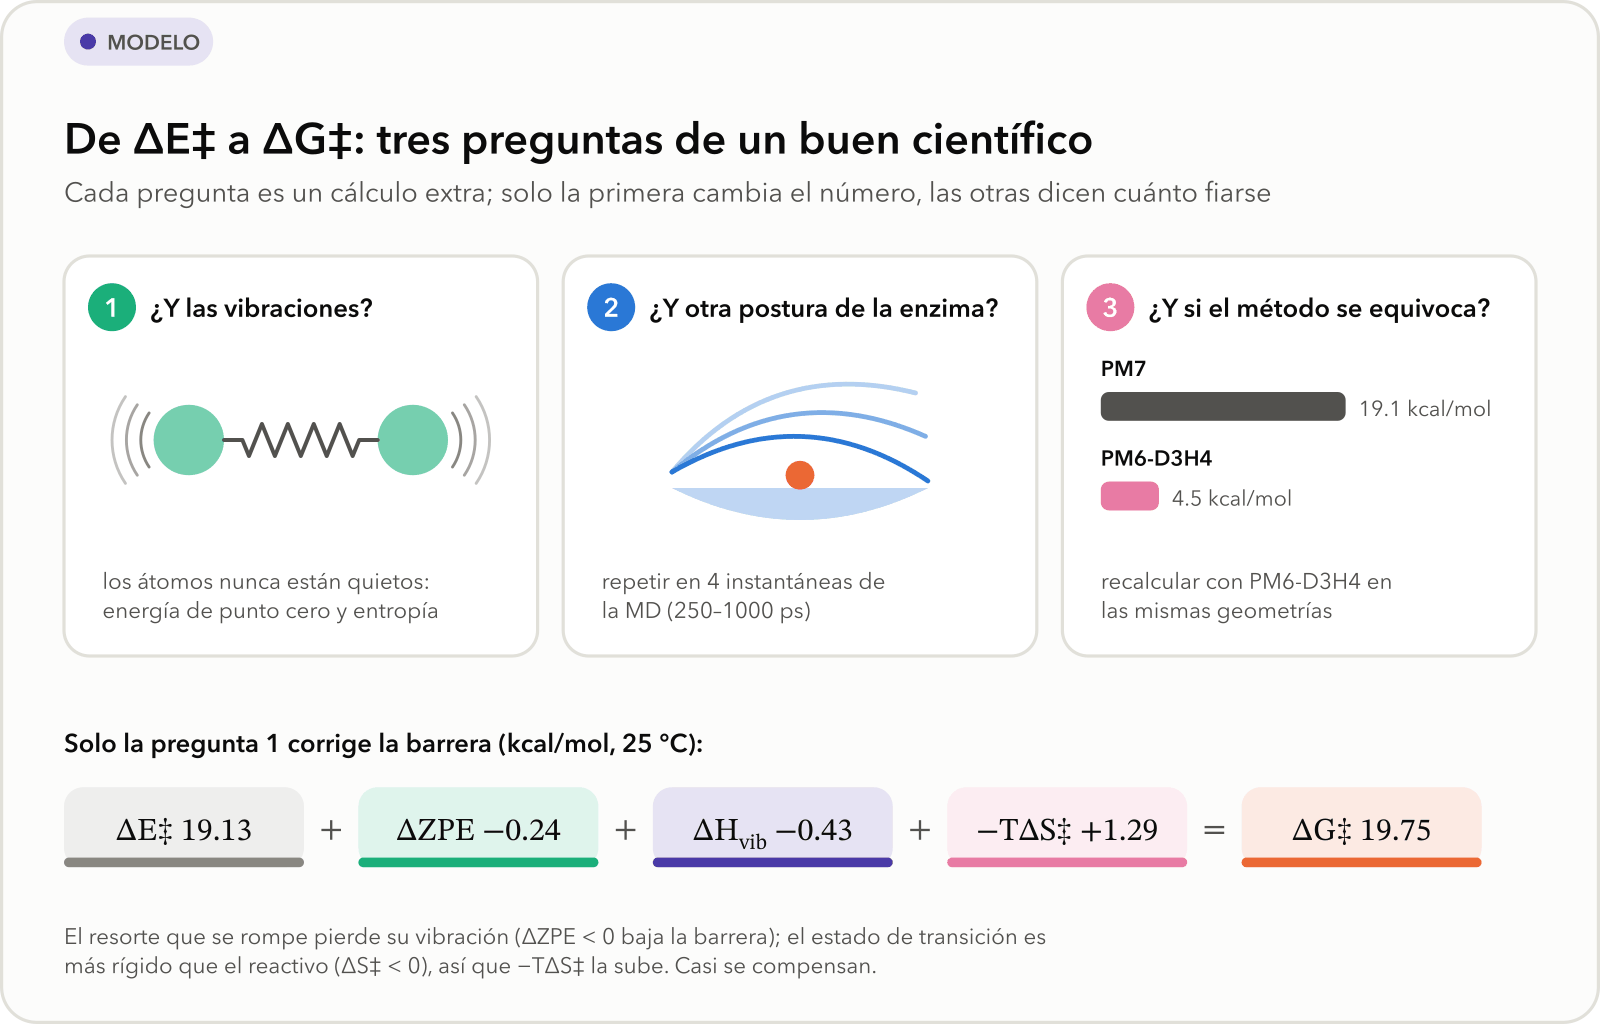

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Porque la altura "a secas" (ΔE‡) ignora que los átomos
vibran siempre. La energía libre suma lo que cuesta, o lo que se ahorra, en vibración y en orden:

$$\text{barrera libre} \;=\; \text{barrera electrónica} \;+\; \text{vibración en reposo} \;+\; \text{vibración térmica} \;-\; T\times\text{(cambio de desorden)}$$

---

### 📐 La ecuación completa, término a término

$$\Delta G^{\ddagger} = \Delta E^{\ddagger} + {\color{#1baf7a}{\Delta \mathrm{ZPE}}} + {\color{#4a3aa7}{\Delta H_{\mathrm{vib}}(T)}} - {\color{#e87ba4}{T\,\Delta S_{\mathrm{vib}}(T)}}$$

| Término | Qué es | En la analogía | Nuestro valor (25 °C) |
|---|---|---|---|
| **ΔE‡** | altura electrónica de la colina, átomos quietos | la medida "de un día" | 19.1 kcal/mol |
| **ΔZPE** | cambio de la **energía de punto cero**: incluso a 0 K los átomos vibran | el terreno tiembla aunque no haya viento | −0.2 kcal/mol |
| **ΔH<sub>vib</sub>(T)** | energía vibracional extra a la temperatura T | el temblor extra de un día caluroso | −0.4 kcal/mol |
| **−TΔS<sub>vib</sub>** | el precio del orden: un TS más rígido que el reactivo tiene ΔS‡ negativa | ordenar un cuarto cuesta trabajo | +1.3 kcal/mol |

* **ΔZPE**: el enlace P–O que se rompe pierde su vibración de tensión en el TS, así que suele
  ser **negativa** (baja la barrera).
* **−TΔS‡**: si el TS es más "rígido" que el reactivo (ΔS‡ < 0), este término **sube** la barrera.

**Las otras dos preguntas no cambian la fórmula, sino la confianza en el número:**

**2. ¿Y si la enzima estuviera en otra postura?** Como el entorno está fijo, cada instantánea
de la MD puede dar una barrera distinta. Repetimos el cálculo en varias instantáneas (250, 500,
750 y 1000 ps) para ver **si la barrera cambia y por qué**. Un buen resultado no es un número:
es un número con su incertidumbre, y a veces la respuesta es que la reacción ni siquiera es
posible desde algunas conformaciones.

**3. ¿Y si el método se equivoca?** PM7 es semiempírico. Recalculamos las energías con otro
hamiltoniano (PM6‑D3H4) en las mismas geometrías: si la barrera cambia poco, el resultado es
robusto; si cambia mucho, sabemos cuánto (des)confiar.

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| **la temperatura sube de 25 a 37 °C** | ΔG‡ apenas sube (de 19.75 a 19.80 kcal/mol) | con ΔS‡ ≈ −4.3 cal/mol/K, 12 K más solo añaden 12 × 0.0043 ≈ 0.05 kcal/mol |
| **el TS fuera más flexible que el reactivo** (ΔS‡ > 0) | el término entrópico **bajaría** la barrera | −TΔS‡ cambiaría de signo |
| **cambiamos de método** (PM7 → PM6‑D3H4) | la barrera pasa de 19.1 a 4.5 kcal/mol | los métodos semiempíricos se calibran con moléculas concretas |

---

### 🔬 Los datos reales

In [ ]:
# @title 🎻 Las vibraciones: de ΔE‡ a ΔG‡
termo = res["etapas"].get("termoquimica", {})
T_ref = "298.15"
if T_ref in termo:
    t = termo[T_ref]
    extra = [f"a {float(Tk) - 273.15:.0f} °C: ΔG‡ = {termo[Tk]['dG_kcal']:.2f} kcal/mol" for Tk in ("303.15", "310.15") if Tk in termo]
    display(viz.tarjetas(
        [("ΔE‡ electrónica", f"{t['dE_kcal']:.2f}", "kcal/mol", "la colina con los átomos quietos", "gris"),
         ("ΔZPE", f"{t['dZPE_kcal']:+.2f}", "kcal/mol", "el resorte P–O que se rompe deja de vibrar", "agua"),
         ("ΔS‡ vibracional", f"{t['dS_vib_cal']:+.1f}", "cal/mol/K", f"TS más rígido → −TΔS‡ = {-298.15 * t['dS_vib_cal'] / 1000:+.2f} kcal/mol", "magenta"),
         ("ΔG‡ a 25 °C", f"{t['dG_kcal']:.2f}", "kcal/mol", f"ΔH‡ = {t['dH_kcal']:.2f} kcal/mol", "naranja")],
        titulo="Termoquímica armónica (átomos libres de la región QM)",
        nota=" · ".join(extra) + ("  —  " + textos.t(termo["nota"]) if termo.get("nota") else "")))
else:
    display(viz.mensaje("Termoquímica no disponible en estos datos.", "ojo"))

In [ ]:
# @title 📸 La barrera en distintas conformaciones de la MD
try:
    inst = datos.json_("qmmm/instantaneas.json")
    def _hay(v):
        return v is not None and np.isfinite(v)
    filas = []
    for r in inst["instantaneas"]:
        b = r.get("barrera_kcal")
        if _hay(b):
            que = f"TS encontrado ({r.get('ts_origen', 'dímero')}): barrera {b:.1f} kcal/mol, hay producto estable"
        else:
            que = (f"sin producto estable: la energía sube hasta {r['escaneo_max_rel_kcal']:.0f} kcal/mol en ξ = {r['xi_max']:.1f} Å; "
                   f"el H del O6 está a {r['d_OD1_H_reactivo']:.1f} Å de Asp205")
        filas.append((textos.t(r["instantanea"]), b if _hay(b) else np.nan, r.get("ts_d_PG_O6", np.nan), r.get("ts_d_PG_O3B", np.nan), que))
    df_inst = pd.DataFrame(filas, columns=["conformación", "ΔE‡ (kcal/mol)", "d(Pγ–O6) TS (Å)", "d(Pγ–O3β) TS (Å)", "¿qué pasó?"])
    ok = df_inst.dropna(subset=["ΔE‡ (kcal/mol)"])
    media, sd = ok["ΔE‡ (kcal/mol)"].mean(), ok["ΔE‡ (kcal/mol)"].std(ddof=1) if len(ok) > 1 else 0.0

    esc_inst = datos.csv("qmmm/instantaneas_escaneos.csv")
    fallidas = [(g["xi"].values, g["energia_rel_kcal"].values, nombre) for nombre, g in esc_inst.groupby("instantanea", sort=False)]
    fig = viz.plot_snapshot_scans((xi_esc, e_esc), fallidas,       # el mismo escaneo del cristal de la sección 8
                                  title="Desde la conformación equivocada, la reacción no tiene a dónde ir",
                                  subtitle="Escaneos de ξ. Azul: el cristal minimizado (cima y valle de producto). Rojo: cuatro fotogramas de la MD en los que Asp205 se alejó")
    viz.mostrar(fig, viz.tabla(df_inst, titulo="Qué pasó en cada conformación",
                               formatos={"ΔE‡ (kcal/mol)": "{:.1f}", "d(Pγ–O6) TS (Å)": "{:.2f}", "d(Pγ–O3β) TS (Å)": "{:.2f}"},
                               nota="«—»: no hay estado de transición que medir, porque sin producto estable no hay cima entre dos valles."),
                viz.datos(esc_inst.pivot_table(index="punto", columns="instantanea", values="energia_rel_kcal", sort=False)
                          .reset_index().rename(columns={"punto": textos.t("punto")}).assign(**{"ξ (media)": esc_inst.groupby("punto")["xi"].mean().values})
                          [[textos.t("punto"), "ξ (media)"] + list(dict.fromkeys(esc_inst["instantanea"]))],
                          "las curvas rojas",
                          "Cada fila es un punto del escaneo (ξ fijado cada vez más a la derecha); cada columna, una conformación "
                          "de la MD. En ninguna columna la energía llega a un máximo y vuelve a bajar: no hay cima ni valle de producto.",
                          x="ξ (media)", y=list(dict.fromkeys(esc_inst["instantanea"])),
                          unidades={"ξ (media)": "Å", **{c: "kcal/mol" for c in esc_inst["instantanea"].unique()}},
                          formatos={"ξ (media)": "{:+.2f}", **{c: "{:.1f}" for c in esc_inst["instantanea"].unique()}},
                          nota="ξ varía unas centésimas entre conformaciones; se muestra su media."))
    if len(ok) > 1:
        display(viz.mensaje(f"Barrera media = {media:.1f} ± {sd:.1f} kcal/mol (n = {len(ok)})", "dato"))
except FileNotFoundError:
    display(viz.mensaje("Promedio sobre instantáneas no disponible en estos datos.", "ojo"))

**Lo que enseñan las instantáneas de la MD.** En la conformación cristalina minimizada, el
hidroxilo O6–H de la glucosa está unido por puente de hidrógeno a Asp205 (1.7 Å) y el camino
tiene un producto estable. En varias instantáneas de la dinámica clásica, en cambio, Asp205 se
ha alejado del O6–H (en la MD la distancia O6···OD1 promedia 4.3 Å, sección 5): al forzar la
transferencia del fosforilo el protón **no encuentra a la base** y la energía sube sin parar,
sin mínimo de producto. Dos lecciones: (1) la reacción solo puede ocurrir desde las
**conformaciones de ataque cercano** correctas, que son una fracción del tiempo; (2) el campo de
fuerza clásico no siempre mantiene la geometría catalítica (aquí, la interacción
hidroxilo–carboxilato junto al Mg²⁺), y por eso el modelador debe comparar la MD con el cristal
antes de elegir la estructura de partida del QM/MM. Una barrera "promedio" solo tiene sentido
sobre conformaciones reactivas.

In [ ]:
# @title ⚖️ ¿Y con otro método?
met = res["etapas"].get("metodos", {})
colores = {"PM7": "azul", "PM6-D3H4": "magenta"}
items = [(f"{nombre}//PM7", f"{d['barrera_kcal']:.1f}", "kcal/mol de barrera",
          f"ΔE(reacción) = {d['dE_reaccion_kcal']:+.1f} kcal/mol", colores.get(nombre, "gris"))
         for nombre, d in met.items() if isinstance(d, dict)]
viz.tarjetas(items, titulo="Las mismas geometrías, dos hamiltonianos semiempíricos", nota=textos.t(met.get("nota", "")))

**Lo que dicen estos números.** La corrección vibracional es pequeña (ΔZPE ≈ −0.2 y −TΔS‡ ≈ +1.3
kcal/mol se compensan en parte): ΔG‡ ≈ ΔE‡ + 0.6 kcal/mol. El promedio sobre instantáneas dice
cuánto "respira" la barrera con la conformación de la enzima. Y el cambio de hamiltoniano es la
sorpresa: PM6‑D3H4 da energías muy distintas en las mismas geometrías. Los métodos semiempíricos
se parametrizan frente a conjuntos concretos de moléculas, y el trío fosfato + Mg²⁺ + carboxilato
es un caso difícil para ellos (fósforo hipervalente, cargas altas, un catión divalente). La
lección: **antes de creer una barrera, hay que saber para qué química fue calibrado el método**
y, si es posible, comparar con un cálculo de más nivel (DFT) o con el experimento (sección 12);
aquí PM7 resulta coherente con otro cálculo QM/MM publicado y con el experimento, y PM6‑D3H4 no.

> ✅ **Para llevar.** ΔG‡ = ΔE‡ + ΔZPE + ΔH_vib − TΔS_vib: las vibraciones corrigen poco
> (19.1 → 19.75 kcal/mol, porque ΔZPE y −TΔS‡ casi se compensan). Las otras dos preguntas no
> cambian el número sino la **confianza** en él: la barrera solo tiene sentido desde
> conformaciones reactivas, y un método mal calibrado para fosfato + Mg²⁺ puede dar un valor muy
> distinto.

## 11. La misma reacción **fuera** de la enzima

> 🎯 **En esta sección** medirás cuánto de la catálisis hace *el resto* de la proteína, repitiendo
> la reacción con el sitio activo sumergido en agua, y conocerás los buscadores de estado de
> transición nativos de MOPAC.

---

### 💡 La analogía: la misma canción, fuera del estadio

¿Cuánto del sonido de un concierto se debe a la banda y cuánto a la acústica del estadio? Para
saberlo, la banda toca la misma canción en un estudio. Aquí la "banda" es el sitio activo y el
"estadio", el resto de la proteína.

Sacamos el sitio activo (el mismo clúster QM, con sus anclajes fijos) y lo ponemos en **agua**
(disolvente implícito COSMO), sin el campo eléctrico de los otros 2300 átomos. Si la barrera
cambia, ese cambio es obra del entorno proteico.

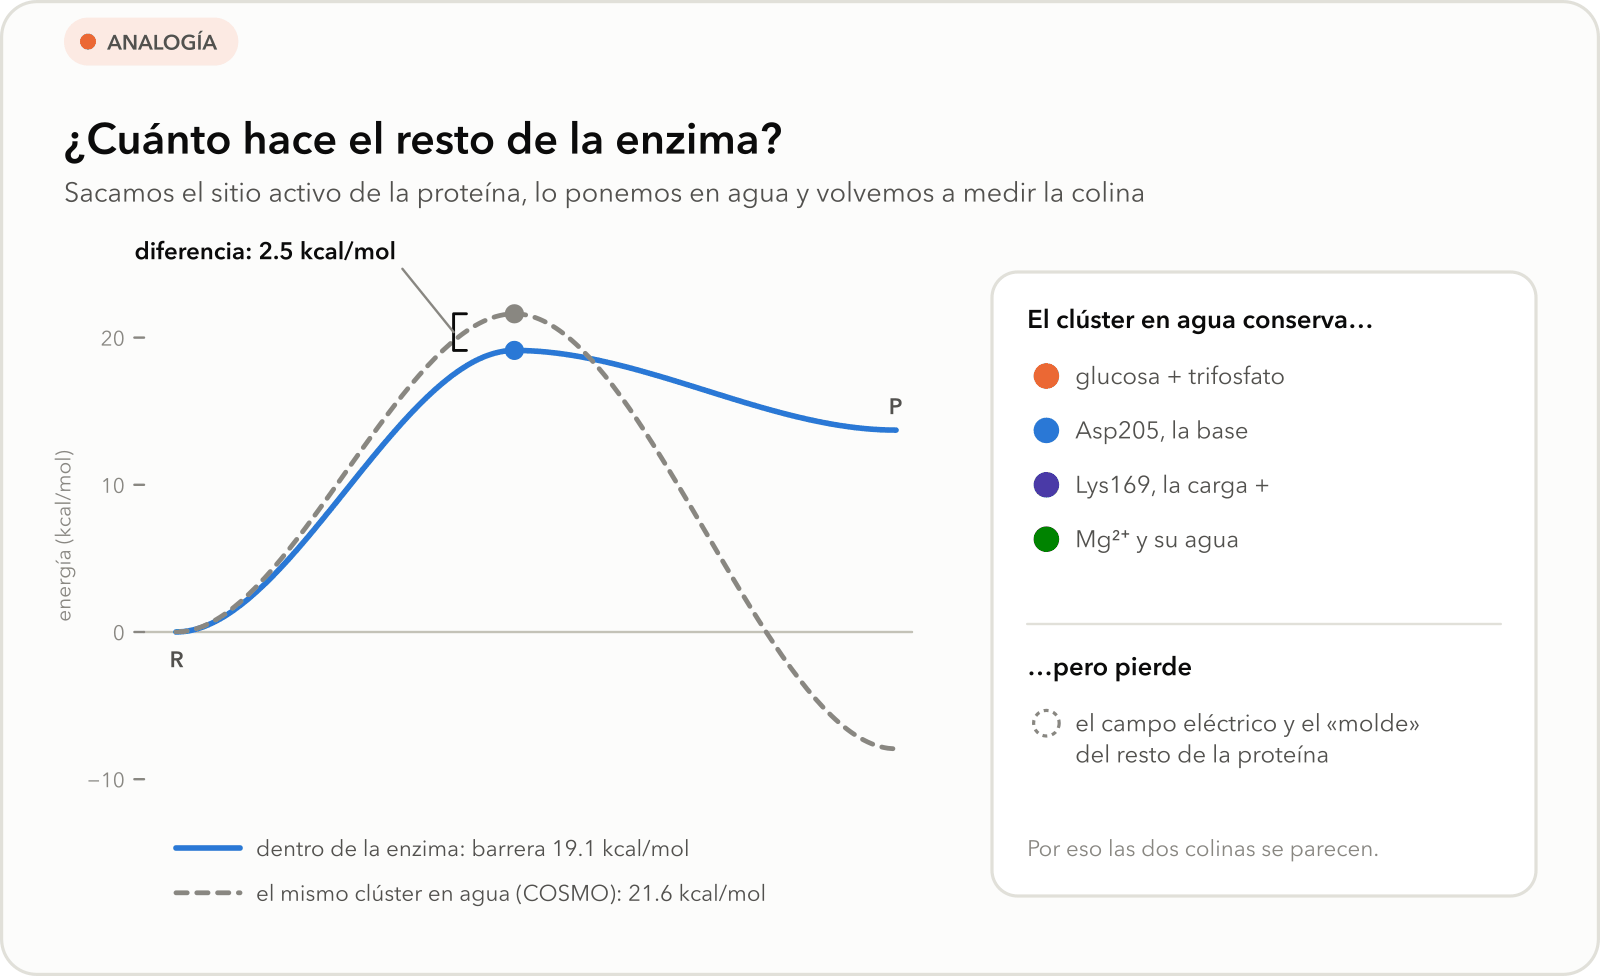

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para poner un número al "aporte del estadio":

$$\text{efecto del resto de la proteína} \;=\; \text{barrera dentro de la enzima} \;-\; \text{barrera del clúster en agua}$$

$$\Delta\Delta E^{\ddagger}_{\text{entorno}} \;=\; {\color{#2a78d6}{\Delta E^{\ddagger}_{\text{enzima}}}} \;-\; {\color{#898781}{\Delta E^{\ddagger}_{\text{agua}}}} \;=\; 19.1 - 21.6 \;\approx\; -2.5\ \text{kcal/mol}$$

Un número **negativo** significa que el entorno proteico **baja** la colina. Con la regla de oro
(1.36 kcal/mol = ×10), 2.5 kcal/mol equivalen a que la reacción vaya unas **70 veces** más
rápido dentro de la enzima que en el clúster aislado.

---

### 🧰 Las herramientas: los métodos nativos de MOPAC

Fuera de la enzima no hay potencial externo que "congelar", así que aquí sí usamos los
buscadores de estado de transición nativos de MOPAC, con los nombres con que los orquesta la
suite Leonardo:

| Nombre en Leonardo | Palabra clave MOPAC | Qué hace | En la analogía del paso de montaña |
|---|---|---|---|
| QST2 | `SADDLE` | Busca el TS a partir de reactivo y producto (dos extremos) | caminar desde los dos valles hasta encontrarse |
| QST3 / TS | `TS` | Refina el punto de silla siguiendo el modo de curvatura negativa | afinar la posición exacta del collado |
| Validación | `FORCETS` | Frecuencias sobre las coordenadas libres: debe haber una imaginaria | comprobar que solo una dirección baja |
| Camino | `IRC=1*` | Sigue el camino intrínseco de reacción en ambas direcciones | bajar del collado a los dos valles |

Un detalle práctico: `SADDLE` da una *estimación* del TS que hay que refinar. Aquí el
refinamiento se hizo con el método del dímero y después con la palabra clave `TS` de MOPAC,
que llegaron al mismo punto de silla.

---

### 🔬 Los datos reales

In [ ]:
# @title 💧 El sitio activo en agua: resultados de MOPAC
agua = res["etapas"]["agua"]
display(viz.tarjetas(
    [("1 · SADDLE (QST2)", f"{agua['barrera_saddle_qst2_kcal']:.1f}", "kcal/mol", f"primera estimación del TS, ξ = {agua['saddle_xi']:+.2f} Å", "gris"),
     ("2 · TS refinado", f"{agua['barrera_kcal']:.1f}", "kcal/mol", textos.t(agua["metodo_ts"]), "naranja"),
     ("Geometría del TS", f"{agua['ts_d_PG_O6']:.2f} / {agua['ts_d_PG_O3B']:.2f}", "Å",
      f"Pγ···O6 / Pγ···O3β; el O6–H sigue en {agua['ts_d_O6_H']:.2f} Å", "azul"),
     ("ΔE de reacción", f"{agua['dE_reaccion']:+.1f}", "kcal/mol", "en agua la reacción es cuesta abajo", "agua")],
    titulo="La misma reacción, fuera de la enzima (PM7 + agua implícita COSMO)"))
conjuntos = [("3 · FORCETS (MOPAC)", agua["frecuencias_mas_bajas"])]
if "frecuencias_ase_mas_bajas" in agua:
    conjuntos.append(("Hessiano más fino (ASE)", agua["frecuencias_ase_mas_bajas"]))
fig = viz.plot_frequencies(conjuntos, title="Mirar la magnitud, no solo contar las imaginarias",
                           subtitle="Gris: ruido de la cavidad del disolvente. Naranja: movimientos que «caen». El Hessiano más fino deja uno solo: la reacción")
n_f = max(len(f) for _, f in conjuntos)
tabla_f = pd.DataFrame({"modo": np.arange(1, n_f + 1),
                        **{nombre.split(" (")[0].replace("3 · ", ""): np.r_[np.asarray(f, float), [np.nan] * (n_f - len(f))]
                           for nombre, f in conjuntos}})
viz.mostrar(fig, viz.datos(
    tabla_f, "las frecuencias más bajas del TS en agua",
    "Cada columna es un cálculo del Hessiano; cada fila, uno de los modos más lentos ordenados de menor a mayor. "
    "Los valores entre −40 y +40 cm⁻¹ son ruido numérico de la cavidad del disolvente.",
    y=list(tabla_f.columns[1:]), unidades={c: "cm⁻¹" for c in tabla_f.columns[1:]}, formatos={c: "{:.1f}" for c in tabla_f.columns[1:]},
    resaltar={0: ("la reacción", "naranja")}))

**Una lección sobre validar.** El Hessiano de `FORCETS` sobre la superficie COSMO muestra varias
frecuencias "imaginarias" pequeñas (|ν| < 40 cm⁻¹): son ruido numérico de la cavidad del
disolvente, no movimientos reales; por eso conviene mirar la *magnitud* de las frecuencias y no
solo contarlas. El Hessiano por diferencias finitas más finas (ASE) deja un solo modo claro
(≈ −160 cm⁻¹, el fósforo que salta) y un residuo de −37 cm⁻¹ atribuible a la cavidad. El `IRC`
de MOPAC abortó por un fallo interno del programa en esta superficie con disolvente (también
eso pasa en la práctica); el camino se obtuvo con el mismo descenso desde el TS de la sección 9.

In [ ]:
# @title 📈 El camino de reacción en agua
try:
    cam_agua = datos.csv("qmmm/agua_camino_descenso.csv")
    fig = viz.plot_energy_profile(cam_agua["xi"].values, cam_agua["energia_kcal"].values - agua["E_reactivo"], relative=False,
                                  xlabel="ξ (Å)", smooth=False, sort=False, ts_index=int(np.argmax(cam_agua["energia_kcal"].values)),
                                  annotate_states=True, annotate_reaction=True, state_names=("reactivo", "TS", "producto"),
                                  color=viz.PALETTE[6],
                                  title=f"En agua la colina mide {agua['barrera_kcal']:.1f} kcal/mol",
                                  subtitle="Camino de descenso desde el TS refinado; energías relativas al reactivo en agua")
    e_rel = cam_agua["energia_kcal"].values - agua["E_reactivo"]
    viz.mostrar(fig, viz.datos(
        pd.DataFrame({"paso": cam_agua["cuadro"], "ξ": cam_agua["xi"], "E": e_rel}), "el camino en agua",
        "Cada fila es un paso del descenso desde el TS en agua, en el orden del camino.",
        x="ξ", y="E", calculadas={"E": "energía del paso − energía del reactivo en agua"},
        unidades={"ξ": "Å", "E": "kcal/mol"}, formatos={"ξ": "{:+.2f}", "E": "{:.1f}"},
        resaltar={int(np.argmax(e_rel)): ("TS", "naranja")}, barra="E"))
except FileNotFoundError:
    display(viz.mensaje("Camino en agua no disponible.", "ojo"))

La misma película que en la sección 8, pero ahora **sin el resto de la proteína**: solo el sitio
activo en agua. Compara la altura de la colina en la gráfica con la de la enzima.

In [ ]:
# @title 🎬 La reacción en agua, sincronizada con su energía
visor3d.pelicula_reaccion("agua")

In [ ]:
# @title ⚖️ Dentro de la enzima frente a fuera de ella
con = [("E·S", 0.0), ("TS", ts["barrera_kcal"]), ("E·P", P["dE_reaccion_kcal"])]
sin = [("R", 0.0), ("TS", agua["barrera_kcal"]), ("P", agua["dE_reaccion"])]
efecto = ts["barrera_kcal"] - agua["barrera_kcal"]
fig = viz.plot_energy_levels(con, compare=sin, ts_indices=[1], label="dentro de la enzima", compare_label="sitio activo en agua",
                             title=f"El resto de la proteína baja la colina {abs(efecto):.1f} kcal/mol",
                             subtitle="Azul/naranja: dentro de la enzima. Gris: el mismo sitio activo en agua")
viz.mostrar(fig, viz.tarjetas(
    [("Efecto del entorno proteico", f"{efecto:+.1f}", "kcal/mol", "barrera en la enzima − barrera en agua", "azul"),
     ("En velocidad", f"× {10 ** (-efecto / 1.364):.0f}", "", "cada 1.36 kcal/mol es un factor 10", "naranja")]),
    viz.datos(pd.DataFrame({"estado": ["reactivo", "estado de transición", "producto"],
                            "en la enzima": [e for _, e in con], "en agua": [e for _, e in sin],
                            "diferencia": [a - b for (_, a), (_, b) in zip(con, sin)]}),
              "los dos diagramas",
              "Las alturas de los dos diagramas, lado a lado. La fila del estado de transición es la que decide la velocidad.",
              y=["en la enzima", "en agua"], calculadas={"diferencia": "en la enzima − en agua"},
              unidades={"en la enzima": "kcal/mol", "en agua": "kcal/mol", "diferencia": "kcal/mol"},
              formatos={"en la enzima": "{:.1f}", "en agua": "{:.1f}", "diferencia": "{:+.1f}"},
              resaltar={1: ("TS", "naranja")}))

**Cómo leer esta comparación.** El clúster "en agua" **no** es la reacción sin catalizar:
todavía contiene la base catalítica (Asp205), la carga positiva de Lys169 y el Mg²⁺, es decir,
la maquinaria química esencial. Por eso las dos colinas se parecen: la diferencia (unas pocas
kcal/mol) mide lo que aporta el *resto* de la proteína, sobre todo su campo eléctrico y el
hecho de mantener los reactivos alineados. La reacción de verdad sin enzima, glucosa y ATP
solos en agua, es extraordinariamente lenta: la hidrólisis espontánea de un fosfato dianión
tiene una vida media de ~10¹² años (Lad, Williams y Wolfenden, 2003; ΔG‡ ≈ 44 kcal/mol),
porque ninguna base, ningún catión ni ningún campo eléctrico están ahí para ayudar. Entre esa
reacción y k<sub>cat</sub> ≈ 60 s⁻¹ hay ~10²¹ veces: ese es el tamaño real de la catálisis.

> ✅ **Para llevar.** El sitio activo solo, en agua, ya tiene casi toda la maquinaria química
> (Asp205, Lys169, Mg²⁺), por eso su barrera (21.6) se parece a la de la enzima (19.1). El resto
> de la proteína aporta unas 2.5 kcal/mol más (un factor ~70). La catálisis completa, frente a
> la reacción sin ninguna ayuda, es de ~10²¹ veces.

## 12. De la barrera a *k*<sub>cat</sub>

> 🎯 **En esta sección** convertirás las barreras calculadas en un número de recambio
> *k*<sub>cat</sub> y lo compararás, con honestidad, con el experimento y con otro cálculo
> publicado.

---

### 💡 La analogía: una regla con dos escalas

Un termómetro puede tener dos escalas, °C y °F: es la misma medida leída de dos formas. La
ecuación de Eyring es una regla así: por arriba lees la **altura de la colina**, por abajo las
**reacciones por segundo**. Con la altura de la colina estimamos cuántas veces por segundo la
enzima completa la reacción: ese número es **k**<sub>cat</sub>, el "número de recambio". Lo
comparamos con el valor medido en el laboratorio y con otro cálculo QM/MM publicado.

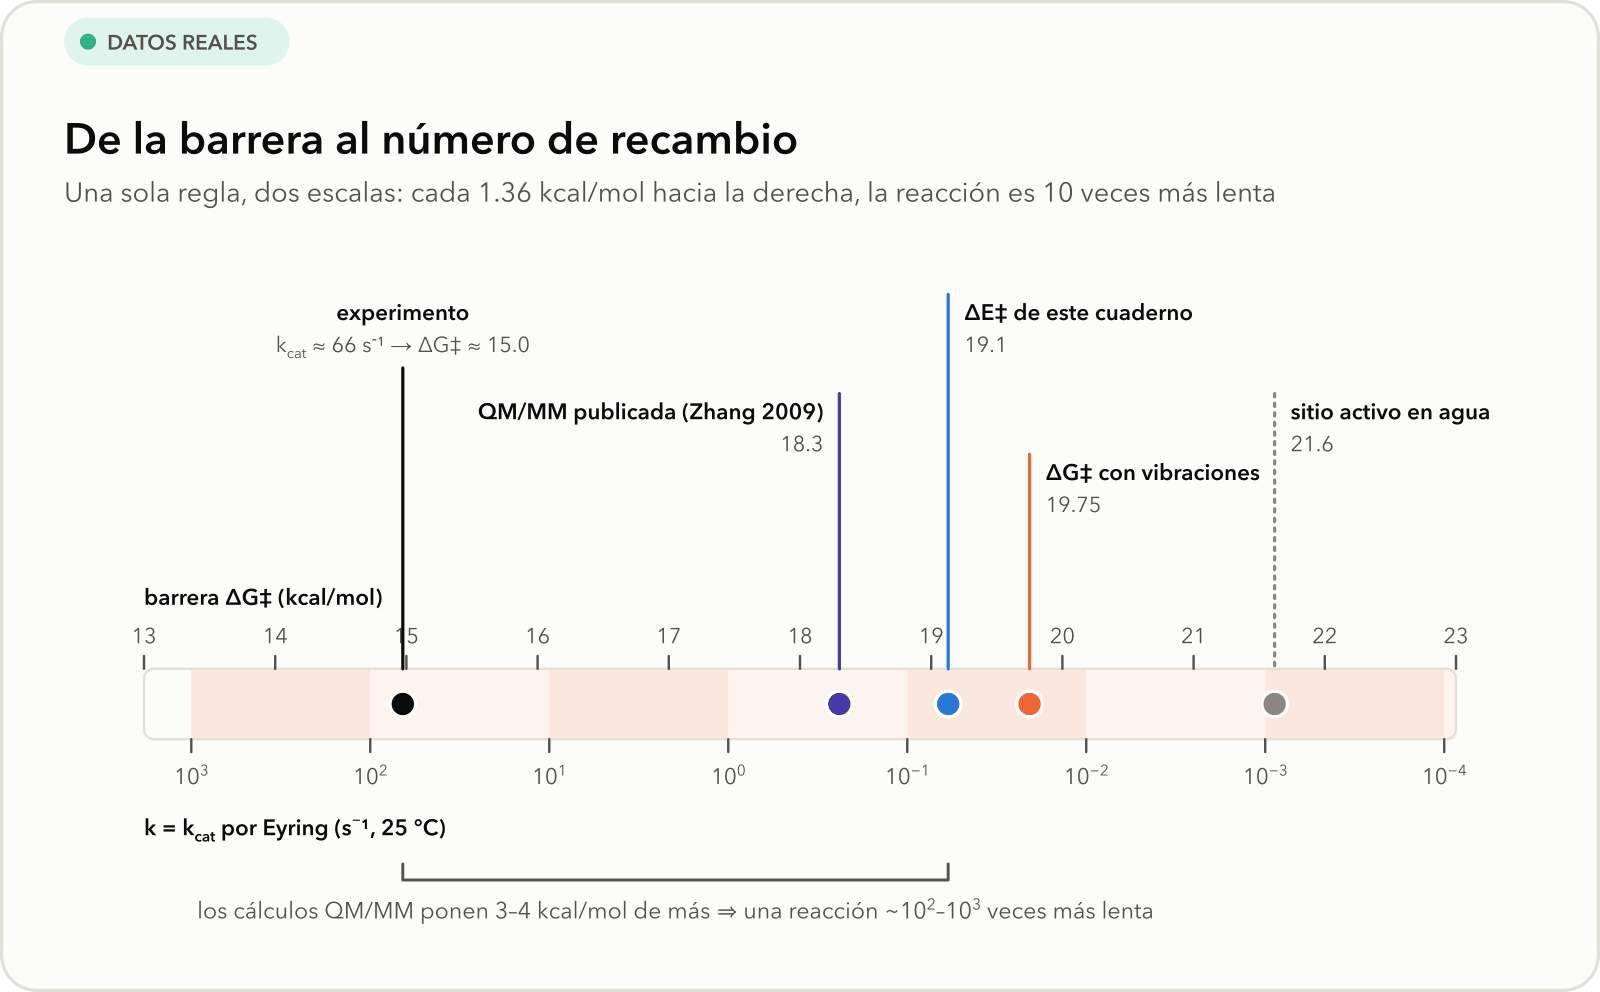

---

### 🧮 La ecuación en palabras

Es la misma ecuación de la sección 6, *intentos × probabilidad de éxito*, usada en los dos
sentidos:

* **de la simulación al experimento**: con la barrera calculada, ¿cuántas reacciones por segundo predice?
* **del experimento a la barrera**: con la k<sub>cat</sub> medida, ¿qué altura de colina implica?

---

### 📐 La ecuación completa, término a término

$$k_{\mathrm{cat}} \;=\; {\color{#2a78d6}{\frac{k_BT}{h}}}\;{\color{#eb6834}{e^{-\Delta G^{\ddagger}/RT}}}
\qquad\Longleftrightarrow\qquad
\Delta G^{\ddagger} \;=\; RT\,\ln\!\frac{k_BT}{h\,k_{\mathrm{cat}}}$$

| Término | Qué es | En la analogía | Valor |
|---|---|---|---|
| $k_{\mathrm{cat}}$ | reacciones por segundo por molécula de enzima | la escala de abajo | medida: ≈ 62–66 s⁻¹ |
| ${\color{#2a78d6}{k_BT/h}}$ | intentos por segundo | — | 6.2 × 10¹² s⁻¹ a 25 °C |
| ${\color{#eb6834}{\exp(-\Delta G^{\ddagger}/RT)}}$ | probabilidad de cruzar la cima | — | diminuta |
| $\Delta G^{\ddagger}$ | altura de la colina | la escala de arriba | experimento: ≈ 15 kcal/mol |

---

### 🎛️ Qué pasa si… (o por qué hay que ser honestos)

Nuestra ΔG‡ viene de un método semiempírico (PM7), de un entorno congelado y de una aproximación
armónica. Un error de 1.4 kcal/mol ya es un factor 10 en velocidad. Por eso comparamos órdenes de
magnitud y, sobre todo, *tendencias*, no decimales.

| Si la barrera calculada se equivoca en… | k<sub>cat</sub> se equivoca en un factor… |
|---|---|
| 0.5 kcal/mol | ~2 |
| 1.4 kcal/mol | ~10 |
| 4 kcal/mol | ~850 |

> ⚠️ **Ojo.** Una barrera calculada "casi igual" a la experimental puede dar una k<sub>cat</sub>
> diez o cien veces distinta. Compara siempre en la escala de la energía **y** en la de la
> velocidad.

---

### 🔬 Los datos reales

In [ ]:
# @title 🏁 Nuestra barrera frente al experimento
T = 298.15
kcat_exp = valor("kcat_s", 60.0)
dG_qmmm = termo.get(T_ref, {}).get("dG_kcal", ts["barrera_kcal"])
filas = [("ΔE‡ PM7, una conformación (este cuaderno)", ts["barrera_kcal"], viz.COLORS["reactivo"]),
         ("ΔG‡ PM7 + termoquímica armónica (este cuaderno)", dG_qmmm, viz.COLORS["ts"])]
try:
    if len(ok) > 1:
        filas.append(("ΔE‡ promedio sobre instantáneas de MD (este cuaderno)", media, viz.COLORS["reactivo"]))
except NameError:
    pass
filas.append(("ΔE‡ QM/MM publicada, Zhang et al. 2009", valor("qmmm_barrier_literature_kcal", np.nan), viz.PALETTE[6]))
filas.append(("sitio activo en agua, COSMO (este cuaderno)", agua["barrera_kcal"], viz.INK_MUTED))
dG_exp = cin.barrier_from_rate(kcat_exp, T)
etiquetas = {"ΔE‡ PM7, una conformación (este cuaderno)": "ΔE‡ en la enzima (PM7)",
             "ΔG‡ PM7 + termoquímica armónica (este cuaderno)": "ΔG‡ con vibraciones",
             "ΔE‡ promedio sobre instantáneas de MD (este cuaderno)": "ΔE‡ promedio (MD)",
             "ΔE‡ QM/MM publicada, Zhang et al. 2009": "Zhang et al. 2009 (QM/MM)",
             "sitio activo en agua, COSMO (este cuaderno)": "sitio activo en agua"}
fig = viz.plot_estimates([(etiquetas.get(n, n), b, c) for n, b, c in filas], reference=dG_exp,
                         reference_label=f"experimento (k_cat ≈ {kcat_exp:.0f} s⁻¹)", rate_fn=lambda b: cin.eyring_rate(b, T),
                         title="Los cálculos QM/MM quedan 3–4 kcal/mol por encima del experimento",
                         subtitle="Cada punto es una estimación de la barrera; a la derecha, la velocidad que implica la ecuación de Eyring")
filas.append(("experimento: ΔG‡ que implica k_cat", dG_exp, None))
tabla = pd.DataFrame([(n, b, viz._sci(cin.eyring_rate(b, T))) for n, b, _ in filas], columns=["estimación", "barrera (kcal/mol)", "k (s⁻¹) por Eyring"])
viz.mostrar(fig, viz.tabla(tabla, formatos={"barrera (kcal/mol)": "{:.1f}"}, titulo="Las mismas estimaciones, en números",
                           nota=f"k_cat experimental ≈ {kcat_exp:.0f} s⁻¹ ({ref['kcat_s']['source']})."),
            viz.mensaje("Nuestra barrera y la de Zhang et al. (18.3 kcal/mol, otro programa y otra partición QM/MM) coinciden dentro "
                        "de 1 kcal/mol; ambas sobrestiman la experimental (≈15) en 3-4 kcal/mol, es decir, un factor ~10²-10³ en k. "
                        "Es lo esperable de un método semiempírico con entorno fijo.", "idea"))

> ✅ **Para llevar.** Eyring traduce barreras en velocidades en los dos sentidos. Nuestra barrera
> y la de Zhang et al. coinciden entre sí dentro de 1 kcal/mol y quedan 3–4 kcal/mol por encima
> de la que implica el experimento (≈ 15): la simulación acierta el mecanismo y el orden de
> magnitud de la colina, no los decimales de *k*<sub>cat</sub>.

## 13. Michaelis–Menten desde el mecanismo

> 🎯 **En esta sección** verás por qué la velocidad de una enzima **se satura** cuando hay mucho
> sustrato, de dónde sale la ecuación de Michaelis–Menten (sin creerla: la derivaremos y la
> simularemos) y cómo se obtienen K<sub>M</sub>, V<sub>max</sub>, k<sub>cat</sub> y
> k<sub>cat</sub>/K<sub>M</sub> a partir de datos.

---

### 💡 La analogía: el cajero del supermercado

Una caja de supermercado (la **enzima**) atiende clientes (el **sustrato**). Con pocos clientes,
cada uno que llega es atendido enseguida: la "velocidad" de la caja crece con el número de
clientes. Con muchos clientes se forma cola: la caja trabaja a tope y da igual que lleguen más.
La velocidad se **satura**.

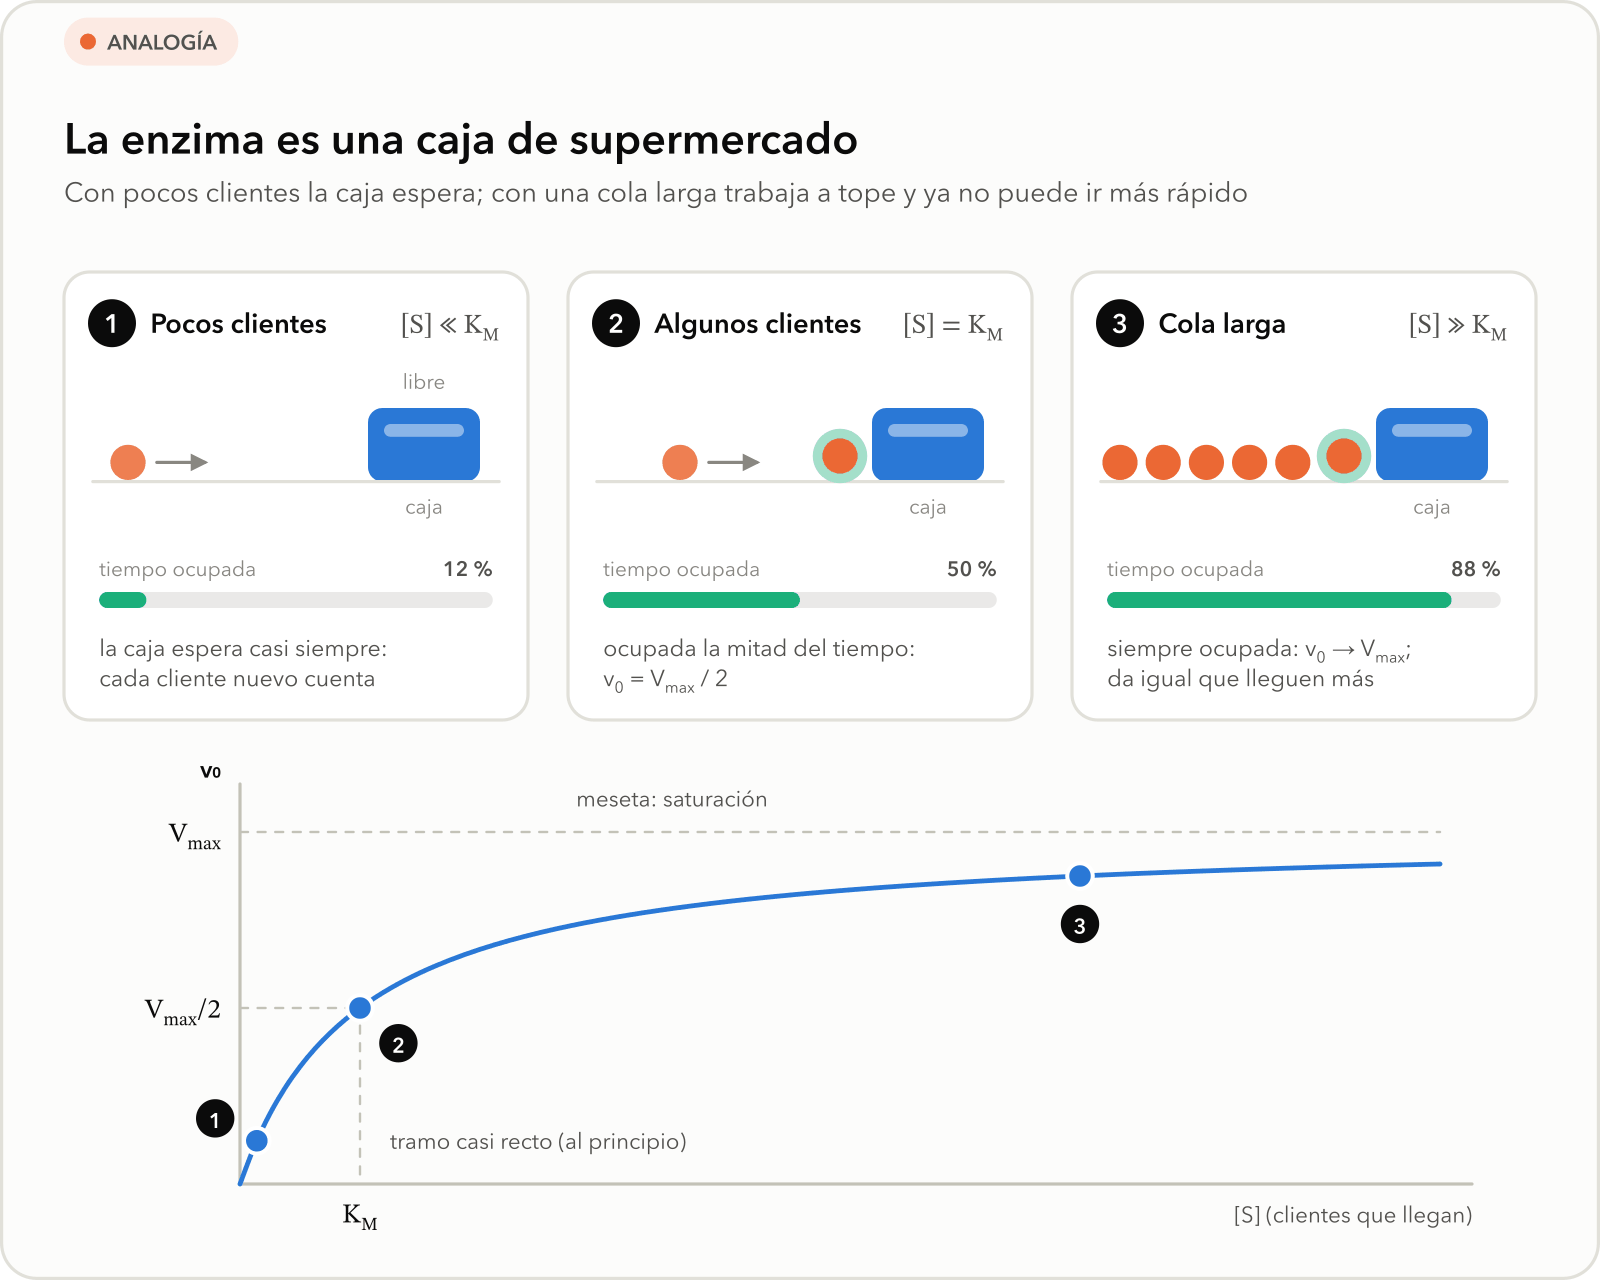

Ese comportamiento tiene forma de hipérbola y se describe con dos números:

* **V**<sub>max</sub>: la velocidad con la caja siempre ocupada (toda la enzima en forma ES).
* **K**<sub>M</sub>: la concentración de clientes a la que la caja trabaja a la **mitad** de su
  máximo. Una K<sub>M</sub> pequeña significa que la enzima "se llena" con poco sustrato.

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para predecir cuánto producto sale por segundo con cualquier
cantidad de sustrato, y para resumir una enzima entera en dos números que se pueden comparar entre
laboratorios, mutantes y fármacos.

La idea es sencilla: la velocidad es la **velocidad máxima** multiplicada por la **fracción del
tiempo que la caja está ocupada**:

$$\text{velocidad} \;=\; \underbrace{\text{velocidad con la caja siempre ocupada}}_{V_{\max}} \;\times\; \underbrace{\text{fracción de tiempo ocupada}}_{\text{de 0 a 1}}$$

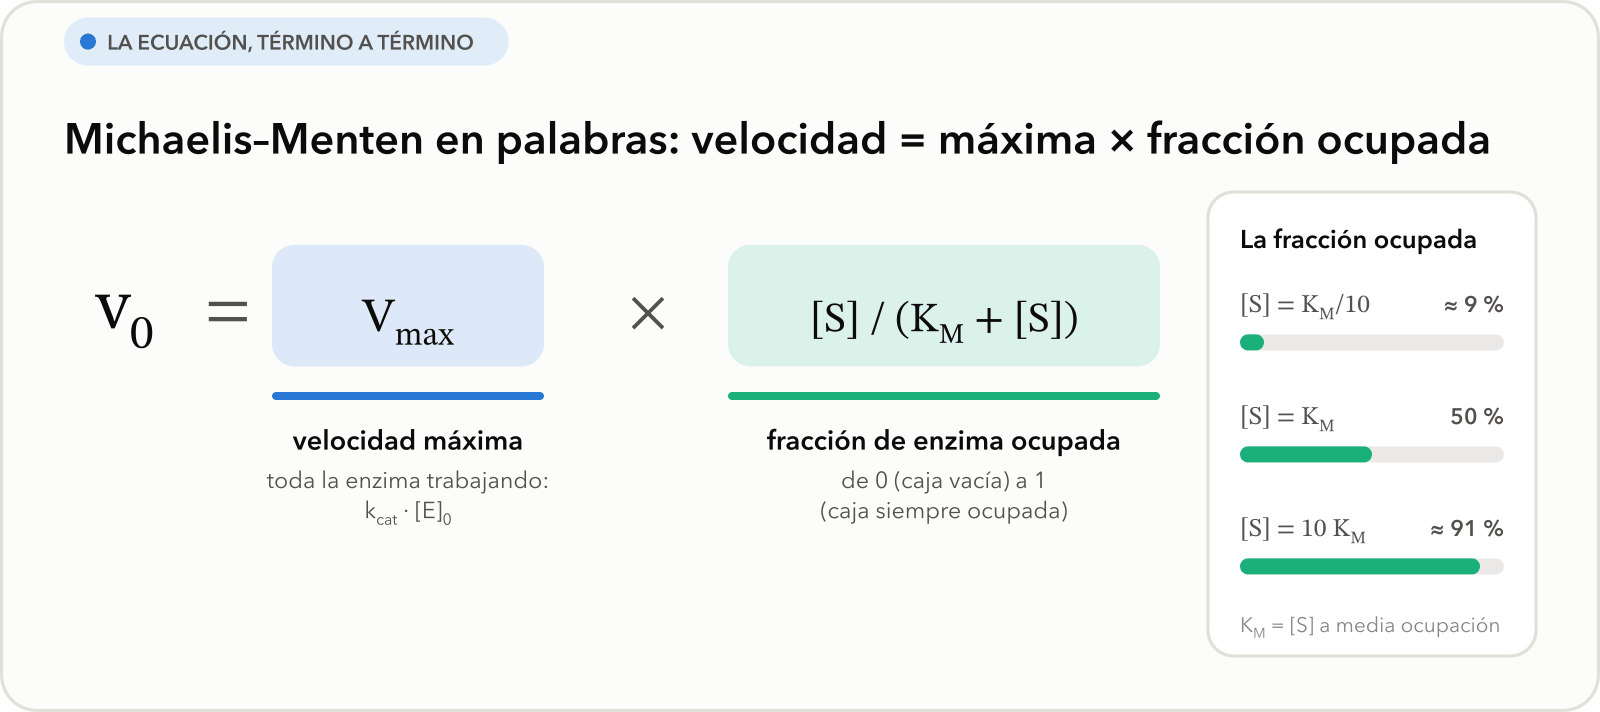

La fracción ocupada, $[\mathrm{S}]/(K_M + [\mathrm{S}])$, vale 0 sin sustrato, 1/2 cuando
$[\mathrm{S}] = K_M$ y se acerca a 1 (sin llegar nunca) cuando hay muchísimo. Eso es todo.

---

### 📐 La ecuación completa, término a término

**El mecanismo que hay detrás (Michaelis y Menten 1913; Briggs y Haldane 1925):**

$$\mathrm{E + S \;\underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}}\; ES \;\overset{k_2}{\longrightarrow}\; E + P}$$

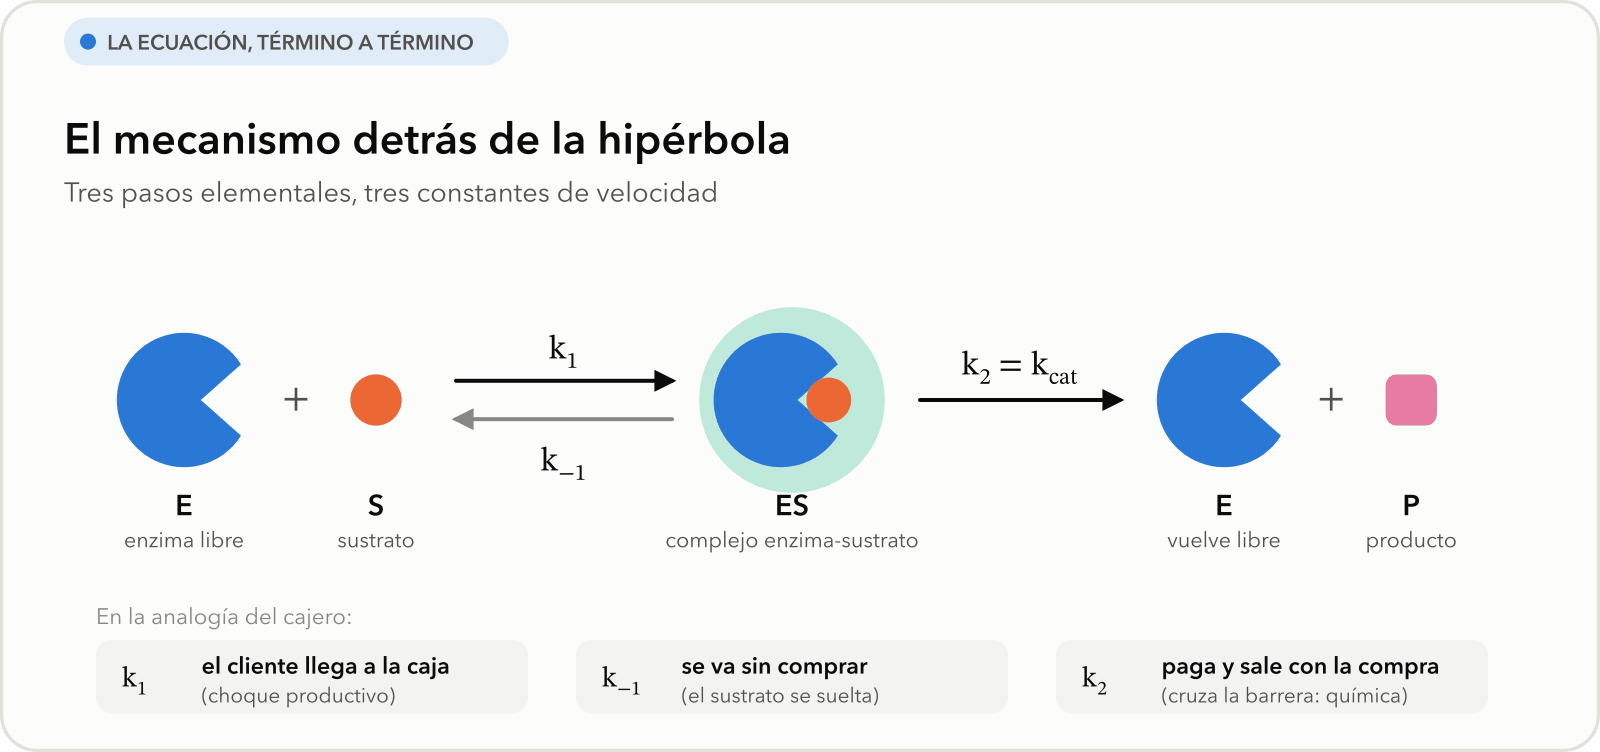

| Constante | Qué describe | En la analogía | Unidades |
|---|---|---|---|
| $k_1$ | el sustrato entra al sitio activo (choque productivo) | el cliente llega a la caja | M⁻¹ s⁻¹ |
| $k_{-1}$ | el sustrato se suelta sin reaccionar | se va sin comprar | s⁻¹ |
| $k_2$ (= k<sub>cat</sub>) | el complejo ES cruza la barrera y suelta el producto | paga y sale con su compra | s⁻¹ |

**La derivación, paso a paso.** (Sigue cada línea: solo es álgebra.)

1. Velocidad de formación de producto: $v_0 = k_2[\mathrm{ES}]$ — *cuántos clientes pagan por
   segundo = rapidez del cajero × clientes siendo atendidos*.
2. **Hipótesis del estado estacionario**: ES se forma tan rápido como se consume, así que su
   concentración casi no cambia: $k_1[\mathrm{E}][\mathrm{S}] = (k_{-1} + k_2)[\mathrm{ES}]$ — *llegan
   a la caja tantos clientes como se van (comprando o no)*.
3. La enzima total se reparte: $[\mathrm{E}]_0 = [\mathrm{E}] + [\mathrm{ES}]$, luego $[\mathrm{E}] = [\mathrm{E}]_0 - [\mathrm{ES}]$ —
   *cada caja está libre u ocupada*.
4. Sustituyendo (3) en (2) y despejando: $[\mathrm{ES}] = \dfrac{[\mathrm{E}]_0[\mathrm{S}]}{K_M + [\mathrm{S}]}$ con
   $K_M \equiv \dfrac{k_{-1}+k_2}{k_1}$.
5. Metiendo (4) en (1):

$$\boxed{v_0 \;=\; {\color{#2a78d6}{V_{\max}}}\;\times\;{\color{#1baf7a}{\frac{[\mathrm{S}]}{K_M + [\mathrm{S}]}}}} \qquad\text{con}\qquad {\color{#2a78d6}{V_{\max} = k_2[\mathrm{E}]_0}}$$

El factor **azul** es la velocidad máxima; el **verde**, la fracción de enzima ocupada (los mismos
colores que en el dibujo).

| Término | Qué es | En la analogía |
|---|---|---|
| $v_0$ | velocidad inicial de formación de producto | clientes que salen con su compra por segundo |
| ${\color{#2a78d6}{V_{\max}}}$ | velocidad con toda la enzima ocupada: k<sub>cat</sub>·[E]<sub>0</sub> | todas las cajas atendiendo sin pausa |
| [S] | concentración de sustrato | cuántos clientes hay en la tienda |
| $K_M$ | [S] a la que la enzima está medio ocupada: (k<sub>−1</sub> + k<sub>2</sub>)/k<sub>1</sub> | cuántos clientes hacen falta para que la caja esté ocupada la mitad del tiempo |

> ⚠️ **Ojo.** $K_M$ solo es igual a la constante de disociación $K_d = k_{-1}/k_1$ cuando
> $k_2 \ll k_{-1}$ (el cliente se va sin comprar muchas más veces de las que compra). En general
> K<sub>M</sub> no es una "afinidad" pura.

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| [S] ≪ K<sub>M</sub> | v₀ ≈ (V<sub>max</sub>/K<sub>M</sub>)·[S]: **una recta** | la enzima está casi vacía y cada molécula de sustrato cuenta; pendiente = (k<sub>cat</sub>/K<sub>M</sub>)·[E]<sub>0</sub> |
| [S] = K<sub>M</sub> | v₀ = V<sub>max</sub>/2 | la caja está ocupada la mitad del tiempo |
| [S] ≫ K<sub>M</sub> | v₀ → V<sub>max</sub>: **saturación** | siempre hay cola: más clientes no aceleran al cajero |
| **K<sub>M</sub> sube** | la curva se estira a la derecha | la enzima "agarra" peor el sustrato o lo suelta más rápido: hace falta más para la misma velocidad |
| **V<sub>max</sub> sube** | toda la curva escala hacia arriba | más enzima, o una enzima más rápida |

---

### 🔬 Simulemos el mecanismo

En lugar de creer la fórmula, **resolvamos el mecanismo numéricamente** y veamos cómo la
hipérbola aparece sola. Primero la película de las concentraciones:

In [ ]:
# @title 🎛️ El mecanismo en acción: E + S ⇌ ES → E + P
# 🎛️ Mueve k1, k-1, k2, [E]0 y [S]0 y observa el pre-estado estacionario y la formación de producto
interactivo.explorar_mecanismo()

In [ ]:
# @title 🔁 De la simulación a la hipérbola
k2 = 60  # @param {type:"slider", min:6, max:600, step:6}
# k2 = k_cat (s⁻¹); prueba 6 y 600 (ejercicio 3)
E0, k1, k_1 = 0.05, 1.0, 50.0                   # µM, µM⁻¹s⁻¹, s⁻¹
S = np.array([5, 10, 20, 40, 80, 150, 300, 600, 1200, 2400])       # µM
v0_sim = cin.initial_rates_from_simulation(E0, S, k1, k_1, k2, t_window=(0.01, 0.1))
ajuste = cin.fit_michaelis_menten(S, v0_sim)
teoria = cin.steady_state_parameters(k1, k_1, k2)
fig = viz.plot_initial_rates_from_ode(S, v0_sim, fit=ajuste)
v0_mm = cin.michaelis_menten(S, ajuste["vmax"], ajuste["km"])
tabla_sim = pd.DataFrame({"[S]₀": S, "v₀ simulada": v0_sim, "v₀ de la hipérbola": v0_mm,
                          "diferencia": v0_sim - v0_mm, "fracción ocupada": S / (ajuste["km"] + S)})
datos_sim = viz.datos(
    tabla_sim, "de la simulación a la hipérbola",
    "Cada fila es una simulación completa del mecanismo con una [S]₀ distinta: v₀ es la pendiente inicial de la "
    "curva de producto. La línea de la gráfica es la hipérbola que mejor pasa por estos puntos.",
    x="[S]₀", y="v₀ simulada",
    calculadas={"v₀ de la hipérbola": "V_max·[S]₀ / (K_M + [S]₀), con V_max y K_M del ajuste",
                "diferencia": "v₀ simulada − v₀ de la hipérbola",
                "fracción ocupada": "[S]₀ / (K_M + [S]₀)"},
    unidades={"[S]₀": "µM", "v₀ simulada": "µM/s", "v₀ de la hipérbola": "µM/s", "diferencia": "µM/s"},
    formatos={"[S]₀": "{:g}", "v₀ simulada": "{:.4f}", "v₀ de la hipérbola": "{:.4f}", "diferencia": "{:+.1e}",
              "fracción ocupada": "{:.0%}"},
    resaltar={int(np.argmin(np.abs(S - ajuste["km"]))): ("≈ K_M", "naranja")}, barra="v₀ simulada")
viz.mostrar(fig, datos_sim, viz.tarjetas([
    ("K_M del ajuste", f"{ajuste['km']:.1f}", "µM", "ajustando la hipérbola a las v₀ simuladas", "azul"),
    ("K_M de la fórmula", f"{teoria['km']:.1f}", "µM", "(k₋₁ + k₂)/k₁", "agua"),
    ("V_max del ajuste", f"{ajuste['vmax']:.3f}", "µM/s", "meseta de la curva", "azul"),
    ("V_max de la fórmula", f"{k2 * E0:.3f}", "µM/s", "k₂·[E]₀", "agua"),
], titulo="¿Coinciden la simulación y la derivación en papel?",
   nota="Si las parejas coinciden, la derivación funciona: la hipérbola sale sola del mecanismo."))

In [ ]:
# @title 🎛️ La hipérbola: mueve V_max y K_M
# 🎛️ La hipérbola: mueve Vmax y Km
interactivo.explorar_michaelis_menten()

### 🔬 Los datos reales: tres números que salen de la curva

| Constante | Cómo se obtiene | Qué mide | En la analogía | Glucoquinasa (literatura) |
|---|---|---|---|---|
| **K<sub>M</sub>** (o S<sub>0.5</sub>) | ajuste de v₀ frente a [S] | afinidad aparente; a qué [S] la enzima está medio llena | clientes necesarios para media ocupación | ≈ 7.7 mM de glucosa |
| **k<sub>cat</sub>** = V<sub>max</sub>/[E]<sub>0</sub> | V<sub>max</sub> del ajuste ÷ concentración de enzima | recambio: reacciones por segundo por molécula de enzima | clientes por segundo que despacha **una** caja a tope | ≈ 62–66 s⁻¹ |
| **k<sub>cat</sub>/K<sub>M</sub>** | cociente de los dos anteriores | eficiencia a baja [S]; tope físico ≈ 10⁸–10⁹ M⁻¹s⁻¹ (difusión) | lo bien que la caja aprovecha una tienda casi vacía | ≈ 8 × 10³ M⁻¹s⁻¹ |

Ahora un "experimento": datos simulados con los parámetros de la literatura y un 4 % de ruido,
tratados como lo haría un bioquímico: **ajuste no lineal** y, para comparar, las tres
linealizaciones clásicas.

> ⚠️ **Ojo.** **Lineweaver–Burk** (1/v₀ frente a 1/[S]) amplifica el error de los puntos a baja
> concentración: hoy se usa para *visualizar*, y el ajuste no lineal para *cuantificar*.

In [ ]:
# @title 🔬 Un experimento simulado y su ajuste
rng = np.random.default_rng(7)
S_mM = np.array([0.5, 1, 2, 3, 5, 7.5, 10, 15, 20, 30, 40, 60])
E0_uM = 0.2                                     # enzima en el tubo (µM)
Km_real = valor("s_half_mm", 7.5)               # tratamos la enzima como hiperbólica en este ejercicio
Vmax_real = valor("kcat_s", 60.0) * E0_uM       # µM/s
v_obs = cin.michaelis_menten(S_mM, Vmax_real, Km_real) * (1 + 0.04 * rng.standard_normal(S_mM.size))
aj = cin.fit_michaelis_menten(S_mM, v_obs)
fig = viz.plot_michaelis_menten(S_mM, v_obs, fit=aj, title=f"La enzima llega a la mitad de su máximo con {aj['km']:.1f} mM de sustrato",
                                subtitle="Datos simulados con ruido del 4 % (puntos) y ajuste no lineal de Michaelis–Menten (línea)")
kc = cin.kcat_km_from_fit(aj, E0_uM)
v_ajuste = cin.michaelis_menten(S_mM, aj["vmax"], aj["km"])
tabla_exp = pd.DataFrame({"[S]": S_mM, "v₀ medida": v_obs, "v₀ del ajuste": v_ajuste, "residuo": v_obs - v_ajuste,
                          "fracción ocupada": S_mM / (aj["km"] + S_mM)})
datos_exp = viz.datos(
    tabla_exp, "el experimento simulado",
    "Cada fila es un tubo de ensayo: una concentración de glucosa y la velocidad inicial medida (con un 4 % de ruido). "
    "El ajuste no lineal busca los V_max y K_M que hacen más pequeños los residuos.",
    x="[S]", y="v₀ medida",
    calculadas={"v₀ del ajuste": "V_max·[S] / (K_M + [S]), con V_max y K_M del ajuste",
                "residuo": "v₀ medida − v₀ del ajuste (lo que la curva no explica: el ruido)",
                "fracción ocupada": "[S] / (K_M + [S]) = v₀ del ajuste / V_max"},
    unidades={"[S]": "mM", "v₀ medida": "µM/s", "v₀ del ajuste": "µM/s", "residuo": "µM/s"},
    formatos={"[S]": "{:g}", "v₀ medida": "{:.2f}", "v₀ del ajuste": "{:.2f}", "residuo": "{:+.2f}", "fracción ocupada": "{:.0%}"},
    resaltar={int(np.argmin(np.abs(S_mM - aj["km"]))): ("≈ K_M", "naranja")}, barra="v₀ medida")
viz.mostrar(fig, datos_exp, viz.tarjetas([
    ("V_max", f"{aj['vmax']:.2f}", f"± {aj['vmax_err']:.2f} µM/s", "la meseta: toda la enzima ocupada", "azul"),
    ("K_M", f"{aj['km']:.2f}", f"± {aj['km_err']:.2f} mM", f"[S] a media velocidad (R² = {aj['r2']:.4f})", "naranja"),
    ("k_cat = V_max/[E]₀", f"{kc['kcat']:.0f}", "s⁻¹", f"una reacción cada {cin.turnover_time(kc['kcat'])*1000:.0f} ms por enzima", "agua"),
    ("k_cat/K_M", f"{kc['kcat_over_km_molar']:.2e}", "M⁻¹s⁻¹", "eficiencia cuando hay poco sustrato", "violeta"),
], titulo="Los cuatro números que salen de la curva"))

In [ ]:
# @title 📐 Las tres linealizaciones clásicas
fig = viz.plot_linearizations(S_mM, v_obs, title="Tres maneras de convertir la hipérbola en una recta",
                              subtitle="Los cortes con los ejes (puntos grises) dan V_max y K_M; círculos naranjas: los puntos que más distorsionan Lineweaver–Burk")
lb = cin.linear_fit(*cin.lineweaver_burk(S_mM, v_obs))
tabla_lin = pd.DataFrame({"[S]": S_mM, "v₀": v_obs, "1/[S]": 1 / S_mM, "1/v₀": 1 / v_obs,
                          "v₀/[S]": v_obs / S_mM, "[S]/v₀": S_mM / v_obs})
datos_lin = viz.datos(
    tabla_lin, "las tres linealizaciones",
    "Los mismos 12 tubos, transformados. Cada gráfico usa un par de columnas: Lineweaver–Burk dibuja 1/v₀ frente a "
    "1/[S]; Eadie–Hofstee, v₀ frente a v₀/[S]; Hanes–Woolf, [S]/v₀ frente a [S]. Fíjate en las dos primeras filas: "
    "con poca glucosa, 1/[S] y 1/v₀ se disparan y esos puntos, los más ruidosos, dominan la recta de Lineweaver–Burk.",
    calculadas={"1/[S]": "1 ÷ [S]  (eje x de Lineweaver–Burk)", "1/v₀": "1 ÷ v₀  (eje y de Lineweaver–Burk)",
                "v₀/[S]": "v₀ ÷ [S]  (eje x de Eadie–Hofstee; su eje y es v₀)",
                "[S]/v₀": "[S] ÷ v₀  (eje y de Hanes–Woolf; su eje x es [S])"},
    unidades={"[S]": "mM", "v₀": "µM/s", "1/[S]": "mM⁻¹", "1/v₀": "s/µM", "v₀/[S]": "µM·s⁻¹/mM", "[S]/v₀": "mM·s/µM"},
    formatos={"[S]": "{:g}", "v₀": "{:.2f}", "1/[S]": "{:.3f}", "1/v₀": "{:.3f}", "v₀/[S]": "{:.3f}", "[S]/v₀": "{:.3f}"},
    resaltar={0: ("pesa mucho en L‑B", "naranja"), 1: ("pesa mucho en L‑B", "naranja")}, barra="1/v₀")
viz.mostrar(fig, datos_lin, viz.tarjetas([
    ("V_max por Lineweaver–Burk", f"{1/lb['intercept']:.2f}", "µM/s", f"ajuste no lineal: {aj['vmax']:.2f}", "gris"),
    ("K_M por Lineweaver–Burk", f"{lb['slope']/lb['intercept']:.2f}", "mM", f"ajuste no lineal: {aj['km']:.2f}", "gris"),
], titulo="Lineweaver–Burk frente al ajuste no lineal",
   nota="Las rectas sirven para visualizar el tipo de comportamiento; para cuantificar se usa el ajuste no lineal."))

> ✅ **Para llevar.** Velocidad = velocidad máxima × fracción de enzima ocupada. La hipérbola
> **emerge** del mecanismo E + S ⇌ ES → E + P; K<sub>M</sub> es la [S] de media ocupación,
> k<sub>cat</sub> las reacciones por segundo de cada enzima y k<sub>cat</sub>/K<sub>M</sub> su
> eficiencia cuando el sustrato escasea. Se miden con un ajuste no lineal.

## 14. Cooperatividad: la glucoquinasa es un sensor

> 🎯 **En esta sección** verás por qué la curva de la glucoquinasa no es una hipérbola sino una
> **sigmoide**, qué mide el coeficiente de Hill *n* y cómo una enzima con **un solo sitio** puede
> comportarse como un interruptor que decide cuándo el páncreas libera insulina.

---

### 💡 La analogía: regulador de luz frente a interruptor

Un **regulador de luz** (hipérbola) sube la intensidad poco a poco desde el principio. Un
**interruptor con umbral** (sigmoide) casi no hace nada hasta cierto punto y entonces se enciende
de golpe. El páncreas necesita un interruptor: por debajo de ~5 mM de glucosa no debe soltar
insulina, y por encima sí. La glucoquinasa es ese interruptor.

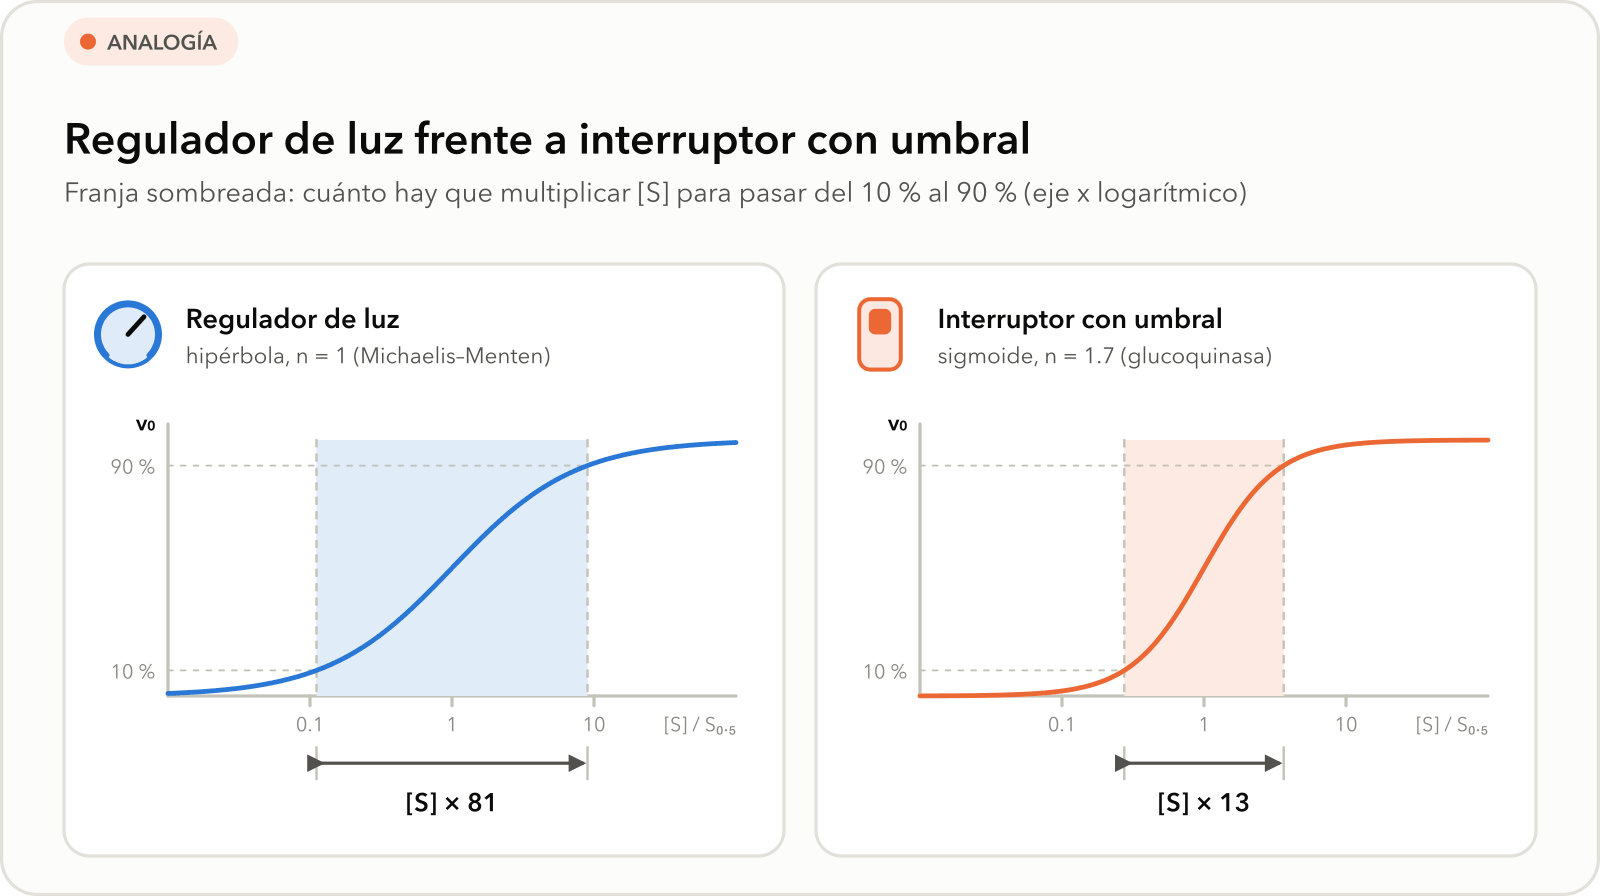

Mira las franjas sombreadas: para pasar del 10 % al 90 % de la actividad, la hipérbola necesita
multiplicar la glucosa **por 81**; la sigmoide de la glucoquinasa, solo **por 13**.

---

### 🧮 La ecuación en palabras

**¿Para qué queremos otra ecuación?** Porque Michaelis–Menten solo sabe dibujar hipérbolas y los
datos de la glucoquinasa no lo son. Necesitamos un número que diga **cuán abrupto** es el
interruptor.

La idea es la misma de la sección 13 (velocidad = máxima × fracción ocupada), pero la
concentración de sustrato entra **elevada a una potencia n**:

$$\text{velocidad} \;=\; V_{\max} \times \frac{(\text{sustrato})^{\,n}}{(\text{umbral})^{\,n} + (\text{sustrato})^{\,n}}$$

Elevar a *n* > 1 hace que las concentraciones **por debajo** del umbral cuenten todavía menos y las
de **por encima** cuenten todavía más: la curva se aplana al principio y se empina en el centro.
Es el interruptor.

---

### 📐 La ecuación completa, término a término (Hill)

$$v_0 = \frac{V_{\max}[\mathrm{S}]^{\color{#eb6834}{n}}}{{\color{#2a78d6}{S_{0.5}}}^{\,\color{#eb6834}{n}} + [\mathrm{S}]^{\color{#eb6834}{n}}}$$

| Término | Qué es | En la analogía | Glucoquinasa |
|---|---|---|---|
| $V_{\max}$ | velocidad máxima | la luz a tope | k<sub>cat</sub>·[E]<sub>0</sub> |
| ${\color{#2a78d6}{S_{0.5}}}$ | concentración a la que se alcanza la mitad de V<sub>max</sub> (el análogo de K<sub>M</sub>) | dónde está el umbral del interruptor | ≈ 7.7 mM de glucosa |
| ${\color{#eb6834}{n}}$ | **coeficiente de Hill**: cuán abrupto es el cambio | cuán "de golpe" se enciende la luz | ≈ 1.7 |

$n = 1$ es Michaelis–Menten; $n > 1$ es cooperatividad positiva.

---

### 🎛️ Qué pasa si…

| Si… | para pasar del 10 % al 90 % de la actividad hay que multiplicar [S] por… | ejemplo |
|---|---|---|
| n = 1 | **81** | una enzima michaeliana |
| n = 1.7 | **~13** | la glucoquinasa |
| n = 4 | **3** | la hemoglobina |

---

### 💡 Lo sorprendente: una enzima con memoria

La glucoquinasa es un **monómero** con un solo sitio para glucosa: no puede haber "comunicación
entre subunidades" como en la hemoglobina. Su cooperatividad es **cinética**: la enzima cambia
entre una forma poco activa (abierta) y una activa (cerrada) a una velocidad **comparable a la de
la catálisis** (k<sub>ex</sub> ≈ 5–100 s⁻¹ frente a k<sub>cat</sub> ≈ 60 s⁻¹, Larion et al. 2012).

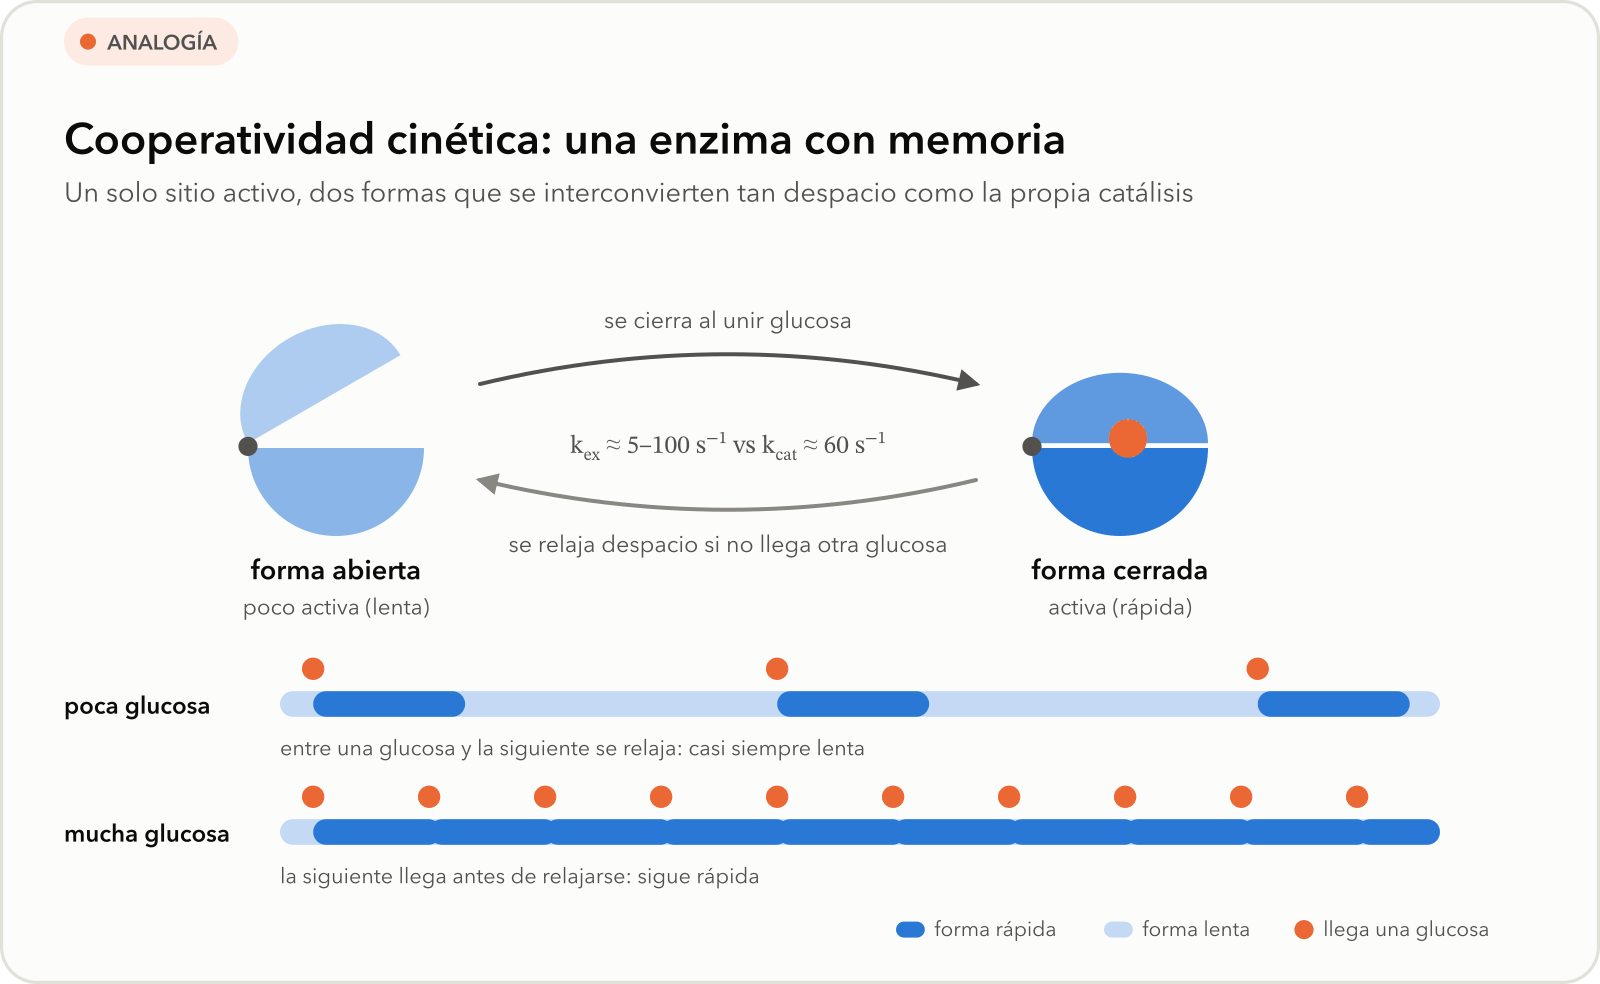

Con mucha glucosa la enzima no tiene tiempo de relajarse a la forma lenta entre un ciclo y el
siguiente, y trabaja más de lo que "debería". Es el modelo **mnemónico** o de **transición lenta**
(Storer y Cornish‑Bowden 1977; Neet y Ainslie; Cárdenas 1984).

> ✍️ **Para pensar.** Un inhibidor competitivo como la N‑acetilglucosamina *suprime* la
> cooperatividad (n → 1), porque mantiene ocupado el sitio y rompe la "memoria". Las simulaciones
> de MD de la sección 5 (dominios que se abren y cierran) son la imagen molecular de ese cambio.

---

### 🔬 Los datos reales

Mueve *n* y S<sub>0.5</sub>, y compara con la hipérbola:

In [ ]:
# @title 🎛️ Sigmoide frente a hipérbola
# 🎛️ Mueve n y S0.5: compara con la hipérbola y mira la ventana 10 %–90 %
interactivo.explorar_hill()

In [ ]:
# @title 🩸 La glucoquinasa en el rango de glucosa de la sangre
S_g = np.linspace(0.01, 30, 300)
s_half, n_h = valor("s_half_mm", 7.5), valor("hill_n", 1.7)
fig = viz.plot_hill_vs_mm(S_g, cin.michaelis_menten(S_g, 1.0, s_half), cin.hill(S_g, 1.0, s_half, n_h), n_hill=n_h, s_half=s_half,
                          ylabel="v₀ / V_max", title="En el rango de la sangre, la glucoquinasa responde como un interruptor",
                          subtitle="Entre 4 y 10 mM de glucosa (el rango fisiológico) la sigmoide es mucho más sensible que la hipérbola")
fig.set_size_inches(10.5, 5.8)
ax = fig.axes[0]
viz._kband(ax, 4, 7, "glucosa en sangre\nen ayunas (4–7 mM)", color=viz._tint(viz.COLORS["ts"], 0.9), y_text=0.97)
s10, s90 = cin.substrate_at_fraction(1.0, s_half, n_h, 0.1), cin.substrate_at_fraction(1.0, s_half, n_h, 0.9)
S_tab = np.array(sorted({1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 30, round(s_half, 2)}), dtype=float)
mm_tab, hill_tab = cin.michaelis_menten(S_tab, 1.0, s_half), cin.hill(S_tab, 1.0, s_half, n_h)
tabla_hill = pd.DataFrame({"[glucosa]": S_tab, "[S]/S₀.₅": S_tab / s_half, "hipérbola (n = 1)": mm_tab,
                           f"sigmoide (n = {n_h:g})": hill_tab, "diferencia": hill_tab - mm_tab})
resalte = {int(np.argmin(np.abs(S_tab - s_half))): ("S₀.₅", "naranja")}
resalte.update({i: ("ayuno", "agua") for i, sv in enumerate(S_tab) if 4 <= sv <= 7 and i not in resalte})
datos_hill = viz.datos(
    tabla_hill, "sigmoide frente a hipérbola",
    "Las dos curvas evaluadas en concentraciones redondas de glucosa, como fracción de V_max. Con poca glucosa la "
    "sigmoide va por debajo (la enzima casi no responde); cerca de S₀.₅ se cruzan; por encima, la sigmoide sube más rápido.",
    x="[glucosa]", y=["hipérbola (n = 1)", f"sigmoide (n = {n_h:g})"],
    calculadas={"[S]/S₀.₅": "[glucosa] ÷ S₀.₅",
                "hipérbola (n = 1)": "[S] / (S₀.₅ + [S])  (Michaelis–Menten con K_M = S₀.₅)",
                f"sigmoide (n = {n_h:g})": "[S]ⁿ / (S₀.₅ⁿ + [S]ⁿ)  (Hill)",
                "diferencia": "sigmoide − hipérbola"},
    unidades={"[glucosa]": "mM", "hipérbola (n = 1)": "v₀/V_max", f"sigmoide (n = {n_h:g})": "v₀/V_max", "diferencia": "v₀/V_max"},
    formatos={"[glucosa]": "{:g}", "[S]/S₀.₅": "{:.2f}", "hipérbola (n = 1)": "{:.0%}", f"sigmoide (n = {n_h:g})": "{:.0%}",
              "diferencia": "{:+.0%}"},
    resaltar=resalte, barra=f"sigmoide (n = {n_h:g})")
viz.mostrar(fig, datos_hill, viz.tarjetas([
    ("S₀.₅", f"{s_half:g}", "mM", "glucosa a media actividad", "naranja"),
    ("coeficiente de Hill", f"{n_h:g}", "", "n > 1: sigmoide", "naranja"),
    ("del 10 % al 90 %", f"{s10:.1f} → {s90:.1f}", "mM", f"[S] × {s90/s10:.0f}", "naranja"),
    ("con n = 1", "× 81", "", "la hipérbola necesitaría mucho más", "azul"),
], titulo="El interruptor de la glucoquinasa en números"))

In [ ]:
# @title 📐 Ajuste de Hill y gráfico de Hill
# Ajuste de Hill a datos simulados y gráfico de Hill (la pendiente es n)
S_h = np.array([1, 2, 3, 4, 5, 6, 7.5, 9, 11, 14, 18, 25, 35, 50])
v_h = cin.hill(S_h, 10.0, s_half, n_h) * (1 + 0.03 * rng.standard_normal(S_h.size))
ajh = cin.fit_hill(S_h, v_h)
fig = viz.plot_hill_plot(S_h, v_h, ajh["vmax"], title=f"Los datos suben más empinados que la referencia: n = {ajh['n']:.2f}",
                         subtitle="log[v/(V_max − v)] frente a log[S]: la pendiente es el coeficiente de Hill; la línea discontinua es n = 1")
frac = v_h / (ajh["vmax"] - v_h)
tabla_hp = pd.DataFrame({"[S]": S_h, "v₀": v_h, "log₁₀[S]": np.log10(S_h), "v₀/(V_max − v₀)": frac,
                         "log₁₀[v₀/(V_max − v₀)]": np.log10(frac)})
datos_hp = viz.datos(
    tabla_hp, "el gráfico de Hill",
    "Los 14 tubos del experimento simulado. Para el gráfico de Hill se transforman las dos columnas: el eje x es "
    "log₁₀[S] y el eje y es log₁₀[v₀/(V_max − v₀)], con el V_max del ajuste. Si la enzima sigue la ecuación de Hill, "
    "los puntos caen en una recta de pendiente n; cruzan el 0 del eje y justo en [S] = S₀.₅ (mitad ocupada).",
    x="log₁₀[S]", y="log₁₀[v₀/(V_max − v₀)]",
    calculadas={"log₁₀[S]": "logaritmo decimal de [S]",
                "v₀/(V_max − v₀)": "enzima «encendida» ÷ enzima «apagada»",
                "log₁₀[v₀/(V_max − v₀)]": "logaritmo de la columna anterior (= n·log[S] − n·log S₀.₅)"},
    unidades={"[S]": "mM", "v₀": "µM/s"},
    formatos={"[S]": "{:g}", "v₀": "{:.2f}", "log₁₀[S]": "{:.3f}", "v₀/(V_max − v₀)": "{:.3f}", "log₁₀[v₀/(V_max − v₀)]": "{:+.3f}"},
    resaltar={int(np.argmin(np.abs(np.log10(frac)))): ("≈ S₀.₅", "naranja")})
viz.mostrar(fig, datos_hp, viz.tarjetas([
    ("V_max", f"{ajh['vmax']:.2f}", "", "meseta del ajuste", "azul"),
    ("S₀.₅", f"{ajh['s_half']:.2f}", "mM", "glucosa a media actividad", "naranja"),
    ("n (Hill)", f"{ajh['n']:.2f}", f"± {ajh['n_err']:.2f}", "n > 1: cooperatividad positiva", "naranja"),
], titulo="Ajuste de Hill a datos simulados con 3 % de ruido"))

### 🔬 Mutaciones que mueven el interruptor: GCK‑MODY e hiperinsulinismo

Una mutación que sube S<sub>0.5</sub> (o baja k<sub>cat</sub>) hace que el páncreas "vea" menos
glucosa de la que hay y libere insulina tarde: glucemia alta desde el nacimiento, pero estable
(GCK‑MODY). Una mutación activadora baja S<sub>0.5</sub>: insulina de más, hipoglucemia congénita.
En la analogía: el interruptor se desplaza a la derecha o a la izquierda. Con los valores publicados
(Valentínová 2012; Sayed 2009) dibujamos qué hace cada mutante a 5 mM de glucosa:

In [ ]:
# @title 🧬 Mutantes GCK‑MODY: el interruptor se desplaza
mut = ref.get("mutants", [])
if mut:
    S_g = np.linspace(0.01, 30, 300)
    elegidos = [m for m in mut if m["name"] in ("V244G", "G223S", "I110N", "W99L", "M197I")]
    curvas = [("silvestre", s_half, n_h, 1.0)] + [(m["name"], m["s_half_mm"], m.get("hill_n", n_h), m.get("kcat_rel", 1.0)) for m in elegidos]
    fig, ax = viz.figure(11.5, 6.4)
    viz._kband(ax, 4, 7, color=viz._tint(viz.COLORS["ts"], 0.9))
    etiquetas = []
    for (nombre, s05, nn, krel), color in zip(curvas, [viz.INK] + list(viz.PALETTE[: len(elegidos)])):
        y = krel * cin.hill(S_g, 1.0, s05, nn)
        ax.plot(S_g, y, color=color, lw=3.2 if nombre == "silvestre" else 2.4, zorder=4 if nombre == "silvestre" else 3,
                label=f"{nombre}: S₀.₅ = {s05:g} mM, k_cat ×{krel:.2f}")
        y5 = krel * cin.hill(5.0, 1.0, s05, nn)
        ax.plot([5.0], [y5], "o", ms=8, mfc=color, mec="white", mew=1.6, zorder=6)
        etiquetas.append([y[-1], nombre])
    # etiquetas directas al final de cada curva, separadas para que no se pisen
    etiquetas.sort()
    y_max = max(e[0] for e in etiquetas)
    for j in range(1, len(etiquetas)):
        etiquetas[j][0] = max(etiquetas[j][0], etiquetas[j - 1][0] + 0.06 * y_max)
    for y_lab, nombre in etiquetas:
        ax.annotate(nombre, (S_g[-1], y_lab), xytext=(6, 0), textcoords="offset points", ha="left", va="center",
                    fontsize=10.5, color=viz.INK, fontweight="semibold" if nombre == "silvestre" else "normal",
                    annotation_clip=False)
    viz._guide(ax, "v", 5.0, color=viz.INK_SECONDARY)
    ax.annotate("5 mM (franja: glucosa en ayunas, 4–7 mM)\ncada punto: la actividad con la que\nel páncreas «ve» la glucosa", (5.0, 0.0), xytext=(96, 14),
                textcoords="offset points", ha="left", va="bottom", fontsize=10.5, color=viz.INK_SECONDARY)
    ax.set_xlim(0, 30); ax.set_ylim(bottom=0)
    viz._finish(ax, "[glucosa] (mM)", "actividad relativa a V_max silvestre",
                "Cada mutación desplaza el interruptor de la insulina",
                "Curvas de Hill con los valores publicados: a la derecha o más abajo = el páncreas «ve» menos glucosa (GCK‑MODY)")
    ax.legend(fontsize=10, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False)
    tabla = pd.DataFrame([(m["name"], m["kind"], m["s_half_mm"], m.get("hill_n"), m.get("kcat_s"),
                           round(m.get("kcat_rel", 1.0) * cin.hill(5.0, 1.0, m["s_half_mm"], m.get("hill_n", n_h)), 3)) for m in mut],
                         columns=["mutante", "fenotipo", "S₀.₅ (mM)", "n", "k_cat (s⁻¹)", "actividad a 5 mM (rel.)"])
    tabla.loc[len(tabla)] = ["silvestre", "-", s_half, n_h, valor("kcat_s"), round(cin.hill(5.0, 1.0, s_half, n_h), 3)]
    viz.mostrar(fig, viz.tabla(tabla, titulo="Los mutantes, uno por uno", nota="Fuente: " + ref.get("mutants_source", "")))
else:
    viz.mostrar(viz.mensaje("Sin datos de mutantes en la tabla de referencia.", tipo="ojo"))

> ✅ **Para llevar.** El coeficiente de Hill *n* mide cuán abrupto es el interruptor: con n ≈ 1.7
> la glucoquinasa pasa de apagada a encendida con un cambio de glucosa ~6 veces menor que una enzima
> michaeliana. Su cooperatividad no viene de varias subunidades sino de una **memoria cinética**, y
> las mutaciones que desplazan S<sub>0.5</sub> desplazan el umbral de la insulina.

## 15. Inhibidores y activadores

> 🎯 **En esta sección** distinguirás los tipos de inhibidores por la huella que dejan en
> V<sub>max</sub>, K<sub>M</sub> y el gráfico de Lineweaver–Burk, aprenderás tres maneras de medir
> K<sub>i</sub> y verás los inhibidores, reguladores y activadores reales de la glucoquinasa.

---

### 💡 La analogía: tres maneras de frenar la caja

Volvamos al cajero de la sección 13. Hay tres maneras de frenarlo:

* **Competitivo**: alguien se pone en la cola *sin comprar nada* y ocupa el turno. Con muchos
  clientes reales, el intruso pasa desapercibido: V<sub>max</sub> no cambia, pero hace falta más
  sustrato para llegar a ella (K<sub>M</sub> aparente sube).
* **Acompetitivo**: alguien traba la caja *solo cuando ya hay un cliente*: baja V<sub>max</sub>
  y, curiosamente, también K<sub>M</sub> (atrapa el complejo ES).
* **No competitivo**: alguien apaga la luz de la caja, haya o no cliente: la caja trabaja más
  lento (baja V<sub>max</sub>) pero los clientes entran igual (K<sub>M</sub> no cambia).

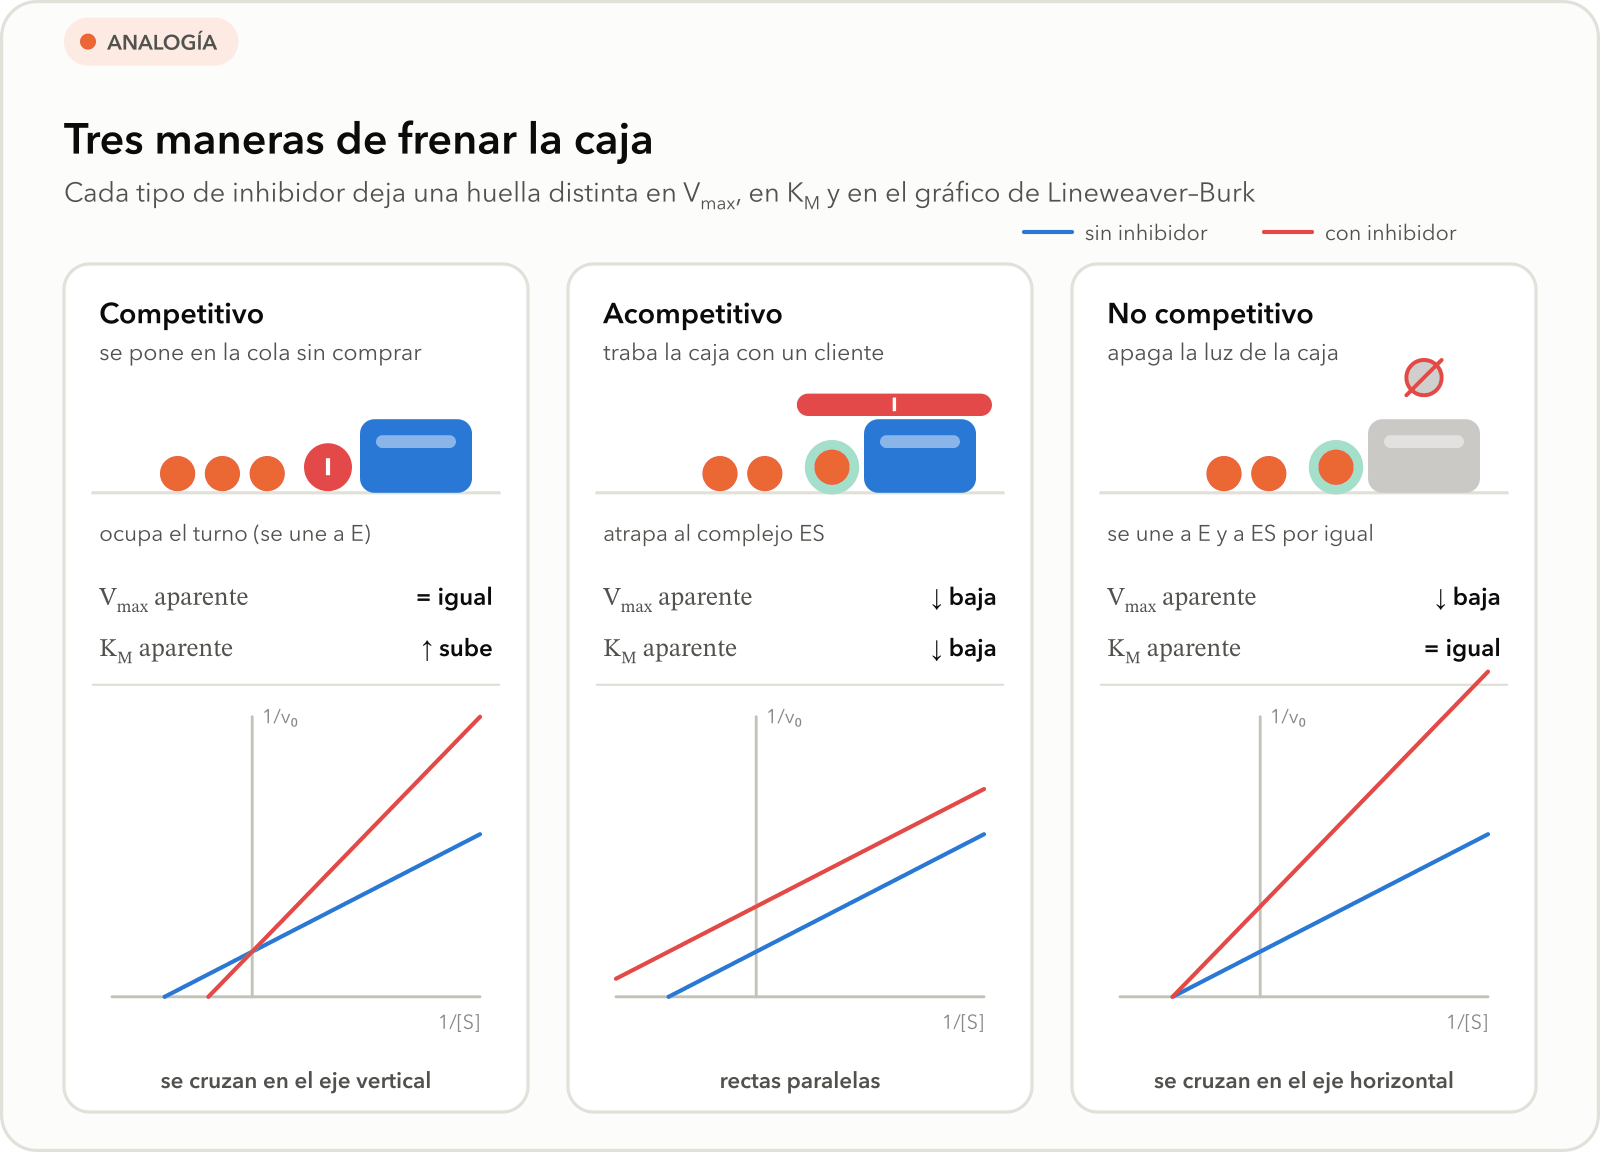

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para saber *cuánto* frena un inhibidor a una concentración
dada, y para medir su potencia con un solo número, K<sub>i</sub>, que no depende del experimento.

Para el competitivo la idea es: el intruso "roba" una parte de las cajas, así que hace falta
**más sustrato** para conseguir la misma ocupación. ¿Cuánto más? Un factor que crece con la
cantidad de intruso:

$$K_M^{\text{aparente}} \;=\; K_M \times \underbrace{\left(1 + \frac{\text{inhibidor}}{\text{potencia del inhibidor}}\right)}_{\text{cuántas veces más sustrato necesitas}}$$

Si hay tanto inhibidor como su K<sub>i</sub>, necesitas el doble de sustrato; si hay 10 veces su
K<sub>i</sub>, 11 veces más.

---

### 📐 La ecuación completa, término a término

**La derivación para el competitivo (las otras son análogas).** El inhibidor I se une a la
enzima libre: $\mathrm{E + I \rightleftharpoons EI}$ con $K_i = [\mathrm{E}][\mathrm{I}]/[\mathrm{EI}]$.
Ahora la enzima total es $[\mathrm{E}]_0 = [\mathrm{E}] + [\mathrm{ES}] + [\mathrm{EI}]$ (*cada caja está
libre, atendiendo a un cliente o bloqueada por el intruso*) y, repitiendo el álgebra de la
sección 13,

$$v_0 = \frac{V_{\max}[\mathrm{S}]}{K_M{\color{#e34948}{\left(1 + \dfrac{[\mathrm{I}]}{K_i}\right)}} + [\mathrm{S}]}
\qquad\Rightarrow\qquad K_M^{\mathrm{ap}} = K_M{\color{#e34948}{\left(1+\frac{[\mathrm{I}]}{K_i}\right)}},\; V_{\max}^{\mathrm{ap}} = V_{\max}.$$

El factor **rojo** (el color del inhibidor en el dibujo) es todo el efecto del intruso.

| Término | Qué es | En la analogía |
|---|---|---|
| [I] | concentración de inhibidor | cuántos intrusos hay en la tienda |
| $K_i$ | constante de disociación del complejo EI | la [I] que bloquea la mitad de las cajas libres: cuanto **menor**, más potente |
| 1 + [I]/K<sub>i</sub> (rojo) | factor de inhibición | cuántas veces más clientes necesitas para la misma ocupación |

| Tipo | Se une a | En la analogía | V<sub>max</sub> aparente | K<sub>M</sub> aparente | Huella en Lineweaver–Burk |
|---|---|---|---|---|---|
| competitivo | E | ocupa el turno | igual | × (1 + [I]/K<sub>i</sub>) | rectas que se cruzan en el eje y |
| acompetitivo | ES | traba la caja con cliente | ÷ (1 + [I]/K<sub>i</sub>′) | ÷ (1 + [I]/K<sub>i</sub>′) | rectas paralelas |
| no competitivo | E y ES por igual | apaga la luz | ÷ (1 + [I]/K<sub>i</sub>) | igual | rectas que se cruzan en el eje x |
| mixto | E y ES, distinto | un poco de cada | ÷ (1 + [I]/K<sub>i</sub>′) | × (1+[I]/K<sub>i</sub>)/(1+[I]/K<sub>i</sub>′) | se cruzan a la izquierda del eje y |

---

### 🎛️ Qué pasa si…

| Si… | entonces… | porque… |
|---|---|---|
| **[I] = K<sub>i</sub>** (competitivo) | la K<sub>M</sub> aparente **se duplica** | 1 + 1 = 2 |
| **[I] = 10 K<sub>i</sub>** (competitivo) | la K<sub>M</sub> aparente se multiplica por **11** | 1 + 10 = 11 |
| **añades mucho sustrato** | un competitivo **se vence**; un no competitivo, **nunca** | con cola larga el intruso no consigue turno; la luz apagada frena igual |

Elige el tipo de inhibidor y mueve [I] y K<sub>i</sub>:

In [ ]:
# @title 🎛️ Tipos de inhibidor y su huella
# 🎛️ Elige el tipo de inhibidor y mueve [I] y Ki: mira la curva y su huella en Lineweaver–Burk
interactivo.explorar_inhibicion()

### 🔬 De los datos a K<sub>i</sub>: tres caminos que deben coincidir

1. **Ajuste global**: todos los puntos (varias [S] y varias [I]) contra la ecuación completa
   → V<sub>max</sub>, K<sub>M</sub> y K<sub>i</sub> con sus errores. Es el método recomendado hoy.
2. **Gráfico secundario**: se ajusta cada [I] por separado y se dibuja K<sub>M</sub><sup>ap</sup>
   frente a [I]: es una recta de pendiente K<sub>M</sub>/K<sub>i</sub>.
3. **Gráfico de Dixon**: 1/v₀ frente a [I] para varias [S]; en un competitivo las rectas se
   cruzan en [I] = −K<sub>i</sub>.

**De IC₅₀ a K<sub>i</sub>.** En farmacología se mide a menudo la **IC₅₀**: la concentración que
reduce la actividad a la mitad. En palabras: *cuanto más sustrato compite, más inhibidor hace
falta para frenar a la mitad*, así que la IC₅₀ depende de [S]. La ecuación de **Cheng–Prusoff**
descuenta ese efecto y devuelve K<sub>i</sub> (para un competitivo):

$$K_i = \frac{\mathrm{IC}_{50}}{1 + {\color{#eb6834}{[\mathrm{S}]/K_M}}}$$

El término **naranja** (el color del sustrato) es la "ventaja" que el sustrato le lleva al
inhibidor.

In [ ]:
# @title 🔬 Tres caminos para medir K_i
Ki_real = 3.0                                   # mM (inhibidor competitivo hipotético)
S_exp = np.array([1, 2, 4, 8, 16, 32, 64]); I_exp = (0, 2, 5, 10)
filas = []
for I in I_exp:
    v = cin.competitive_inhibition(S_exp, Vmax_real, Km_real, I, Ki_real) * (1 + 0.03 * rng.standard_normal(S_exp.size))
    filas += [(s, vv, I) for s, vv in zip(S_exp, v)]
df_i = pd.DataFrame(filas, columns=["S", "v", "I"])
# 1) ajuste global
aji = cin.fit_inhibition(df_i.S.values, df_i.v.values, df_i.I.values, kind="competitive")
# 2) gráfico secundario: Km aparente frente a [I]
km_ap = np.array([cin.fit_michaelis_menten(df_i[df_i.I == I].S.values, df_i[df_i.I == I].v.values)["km"] for I in I_exp])
sec = cin.secondary_plot_competitive(np.array(I_exp), km_ap, aji["km"])
# 3) Dixon
dx = cin.dixon_plot(df_i.S.values, df_i.v.values, df_i.I.values)
kd = cin.ki_from_dixon(sorted(dx["lines"]), dx, aji["km"], aji["vmax"])
# 4) IC50 -> Ki (Cheng–Prusoff)
S_ensayo = 8.0
ic50 = Ki_real * (1 + S_ensayo / Km_real)

fig, axes = viz.figure(14, 5.6, ncols=2)
colores = viz.sequential_blue(len(dx["lines"]))
for (s_val, (ii, inv_v)), color in zip(sorted(dx["lines"].items()), colores):
    fit = dx["fits"][s_val]
    xx = np.linspace(-1.3 * Ki_real, max(I_exp), 50)
    axes[0].plot(xx, fit["intercept"] + fit["slope"] * xx, color=color, lw=1.4, ls=(0, (4, 3)), zorder=2)
    xs = np.linspace(0, max(I_exp), 20)
    axes[0].plot(xs, fit["intercept"] + fit["slope"] * xs, color=color, lw=2.6, zorder=3)
    viz._markers(axes[0], ii, inv_v, color, label=f"[S] = {s_val:g} mM", size=8)
f_lo = dx["fits"][sorted(dx["lines"])[0]]
axes[0].axvline(0, color=viz.AXIS, lw=0.9, zorder=1); axes[0].axhline(0, color=viz.AXIS, lw=0.9, zorder=1)
viz._keypoint(axes[0], -kd["ki"], f_lo["intercept"] - f_lo["slope"] * kd["ki"], viz.COLORS["ts"], size=10)
axes[0].annotate(f"se cruzan en [I] = −Kᵢ\nKᵢ ≈ {kd['ki']:.2f} mM", (-kd["ki"], f_lo["intercept"] - f_lo["slope"] * kd["ki"]),
                 xytext=(4, -24), textcoords="offset points", ha="left", va="top", fontsize=11, color=viz.INK, fontweight="semibold")
viz._finish(axes[0], "[I] (mM)", "1/v₀ (s/µM)")
axes[0].set_ylim(bottom=-0.18 * axes[0].get_ylim()[1])
viz._legend(axes[0], loc="upper left", fontsize=10)
axes[0].set_title("Gráfico de Dixon", loc="left", fontsize=13, fontweight="semibold", pad=10)
xx = np.linspace(0, max(I_exp), 20)
axes[1].fill_between(xx, aji["km"], aji["km"] * (1 + xx / aji["ki"]), color=viz._tint(viz.PALETTE[7], 0.9), lw=0, zorder=1)
axes[1].plot(xx, aji["km"] * (1 + xx / aji["ki"]), color=viz.INK_SECONDARY, lw=2.4, zorder=2)
viz._markers(axes[1], I_exp, km_ap, viz.COLORS["datos"], size=9)
viz._guide(axes[1], "h", aji["km"])
axes[1].annotate("K_M sin inhibidor", (max(I_exp), aji["km"]), xytext=(-4, -6), textcoords="offset points", ha="right", va="top",
                 fontsize=10.5, color=viz.INK_SECONDARY)
axes[1].annotate(f"pendiente = K_M/Kᵢ\n→ Kᵢ = {sec['ki']:.2f} mM", (0.55 * max(I_exp), aji["km"] * (1 + 0.55 * max(I_exp) / aji["ki"])),
                 xytext=(-14, 10), textcoords="offset points", ha="right", va="bottom", fontsize=11, color=viz.INK, fontweight="semibold")
axes[1].set_ylim(0, None)
viz._finish(axes[1], "[I] (mM)", "K_M aparente (mM)")
axes[1].set_title("Gráfico secundario", loc="left", fontsize=13, fontweight="semibold", pad=10)
viz._fig_title(fig, f"Tres caminos, un mismo Kᵢ ≈ {aji['ki']:.1f} mM (valor usado para simular: {Ki_real:g} mM)",
               "Izquierda: 1/v₀ frente a [I] para varias [S]. Derecha: K_M aparente frente a [I]. Ambos con los mismos datos.")
tabla_dixon = df_i.rename(columns={"S": "[S]", "I": "[I]", "v": "v₀"})[["[I]", "[S]", "v₀"]].copy()
tabla_dixon["1/v₀"] = 1 / tabla_dixon["v₀"]
tabla_dixon["v₀ sin inhibidor (misma [S])"] = [df_i[(df_i.I == 0) & (df_i.S == sv)].v.iloc[0] for sv in tabla_dixon["[S]"]]
tabla_dixon["actividad restante"] = tabla_dixon["v₀"] / tabla_dixon["v₀ sin inhibidor (misma [S])"]
datos_dixon = viz.datos(
    tabla_dixon, "el gráfico de Dixon",
    "Los 28 tubos del experimento: 4 concentraciones de inhibidor × 7 de glucosa (3 % de ruido). En el gráfico de "
    "Dixon cada [S] es una recta: sus puntos son las filas con esa [S], con [I] en el eje x y 1/v₀ en el eje y. "
    "Con mucha glucosa el inhibidor competitivo casi no se nota (actividad restante cerca del 100 %).",
    x="[I]", y="1/v₀",
    calculadas={"1/v₀": "1 ÷ v₀", "actividad restante": "v₀ ÷ v₀ sin inhibidor, con la misma [S]"},
    unidades={"[I]": "mM", "[S]": "mM", "v₀": "µM/s", "1/v₀": "s/µM", "v₀ sin inhibidor (misma [S])": "µM/s"},
    formatos={"[I]": "{:g}", "[S]": "{:g}", "v₀": "{:.2f}", "1/v₀": "{:.3f}", "v₀ sin inhibidor (misma [S])": "{:.2f}",
              "actividad restante": "{:.0%}"},
    resaltar={i: ("[I] = 10 mM", "rojo") for i in tabla_dixon.index[(tabla_dixon["[I]"] == max(I_exp)) & (tabla_dixon["[S]"] <= 2)]},
    barra="1/v₀", max_filas=40, abierta=False)
tabla_sec = pd.DataFrame({"[I]": np.array(I_exp, dtype=float), "K_M aparente": km_ap, "K_M ap / K_M": km_ap / aji["km"],
                          "1 + [I]/Kᵢ (teoría)": 1 + np.array(I_exp) / aji["ki"]})
datos_sec = viz.datos(
    tabla_sec, "el gráfico secundario",
    "Una fila por concentración de inhibidor: a cada grupo de 7 tubos se le ajusta su propia hipérbola, y su K_M "
    "aparente es un punto del gráfico secundario. Si el inhibidor es competitivo, K_M ap/K_M crece como 1 + [I]/Kᵢ.",
    x="[I]", y="K_M aparente",
    calculadas={"K_M aparente": "ajuste de Michaelis–Menten solo a los tubos con esa [I]",
                "K_M ap / K_M": "K_M aparente ÷ K_M sin inhibidor (del ajuste global)",
                "1 + [I]/Kᵢ (teoría)": "lo que predice la ecuación competitiva con el Kᵢ del ajuste global"},
    unidades={"[I]": "mM", "K_M aparente": "mM"},
    formatos={"[I]": "{:g}", "K_M aparente": "{:.2f}", "K_M ap / K_M": "{:.2f}", "1 + [I]/Kᵢ (teoría)": "{:.2f}"},
    barra="K_M aparente")
viz.mostrar(fig, datos_dixon, datos_sec, viz.tarjetas([
    ("1 · ajuste global", f"{aji['ki']:.2f}", f"± {aji['ki_err']:.2f} mM", f"K_M = {aji['km']:.2f} mM, V_max = {aji['vmax']:.2f} µM/s", "azul"),
    ("2 · gráfico secundario", f"{sec['ki']:.2f}", "mM", f"R² = {sec['r2']:.3f}", "agua"),
    ("3 · Dixon", f"{kd['ki']:.2f}", "mM", "por el cruce de las rectas", "naranja"),
    ("4 · Cheng–Prusoff", f"{cin.cheng_prusoff(ic50, S_ensayo, Km_real):.2f}", "mM", f"desde IC₅₀ = {ic50:.1f} mM con [S] = {S_ensayo:g} mM", "violeta"),
], titulo="Kᵢ del mismo inhibidor, medido de cuatro maneras",
   nota="Si los métodos coinciden, el modelo (competitivo) describe bien los datos."))

### 🔬 Los inhibidores y reguladores reales de la glucoquinasa

Tabla con fuentes. Tres cosas que sorprenden:

* La glucosa‑6‑fosfato, que frena a las hexoquinasas I–III, **no** inhibe a la glucoquinasa: por
  eso el hígado sigue fosforilando glucosa aunque el producto se acumule (Viñuela, Salas y Sols, 1963).
* La **manoheptulosa**, que muchos libros llaman "competitiva", resulta de tipo **mixto** cuando se
  mide con cuidado (Scruel 1998), y su K<sub>i</sub> varía 100 veces entre fuentes secundarias: por
  eso no damos un número.
* En el hígado, la **proteína reguladora GKRP** actúa como inhibidor competitivo frente a la glucosa
  (sube S<sub>0.5</sub> sin cambiar V; IC₅₀ ≈ 13 mM de glucosa) y secuestra a la enzima en el núcleo
  cuando la glucosa baja; la fructosa‑6‑fosfato refuerza ese secuestro y la fructosa‑1‑fosfato lo
  deshace.

In [ ]:
# @title 📋 Inhibidores y activadores reales de la glucoquinasa
inh = ref.get("inhibitors", [])
tipos = {"competitive": "competitivo", "mixed": "mixto", "none": "ninguno", "slow-binding": "unión lenta",
         "uncompetitive": "acompetitivo", "noncompetitive": "no competitivo"}
act = ref.get("activators", [])
viz.mostrar(
    viz.tabla(pd.DataFrame([(d.get("name"), tipos.get(d.get("kind"), d.get("kind")), d.get("versus", ""), d.get("ki", ""), d.get("note", ""), d.get("source", "")) for d in inh],
                           columns=["inhibidor / regulador", "tipo", "frente a", "Kᵢ / efecto", "nota", "fuente"]),
              titulo="Inhibidores y reguladores de la glucoquinasa"),
    viz.tabla(pd.DataFrame([(d.get("name"), d.get("fold", ""), d.get("ec50", ""), d.get("note", ""), d.get("source", "")) for d in act],
                           columns=["activador", "activación (veces)", "EC₅₀", "nota", "fuente"]),
              titulo="Activadores alostéricos (GKA)"),
)

### 🔬 Activadores alostéricos (GKA)

En la analogía: alguien **aceita la caja** y abre el turno antes. Se unen a un sitio a ~20 Å del
sitio de glucosa (Kamata 2004), bajan S<sub>0.5</sub> y suben V<sub>max</sub>: lo contrario de un
inhibidor. El compuesto de referencia RO‑28‑1675 activa a la enzima silvestre ~16 veces con
EC₅₀ ≈ 7 µM (Sayed 2009) y se ensayó como fármaco para la diabetes tipo 2 (Grimsby 2003). ¿Qué
pasa con la actividad a 5 mM de glucosa cuando bajas S<sub>0.5</sub>? Muévelo:

In [ ]:
# @title 🎛️ Un activador alostérico
# 🎛️ Un activador alostérico: baja S0.5 y sube Vmax. ¿Qué pasa con la actividad a 5 mM de glucosa?
interactivo.explorar_activador()

> ✅ **Para llevar.** Cada tipo de inhibidor deja una huella distinta: el competitivo sube
> K<sub>M</sub> (y se vence con sustrato), el acompetitivo baja V<sub>max</sub> y K<sub>M</sub>, el
> no competitivo baja solo V<sub>max</sub>. K<sub>i</sub> se mide por ajuste global, gráfico
> secundario o Dixon, y Cheng–Prusoff convierte una IC₅₀ en K<sub>i</sub>. Los activadores hacen lo
> contrario: bajan S<sub>0.5</sub>.

## 16. Temperatura y pH

> 🎯 **En esta sección** verás por qué calentar acelera las reacciones (y cuánto), cómo separar la
> barrera en **entalpía** y **entropía** con las ecuaciones de Arrhenius y Eyring, y por qué la
> actividad de una enzima frente al pH tiene forma de **campana**.

---

### 💡 La analogía: calentar = sacudidas más fuertes

Vuelve a la pelota de la sección 6. La temperatura es la fuerza de las sacudidas: al calentar,
todas las moléculas se mueven más y **crece la fracción** que tiene energía suficiente para
cruzar la colina. Como esa fracción es la "cola" de una distribución, un cambio pequeño de
temperatura la agranda mucho más de lo que uno esperaría.

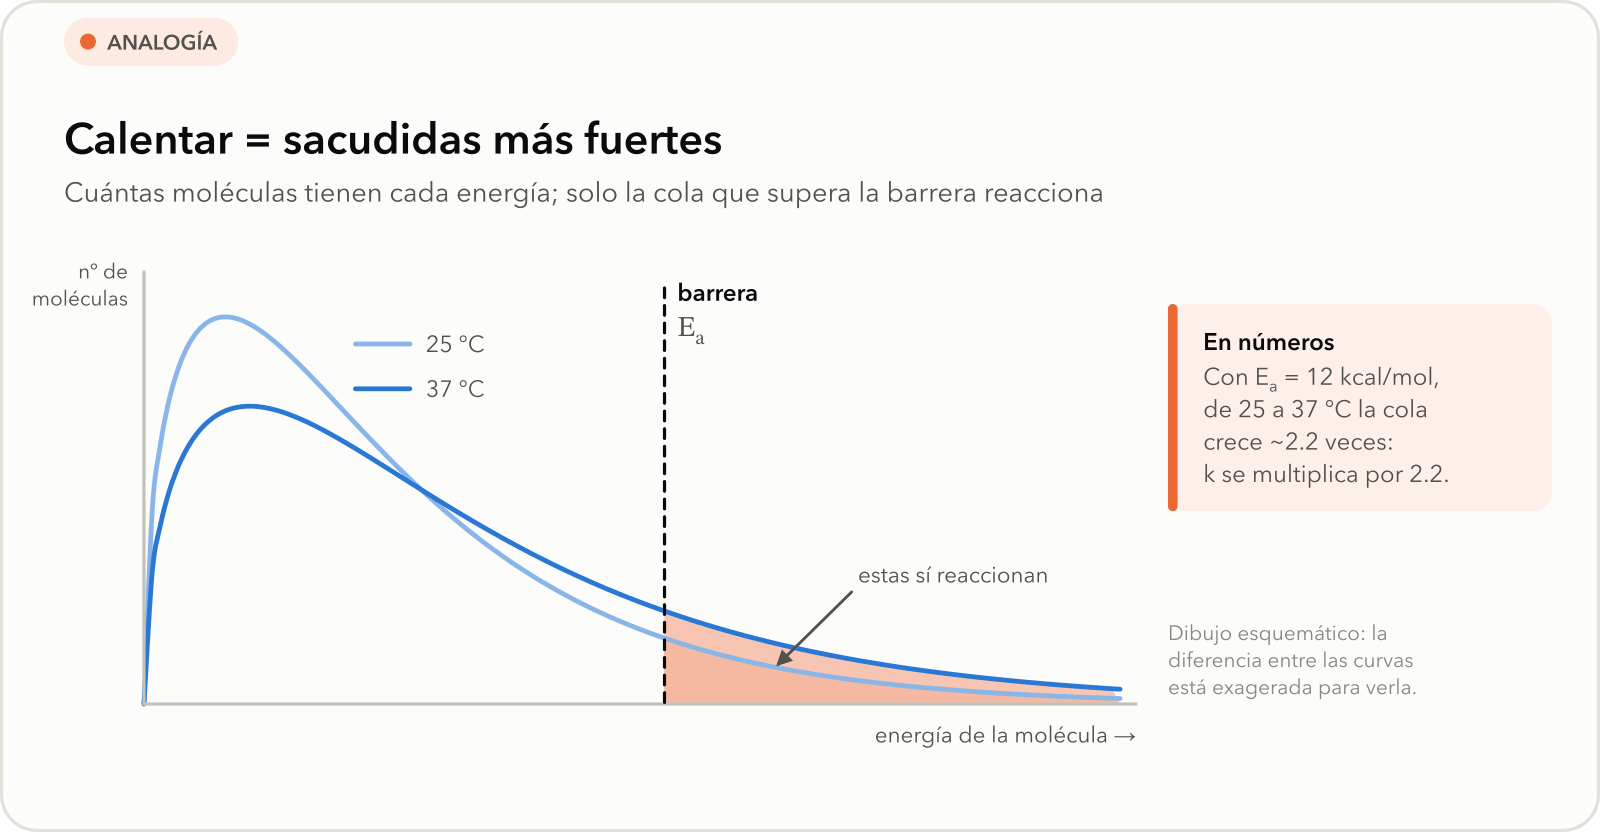

(Hasta que la enzima se desnaturaliza: calentar demasiado desarma la proteína.)

---

### 🧮 La ecuación en palabras

**¿Para qué queremos una ecuación?** Para leer la **altura de la barrera** en un experimento
sencillo: medir k a varias temperaturas. Cuánto sube la velocidad al calentar dice cuán alta es
la colina.

$$\text{ln(velocidad)} \;=\; \text{constante} \;-\; \frac{\text{altura de la barrera}}{\text{energía de las sacudidas}}$$

Si dibujas ln k frente a 1/T sale una **recta**, y su pendiente es la barrera: cuanto más empinada,
más alta la colina y más sensible la reacción a la temperatura.

---

### 📐 Las ecuaciones completas, término a término

**Arrhenius**: $\ln k = \ln A - {\color{#eb6834}{E_a}}/RT$. En un gráfico de ln k frente a 1/T la
pendiente es $-{\color{#eb6834}{E_a}}/R$: la **energía de activación** es "cuánto sube la velocidad
al calentar".

**Eyring**: $\ln(k/T) = \ln(k_B/h) + {\color{#4a3aa7}{\Delta S^{\ddagger}}}/R - {\color{#eb6834}{\Delta H^{\ddagger}}}/RT$.
Separa la barrera en **entalpía** (energía que hay que aportar) y **entropía** (orden que hay que
imponer: un ΔS‡ negativo significa que el estado de transición es más ordenado que los reactivos).

| Término | Qué es | En la analogía |
|---|---|---|
| ${\color{#eb6834}{E_a,\ \Delta H^{\ddagger}}}$ | energía de activación / entalpía de activación | la altura de la colina |
| ${\color{#4a3aa7}{\Delta S^{\ddagger}}}$ | entropía de activación | lo estrecho del paso: si hay que "enhebrar" la cima con precisión, ΔS‡ < 0 |
| $A$ | factor preexponencial | los intentos por segundo |
| $RT$ | energía térmica | la fuerza típica de las sacudidas |

---

### 🎛️ Qué pasa si…

| Si… | al subir de 25 a 37 °C, k se multiplica por… | porque… |
|---|---|---|
| E<sub>a</sub> = 12 kcal/mol | **~2.2** | la cola sobre una colina alta crece mucho con las sacudidas |
| E<sub>a</sub> = 6 kcal/mol | **~1.5** | sobre una colina baja ya pasan muchas: calentar añade menos |

Cuanto mayor la barrera, más sensible a la temperatura.

In [ ]:
# @title 🎛️ Entalpía, entropía y temperatura
# 🎛️ Entalpía y entropía de activación: mira el gráfico de Eyring y k(T)
interactivo.explorar_temperatura()

In [ ]:
# @title 🌡️ Arrhenius y Eyring con datos
T_K = np.array([283.15, 288.15, 293.15, 298.15, 303.15, 308.15, 313.15])
dH, dS = 12.0, -8.0                       # kcal/mol, cal/mol/K (ilustrativos)
k_T = np.array([cin.eyring_rate(dH - T * dS / 1000, T) for T in T_K]) * (1 + 0.03 * rng.standard_normal(T_K.size))
aj_arr, aj_eyr = cin.fit_arrhenius(T_K, k_T), cin.fit_eyring(T_K, k_T)
fig, axes = viz.figure(14, 5.8, ncols=2)
viz.plot_arrhenius(T_K, k_T, fit=aj_arr, ax=axes[0], title="Arrhenius: ln k frente a 1000/T")
viz.plot_eyring(T_K, k_T, fit=aj_eyr, ax=axes[1], title="Eyring: ln(k/T) frente a 1000/T")
viz._fig_title(fig, "Más calor, más velocidad: la pendiente mide cuánto",
               "Siete temperaturas de 10 a 40 °C (eje superior). Una recta empinada = una reacción muy sensible a la temperatura.")
tabla_T = pd.DataFrame({"T": T_K, "T (°C)": T_K - 273.15, "k medida": k_T, "1000/T": 1000 / T_K,
                        "ln k": np.log(k_T), "ln(k/T)": np.log(k_T / T_K)})
datos_T = viz.datos(
    tabla_T, "Arrhenius y Eyring",
    "Siete medidas de la constante de velocidad, una por temperatura (3 % de ruido). Las dos rectas usan el mismo "
    "eje x, 1000/T; Arrhenius pone ln k en el eje y y Eyring, ln(k/T). Su pendiente da E_a y ΔH‡.",
    x="1000/T", y=["ln k", "ln(k/T)"],
    calculadas={"T (°C)": "T − 273.15", "1000/T": "1000 ÷ T (en K⁻¹ × 1000, para que los números sean cómodos)",
                "ln k": "logaritmo natural de k  (eje y de Arrhenius; pendiente = −E_a/R)",
                "ln(k/T)": "logaritmo natural de k ÷ T  (eje y de Eyring; pendiente = −ΔH‡/R)"},
    unidades={"T": "K", "T (°C)": "°C", "k medida": "s⁻¹", "1000/T": "K⁻¹"},
    formatos={"T": "{:.2f}", "T (°C)": "{:.0f}", "k medida": "{:.1f}", "1000/T": "{:.4f}", "ln k": "{:.3f}", "ln(k/T)": "{:.3f}"},
    resaltar={int(np.argmin(np.abs(T_K - 298.15))): ("25 °C", "azul")},
    barra="k medida")
viz.mostrar(fig, datos_T, viz.tarjetas([
    ("E_a (Arrhenius)", f"{aj_arr['ea_kcal']:.1f}", "kcal/mol", "cuánto sube k al calentar", "naranja"),
    ("ΔH‡ (Eyring)", f"{aj_eyr['delta_h_kcal']:.1f}", "kcal/mol", "energía que hay que aportar", "naranja"),
    ("ΔS‡ (Eyring)", f"{aj_eyr['delta_s_cal']:.1f}", "cal/mol/K", "negativa: el TS es más ordenado", "violeta"),
    ("ΔG‡ (25 °C)", f"{aj_eyr['delta_g_kcal']:.1f}", "kcal/mol", "ΔH‡ − TΔS‡", "azul"),
], titulo="Lo que dicen las dos rectas", nota="Relación entre ambas: E_a ≈ ΔH‡ + RT (0.6 kcal/mol a 25 °C)."))

---

### 💡 La analogía del pH: dos grupos, dos condiciones

Cada enzima tiene un pH óptimo: por encima o por debajo, los grupos que hacen la química pierden
la carga que necesitan. En la glucoquinasa, **Asp205** (la base catalítica) debe estar
**desprotonado** para poder aceptar el protón de la glucosa, y **Lys169** debe estar **protonada**
para estabilizar el fosfato. Es como una puerta con dos cerraduras: solo se abre cuando las dos
están en la posición correcta.

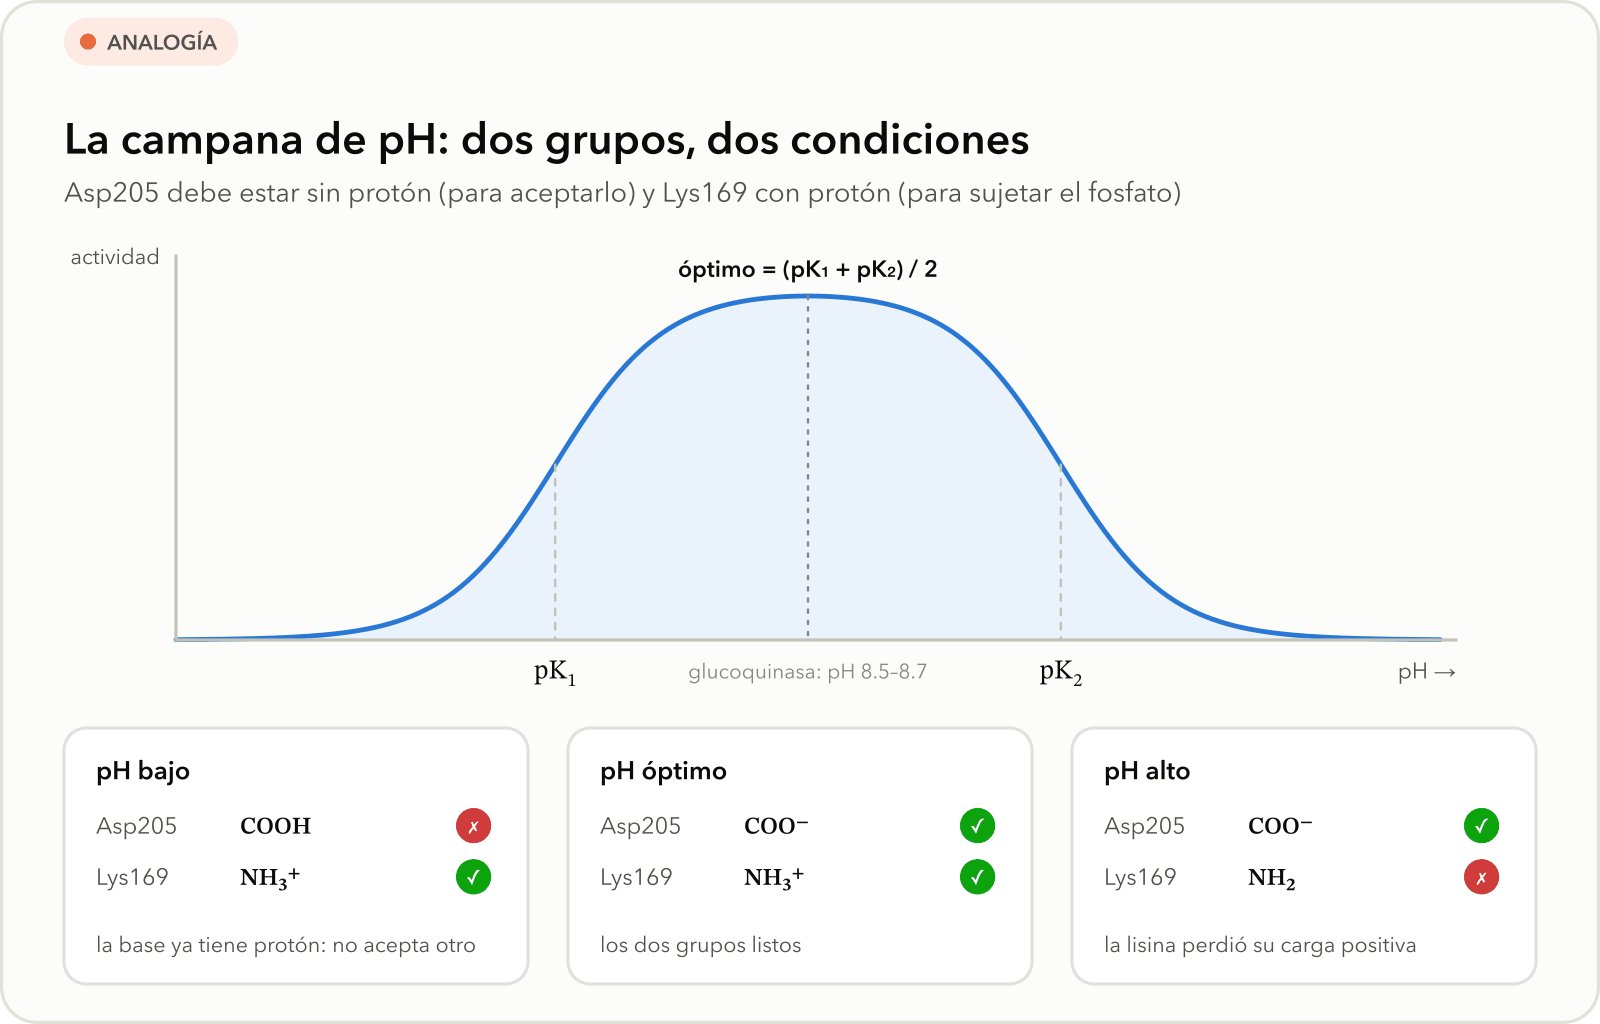

### 🧮 La ecuación en palabras

$$\text{actividad} \;=\; \frac{\text{actividad máxima}}{1 + (\text{penalización si falta la base}) + (\text{penalización si falta el ácido})}$$

Cada penalización es casi cero en el pH correcto y crece 10 veces por cada unidad de pH que te
alejas: de ahí la campana.

### 📐 La ecuación completa, término a término

$$v = \frac{v_{\max}}{1 + {\color{#eb6834}{10^{\,pK_1 - \mathrm{pH}}}} + {\color{#4a3aa7}{10^{\,\mathrm{pH} - pK_2}}}}$$

| Término | Qué es | Cuándo pesa |
|---|---|---|
| ${\color{#eb6834}{10^{\,pK_1 - \mathrm{pH}}}}$ | cociente Asp205 **protonado** (inútil como base) / desprotonado | a pH bajo: "apaga" la enzima |
| ${\color{#4a3aa7}{10^{\,\mathrm{pH} - pK_2}}}$ | cociente Lys169 **desprotonada** (sin carga positiva) / protonada | a pH alto: "apaga" la enzima |
| (pK<sub>1</sub> + pK<sub>2</sub>)/2 | posición del máximo | el pH óptimo |

> 🔬 **Los datos reales.** Para la glucoquinasa humana el óptimo medido es pH 8.5–8.7 (Šimčíková y
> Heneberg 2019); durante décadas se creyó más bajo porque el ATP acidifica los tampones del ensayo:
> un ejemplo de cómo un detalle técnico cambia un "hecho" de libro de texto.

In [ ]:
# @title 🎛️ La campana de pH
# 🎛️ pKa de la base y del ácido: la campana de pH
interactivo.explorar_ph()

> ✅ **Para llevar.** Calentar agranda la cola de moléculas que superan la barrera: cuanto más alta
> la colina, más gana la reacción con la temperatura (Arrhenius mide E<sub>a</sub>; Eyring la separa
> en ΔH‡ y ΔS‡). El pH decide si los grupos catalíticos tienen la carga correcta: dos pK<sub>a</sub>
> dibujan una campana con el máximo entre ellos.

## 17. Resumen, glosario y ejercicios

> 🎯 **En esta sección** juntamos todas las piezas: el mapa del curso, las ecuaciones en una sola
> página, un glosario y ejercicios para comprobar lo aprendido.

---

### 🗺️ El mapa del curso

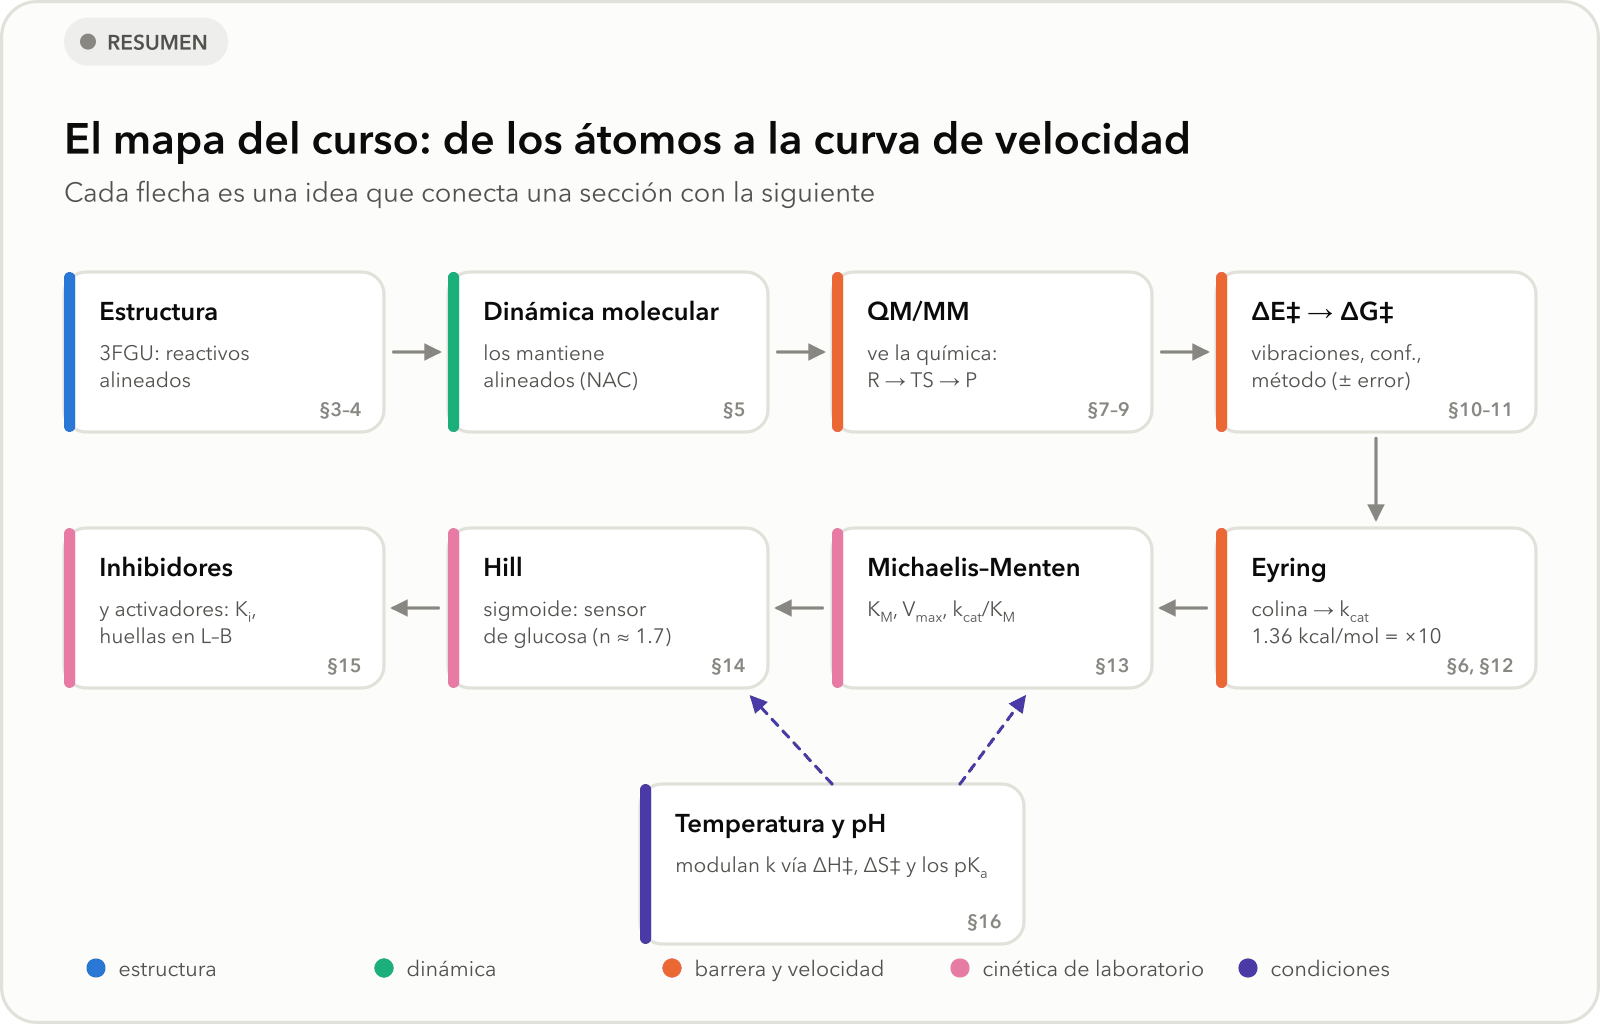

**Lo que hemos visto, en una frase cada cosa:**

1. Una enzima acelera una reacción **bajando la barrera** del estado de transición, como un guía
   que conoce el paso más bajo.
2. La estructura cristalina (3FGU) muestra a los reactivos ya alineados; la MD muestra que la
   enzima **los mantiene alineados**.
3. QM/MM permite **ver la química** dentro de la enzima; hay que cuidar la partición, los átomos
   de enlace, la electrostática y la repulsión QM–MM.
4. El estado de transición es un **punto de silla**: se localiza (escaneo → NEB → dímero) y se
   **valida** con una única frecuencia imaginaria y con el camino que baja hacia R y P.
5. De ΔE‡ a ΔG‡: vibraciones, promedio sobre conformaciones y sensibilidad al método. Un
   resultado computacional lleva **incertidumbre**, y nuestra barrera coincide con otro cálculo
   publicado y sobrestima el experimento en ~3–4 kcal/mol.
6. Eyring convierte la barrera en *k*<sub>cat</sub>; 1.4 kcal/mol son un factor 10.
7. Michaelis–Menten **emerge** del mecanismo E + S ⇌ ES → E + P; K<sub>M</sub>, V<sub>max</sub>,
   k<sub>cat</sub> y k<sub>cat</sub>/K<sub>M</sub> se derivan de los datos por ajuste no lineal.
8. La glucoquinasa es **sigmoide** (n ≈ 1.7) sin tener varias subunidades: cooperatividad
   cinética; sus mutantes desplazan el interruptor de la insulina.
9. Cada tipo de inhibidor deja una huella distinta; K<sub>i</sub> se obtiene por ajuste global,
   gráfico secundario o Dixon; los activadores hacen lo contrario.
10. Temperatura y pH modulan k a través de ΔH‡, ΔS‡ y los pK<sub>a</sub> del sitio activo.

---

### 🧮 Las ecuaciones del curso, en una página

**Velocidad inicial** (sección 2): la velocidad es la pendiente inicial de la curva de producto.

$$v_0 = \left(\frac{\Delta[\mathrm{P}]}{\Delta t}\right)_{t\to 0}$$

**Eyring** (secciones 6 y 12): velocidad = intentos por segundo × probabilidad de llegar a la cima.

$$k = \kappa\,\frac{k_B T}{h}\,\exp\!\left(-\frac{\Delta G^{\ddagger}}{RT}\right)$$

**Michaelis–Menten** (sección 13): la caja se satura; con mucho sustrato la enzima trabaja a tope.

$$v_0 = \frac{V_{\max}[\mathrm{S}]}{K_M + [\mathrm{S}]}$$

**Hill** (sección 14): un interruptor; poca actividad hasta un umbral, luego mucha.

$$v_0 = \frac{V_{\max}[\mathrm{S}]^{n}}{S_{0.5}^{\,n} + [\mathrm{S}]^{n}}$$

**Inhibición competitiva** (sección 15): el intruso exige más sustrato para la misma velocidad.

$$K_M^{\mathrm{ap}} = K_M\left(1 + \frac{[\mathrm{I}]}{K_i}\right)$$

**Arrhenius** (sección 16): calentar acelera más cuanto más alta es la barrera.

$$\ln k = \ln A - \frac{E_a}{RT}$$

**pH** (sección 16): la enzima solo funciona si cada grupo del sitio activo tiene la carga correcta.

$$v = \frac{v_{\max}}{1 + 10^{pK_1 - \mathrm{pH}} + 10^{\mathrm{pH} - pK_2}}$$

---

### 📖 Glosario rápido

| Término | Significado |
|---|---|
| *Sustrato* | molécula transformada |
| *Sitio activo* | donde ocurre la química |
| *ES* | complejo enzima‑sustrato |
| *Estado de transición* | cima de la barrera |
| *ΔG‡* | altura de la barrera |
| *k*<sub>cat</sub> | reacciones por segundo por enzima |
| *K*<sub>M</sub> | [S] a media velocidad |
| *k*<sub>cat</sub>/*K*<sub>M</sub> | eficiencia a baja [S] |
| *S*<sub>0.5</sub>, *n* | parámetros de Hill |
| *K*<sub>i</sub> | constante de disociación del inhibidor |
| *QM/MM* | mecánica cuántica para la región reactiva y campo de fuerza para el resto |
| *NEB, dímero* | métodos para hallar el TS |
| *Frecuencia imaginaria* | la firma de un punto de silla |

---

### ✍️ Ejercicios

**Para empezar**

1. Mueve el deslizador `umbral` de la sección 5 a 3.0 y a 4.0 Å y vuelve a ejecutar la celda. ¿Cómo cambia la fracción de conformaciones de
   ataque cercano? ¿Qué pasaría con *k*<sub>cat</sub> si la enzima no cerrara sus dominios?
2. Con el explorador de Eyring, averigua cuánto tendría que bajar la barrera para multiplicar
   *k*<sub>cat</sub> por 1000. Compáralo con la diferencia entre el sitio activo en agua y en la enzima.
3. En la sección 13, mueve el deslizador `k2` a 6 s⁻¹ y a 600 s⁻¹ y vuelve a ejecutar la celda. ¿Cómo cambian K<sub>M</sub> y V<sub>max</sub>?
   ¿Cuándo K<sub>M</sub> ≈ K<sub>d</sub> = k<sub>−1</sub>/k<sub>1</sub>?

**Para profundizar**

4. Simula datos con n = 1.0, 1.4 y 2.0 en la sección 14 y ajústalos con Michaelis–Menten.
   ¿Qué error cometes si ignoras la cooperatividad? ¿Qué mutante de la tabla dejaría de liberar
   insulina a 5 mM?
5. Diseña un experimento (concentraciones de S e I) que distinga un inhibidor competitivo de uno
   mixto con K<sub>i</sub>′ = 3K<sub>i</sub>. Para comprobarlo, añade una celda nueva (botón «+ Código») y usa `cin.fit_inhibition` y el gráfico de Dixon.
6. Con la termoquímica de la sección 10, ¿cuánto cambia ΔG‡ entre 25 y 37 °C? ¿Qué factor en
   *k* supone? Compáralo con lo que predice el explorador de temperatura.

**Reto (avanzado, modo `completo`)**

7. En `enzimas/glucoquinasa.py` saca Lys169 de `QM_RESIDUES` (quedará como cargas MM) y
   recalcula el escaneo. ¿Sube o baja la barrera? Es un "mutante computacional"; Zhang et al.
   (2009) obtuvieron 32 kcal/mol para K169A frente a 18 para la silvestre.

---

### 📚 Referencias

In [ ]:
# @title 📚 Referencias
from IPython.display import HTML
import html as _html
refs = ref.get("references", [])
items = "".join(f'<li style="margin:0 0 8px 0;padding-left:4px">{_html.escape(r)}</li>' for r in refs)
viz.mostrar(HTML(
    f'<div style="font-family:Figtree,\'Avenir Next\',\'Segoe UI\',Roboto,Arial,sans-serif;background:{viz.SURFACE};'
    f'border:1px solid {viz.GRID};border-radius:18px;padding:18px 22px;max-width:960px;color:{viz.INK_SECONDARY};font-size:14px;line-height:1.45">'
    f'<div style="font-size:16px;font-weight:650;color:{viz.INK};margin-bottom:10px">📚 Fuentes de los datos del curso</div>'
    f'<ol style="margin:0;padding-left:22px">{items}</ol>'
    f'<div style="margin-top:12px;font-size:13px;color:{viz.INK_MUTED}">Herramientas QM/MM adaptadas de la suite Leonardo (Juvenal Yosa, MIT): '
    f'<a href="https://github.com/juvenalyosa/Leonardo" style="color:{viz.PALETTE[0]}">github.com/juvenalyosa/Leonardo</a></div></div>'))